# Анализ бизнес-показателей приложения Procrastinate Pro+

<a id=content></a>
## Содержание

<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
1. [<b>Загрузка данных и получение общей информации</b>](#1)
    <br>[1.1. Загрузка данных](#1.1)
    <br>[1.2. Преобразование названий признаков](#1.2)
    <br>[1.3. Преобразование типов данных](#1.3)
    <br>[1.4. Выявление пропущенных значений](#1.4)
    <br>[1.5. Выявление дубликатов](#1.5)
2. [<b>Создание функций для расчёта и анализа LTV, ROI, удержания и конверсии](#2)
    <br>[2.1. Создание функции для создания профилей пользователей](#2.1.)
    <br>[2.2. Создание функции для расчёта Retention Rate](#2.2.)
    <br>[2.3. Создание функции для расчёта конверсии](#2.3.)
    <br>[2.4. Создание функции для расчёта LTV и ROI](#2.4.)
    <br>[2.5. Создание функции для сглаживания графиков](#2.5.)
    <br>[2.6. Создание функции для построения графика Retention Rate](#2.6.)
    <br>[2.7. Создание функции для построения графика конверсии](#2.7.)
    <br>[2.8. Создание функции для визуализации LTV и ROI](#2.8.)
3. [<b>Исследовательский анализ данных](#3)
    <br>[3.1. Создание профилей пользователей. Хронологические рамки](#3.1.)
    <br>[3.2. Географические рамки](#3.2.)
    <br>[3.3. Устройства пользователей](#3.3.)
    <br>[3.4. Источники привлечения пользователей](#3.4.)
4. [<b>Маркетинг](#4)
    <br>[4.1. Расчёт общей суммы расходов на маркетинг](#4.1.)
    <br>[4.2. Распределение трат по рекламным источникам](#4.2.)
    <br>[4.3. Динамика изменения расходов во времени (по неделям и месяцам) по каждому источнику](#4.3.)
    <br>[4.4. Средняя стоимость привлечения одного пользователя из каждого источника](#4.4.)
5. [<b>Оценка окупаемости рекламы](#5)
    <br>[5.1. Окупаемость рекламы по графикам LTV и ROI, а также по графикам динамики LTV, CAC и ROI](#5.1.)
    <br>[5.2. Конверсия пользователей и динамика её изменения. Удержание пользователей и динамика его изменения](#5.2.)
    <br>[5.3. Окупаемость рекламы в разрезе устройств. Графики LTV и ROI, графики динамики LTV, CAC и ROI](#5.3.)
    <br>[5.4. Окупаемость рекламы в разрезе стран. Графики LTV и ROI, графики динамики LTV, CAC и ROI](#5.4.)
    <br>[5.5. Окупаемость рекламы с разбивкой по рекламным каналам. Графики LTV и ROI, графики динамики LTV, CAC и ROI](#5.5.)
    <br>[5.6. Анализ окупаемости рекламы](#5.6.)
        <br>[5.6.1. Окупается ли реклама, направленная на привлечение пользователей в целом?](#5.6.1.)
        <br>[5.6.2. Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы?](#5.6.2.)
        <br>[5.6.3. Чем могут быть вызваны проблемы окупаемости?](#5.6.3.)
        <br>[5.6.4. Промежуточные рекомендации для отдела рекламы](#5.6.4.)
6. [<b>Вывод](#6)

<a id=descr_proj></a>
## Описание проекта

Выступая в роли маркетингового аналитика развлекательного приложения Procrastinate Pro+, предлагается выяснить причины убыточности приложения за последние полгода вопреки огромным вложениям в рекламу, а также оказать помощь в увеличении прибыли.

Предстоит изучить:
* откуда приходят пользователи и какими устройствами они пользуются,
* сколько стоит привлечение пользователей из различных рекламных каналов;
* сколько денег приносит каждый клиент,
* когда расходы на привлечение клиента окупаются,
* какие факторы мешают привлечению клиентов.

<a id=descr_data></a>
## Описание данных

В работу поступили 3 датафрейма, содержащие следующую информацию за период с 1 мая по 27 октября 2019 года включительно: `visits_info_short.csv` лог сервера с информацией о посещениях сайта; `orders_info_short.csv` выгрузка информации о заказах; 
`costs_info_short.csv` информация о расходах на рекламу.

*Таблица 1. Структура исходных данных*

<br>**Наименование датафрейма:** `visits_info_short.csv`
<br>**Размер датафрейма:** 309 901 строка × 6 столбцов

|№ п/п|Наименование признака|Описание признака|Единицы измерения|Размах значений|
|-----|:--------------------|:----------------|:----------------|:--------------|
|1.|`User Id`|уникальный идентификатор пользователя|150 008 уникальных значений идентификатора пользователя|от 599326 до 999999563947|
|2.|`Region`|страна пользователя|4 уникальных наименования страны|United States, UK, France, Germany|
|3.|`Device`|тип устройства пользователя|4 уникальных типа устройств|iPhone, Mac, Android, PC|
|4.|`Channel`|идентификатор источника перехода|11 уникальных каналов|organic, TipTop, RocketSuperAds, YRabbit, FaceBoom, MediaTornado, AdNonSense, LeapBob, WahooNetBanner, OppleCreativeMedia, lambdaMediaAds|
|5.|`Session Start`|дата и время начала сессии|дата и время|от 2019-05-01 00:00:41 до 2019-10-31 23:59:23|
|6.|`Session End`|дата и время завершения сессии|дата и время|от 2019-05-01 00:07:06 до 2019-11-01 01:38:46|

<br>**Наименование датафрейма:** `orders_info_short.csv`
<br>**Размер датафрейма:** 40 212 строк × 3 столбца

|№ п/п|Наименование признака|Описание признака|Единицы измерения|Размах значений|
|-----|:--------------------|:----------------|:----------------|:--------------|
|1.|`User Id`|уникальный идентификатор пользователя|8 881 уникальных значения идентификатора пользователя|от 599326 до 999895427370|
|2.|`Event Dt`|дата и время покупки|дата и время|от 2019-05-01 00:28:11 до 2019-10-31 23:56:56|
|3.|`Revenue`|сумма заказа|денежная единица|от 4.99 до 49.99|

<br>**Наименование датафрейма:** `costs_info_short.csv`
<br>**Размер датафрейма:** 1 800 строк × 3 столбца

|№ п/п|Наименование признака|Описание признака|Единицы измерения|Размах значений|
|-----|:--------------------|:----------------|:----------------|:--------------|
|1.|`dt`|дата проведения рекламной кампании|180 уникальных дат|от 2019-05-01 до 2019-10-27|
|2.|`Channel`|идентификатор рекламного источника|10 уникальных каналов|FaceBoom, MediaTornado, RocketSuperAds, TipTop, YRabbit, AdNonSense, LeapBob, OppleCreativeMedia, WahooNetBanner, lambdaMediaAds|
|3.|`costs`|расходы на эту кампанию|денежная единица|от 0.8 до 630.0|

Данные получены посредством последовательного применения методов `len()`, `unique()`, `min()`, `max()` к вышеперечисленным датафреймам.

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

<a id=1.1.></a>
### 1.1. Загрузка данных

In [1]:
# импорт библиотек
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# игнорирование системных предупреждений об обновлениях работы функций
import warnings
warnings.simplefilter('ignore')

# настройка вывода визуализации
%matplotlib inline

In [2]:
# загрузка файлов в датафреймы
try:
    visits = pd.read_csv('visits_info_short.csv', sep=',') # посещения
    orders = pd.read_csv('orders_info_short.csv', sep=',') # заказы
    costs = pd.read_csv('costs_info_short.csv', sep=',')   # расходы на рекламу
    
except:
    visits = pd.read_csv('https://code.s3.yandex.net/datasets/visits_info_short.csv', sep=',')
    orders = pd.read_csv('https://code.s3.yandex.net/datasets/orders_info_short.csv', sep=',')
    costs = pd.read_csv('https://code.s3.yandex.net/datasets/costs_info_short.csv', sep=',')

In [3]:
# выводим первые 5 строк датафрейма с посещениями для ознакомления
visits.head()

,User Id,Region,Device,Channel,Session Start,Session End
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08
3,326433527971,United States,Android,TipTop,2019-05-01 00:29:59,2019-05-01 00:54:25
4,349773784594,United States,Mac,organic,2019-05-01 03:33:35,2019-05-01 03:57:40


In [4]:
# выводим основную информацию о количестве записей в датафрейме с посещениями, количестве ненулевых значений, типах признаков 
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   User Id        309901 non-null  int64 
 1   Region         309901 non-null  object
 2   Device         309901 non-null  object
 3   Channel        309901 non-null  object
 4   Session Start  309901 non-null  object
 5   Session End    309901 non-null  object
dtypes: int64(1), object(5)
memory usage: 14.2+ MB


In [5]:
# выводим первые 5 строк датафрейма с заказами для ознакомления
orders.head()

,User Id,Event Dt,Revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99
3,319939546352,2019-05-01 15:34:40,4.99
4,366000285810,2019-05-01 13:59:51,4.99


In [6]:
# выводим основную информацию о количестве записей, количестве ненулевых значений, типах признаков 
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User Id   40212 non-null  int64  
 1   Event Dt  40212 non-null  object 
 2   Revenue   40212 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 942.6+ KB


In [7]:
# первичный статистический анализ
orders.describe().round(2)

,User Id,Revenue
count,4.021200e+04,40212.00
mean,4.990295e+11,5.37
std,2.860937e+11,3.45
min,5.993260e+05,4.99
25%,2.511324e+11,4.99
50%,4.982840e+11,4.99
75%,7.433327e+11,4.99
max,9.998954e+11,49.99


In [8]:
# выводим первые 5 строк датафрейма с данными о рекламных кампаниях для ознакомления
costs.head()

,dt,Channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8
3,2019-05-04,FaceBoom,136.4
4,2019-05-05,FaceBoom,122.1


In [9]:
# выводим основную информацию о количестве записей, количестве ненулевых значений, типах признаков 
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   Channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


In [10]:
# первичный статистический анализ
costs.describe().round(2)

,costs
count,1800.00
mean,58.61
std,107.74
min,0.80
25%,6.50
50%,12.29
75%,33.60
max,630.00


<a id=1.2.></a>
### 1.2. Преобразование названий признаков

In [11]:
# приведём все названия признаков к нижнему регистру
visits.columns = visits.columns.str.lower()
orders.columns = orders.columns.str.lower()
costs.columns = costs.columns.str.lower()

In [12]:
# приведём наименования признаков к змеиному регистру
visits = visits.rename(columns={'user id': 'user_id', 'session start': 'session_start', 'session end': 'session_end'})
orders = orders.rename(columns={'user id': 'user_id', 'event dt': 'event_dt'})

In [13]:
# проверка результатов преобразований
display(visits.columns)
display(orders.columns)

Index(['user_id', 'region', 'device', 'channel', 'session_start',
       'session_end'],
      dtype='object')

Index(['user_id', 'event_dt', 'revenue'], dtype='object')

<a id=1.3.></a>
### 1.3. Преобразование типов данных

*Таблица 2. Перечень признаков в разрезе датафреймов, подлежащих преобразованию*

|Наименование датафрейма|Наименование признака|Описание признака|Текущий тип данных|Требуемый тип данных|
|-----------------------|:--------------------|:----------------|:-----------------|:-------------------|
|`visits`|session_start|дата и время начала сессии|object|datetime|
|`visits`|session_end|дата и время завершения сессии|object|datetime|
|`orders`|event_dt|дата и время покупки|object|datetime|
|`costs` |dt|дата проведения рекламной кампании|object|datetime|

In [14]:
# преобразуем данные о времени
visits['session_start'] = pd.to_datetime(visits['session_start'])
visits['session_end'] = pd.to_datetime(visits['session_end'])
orders['event_dt'] = pd.to_datetime(orders['event_dt'])
costs['dt'] = pd.to_datetime(costs['dt']).dt.date

In [15]:
# выводим основную информацию о датафреймах для ознакомления с результатами преобразований
display(visits.info())
display(orders.info())
display(costs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        309901 non-null  int64         
 1   region         309901 non-null  object        
 2   device         309901 non-null  object        
 3   channel        309901 non-null  object        
 4   session_start  309901 non-null  datetime64[ns]
 5   session_end    309901 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 14.2+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   40212 non-null  int64         
 1   event_dt  40212 non-null  datetime64[ns]
 2   revenue   40212 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 942.6 KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


None

<a id=1.4.></a>
### 1.4. Выявление пропущенных значений

In [16]:
# подсчитаем количество пропущенных значений в датафреймах
display(visits.isna().sum())
display(orders.isna().sum())
display(costs.isna().sum())

user_id          0
region           0
device           0
channel          0
session_start    0
session_end      0
dtype: int64

user_id     0
event_dt    0
revenue     0
dtype: int64

dt         0
channel    0
costs      0
dtype: int64

<a id=1.5.></a>
### 1.5. Выявление дубликатов

In [17]:
# проверим датафрейм на наличие полных дубликатов
display(visits.duplicated().sum())
display(orders.duplicated().sum())
display(costs.duplicated().sum())

np.int64(0)

np.int64(0)

np.int64(0)

**Вывод:** на этом этапе нами был импортирован ряд библиотек, в том числе `pandas` для работы с массивами данных, `matplotlib` и `seaborn` для визуализации полученных результатов.

Осуществлена загрузка исходных файлов с данными методом `read_csv`. В работу поступили 3 датафрейма, содержащие следующую информацию за период с 1 мая по 27 октября 2019 года включительно: `visits_info_short.csv` лог сервера с информацией о посещениях сайта (309 901 строка х 6 столбцов); `orders_info_short.csv` выгрузка информации о заказах (40 212 строк × 3 столбца); `costs_info_short.csv` информация о расходах на рекламу (1 800 строк × 3 столбца). 

На основании результатов последовательного применения методов `min()`, `max()`, `unique()`, `info()` и `describe()`, а также цепочки методов `isna().sum()` и `duplicated().sum()` мы получили первичную информацию для статистического анализа. 

Выполнена предварительная обработка данных. Названия признаков были приведены к нижнему регистру с помощью цепочки методов `str.lower()`, ряд признаков переименован в соответствии с требованиями змеиного регистра методом `rename()`. Во всех датафреймах с помощью метода `pd.to_datetime()` выполнено преобразование типов признаков, хранящих информацию о дате и времени пользовательской сессии, совершения покупки, а также проведения рекламной кампании. С помощью цепочки методов `isna().sum()` и `duplicated().sum()` установлено отсутствие пропусков в данных и отсутствие полных дубликатов.

В завершении предварительной подготовки и обработки данных датафреймы сохранили свои исходные размеры.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=2></a>
## Шаг 2. Создание функций для расчёта и анализа LTV, ROI, удержания и конверсии

<a id=2.1.></a>
### 2.1. Создание функции для создания профилей пользователей

In [18]:
def get_profiles(sessions, orders, ad_costs):

    # находим параметры первых посещений
    profiles = (sessions.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {   'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first'})
        .rename(columns={'session_start': 'first_ts'})
        .reset_index())

    # для когортного анализа определяем дату первого посещения
    # и первый день месяца, в который это посещение произошло
    profiles['dt'] = profiles['first_ts'].dt.date
    profiles['month'] = profiles['first_ts'].dt.to_period('M')

    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    # считаем количество уникальных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index())

    # объединяем траты на рекламу и число привлечённых пользователей
    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')

    # делим рекламные расходы на число привлечённых пользователей
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    # добавляем стоимость привлечения в профили
    profiles = profiles.merge(ad_costs[['dt', 'channel', 'acquisition_cost']],on=['dt', 'channel'],how='left')

    # стоимость привлечения органических пользователей равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles

<a id=2.2.></a>
### 2.2. Создание функции для расчёта Retention Rate

In [19]:
# функция для расчёта удержания
def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False):

    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(days=horizon_days - 1)
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(sessions[['user_id', 'session_start']], on='user_id', how='left')
    result_raw['lifetime'] = (result_raw['session_start'] - result_raw['first_ts']).dt.days

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(index=dims, columns='lifetime', values='user_id', aggfunc='nunique')
        cohort_sizes = (df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'}))
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу удержания
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # получаем таблицу динамики удержания
    result_in_time = group_by_dimensions(result_raw, dimensions + ['dt'], horizon_days)

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time 

<a id=2.3.></a>
### 2.3. Создание функции для расчёта конверсии

In [20]:
# функция для расчёта конверсии
def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(days=horizon_days - 1)
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index())

    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(first_purchases[['user_id', 'event_dt']], on='user_id', how='left')

    # рассчитываем лайфтайм для каждой покупки
    result_raw['lifetime'] = (result_raw['event_dt'] - result_raw['first_ts']).dt.days

    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users' 
        dimensions = dimensions + ['cohort']

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique')
        result = result.fillna(0).cumsum(axis = 1)
        cohort_sizes = (df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'}))
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # делим каждую «ячейку» в строке на размер когорты
        # и получаем conversion rate
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # для таблицы динамики конверсии убираем 'cohort' из dimensions
    if 'cohort' in dimensions: 
        dimensions = []

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(result_raw, dimensions + ['dt'], horizon_days)

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time 

<a id=2.4.></a>
### 2.4. Создание функции для расчёта LTV и ROI

In [21]:
# функция для расчёта LTV и ROI
def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(days=horizon_days - 1)
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left')
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (result_raw['event_dt'] - result_raw['first_ts']).dt.days
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum')
        # находим сумму выручки с накоплением
        result = result.fillna(0).cumsum(axis=1)
        # вычисляем размеры когорт
        cohort_sizes = (df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'}))
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes

        # собираем датафрейм с данными пользователей и значениями CAC, 
        # добавляя параметры из dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # считаем средний CAC по параметрам из dimensions
        cac = (cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'}))

        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)

        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(result_raw, dimensions + ['dt'], horizon_days)

    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time)  # таблица динамики ROI 

<a id=2.5.></a>
### 2.5. Создание функции для сглаживания графика

In [22]:
# функция для сглаживания фрейма
def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df 

<a id=2.6.></a>
### 2.6. Создание функции для построения графика Retention Rate

In [23]:
# функция для визуализации удержания
def plot_retention(retention, retention_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(20, 20))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке строим кривые удержания неплатящих
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(grid=True, ax=ax2)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # в третьей ячейке — динамика удержания платящих
    ax3 = plt.subplot(2, 2, 3)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean')
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика удержания платящих пользователей на {}-й день'.format(horizon))

    # в чётвертой ячейке — динамика удержания неплатящих
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean')
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика удержания неплатящих пользователей на {}-й день'.format(horizon))
    
    plt.tight_layout()
    plt.show() 

<a id=2.7.></a>
### 2.7. Создание функции для построения графика конверсии

In [24]:
# функция для визуализации конверсии
def plot_conversion(conversion, conversion_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 5))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # первый график — кривые конверсии
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # столбцами сводной таблицы станут все столбцы индекса, кроме даты
        name for name in conversion_history.index.names if name not in ['dt']]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean')
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show() 

<a id=2.8.></a>
### 2.8. Создание функции для визуализации LTV и ROI

In [25]:
# функция для визуализации LTV и ROI
def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    # задаём сетку отрисовки графиков
    plt.figure(figsize=(20, 20))

    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns=['cohort_size'])
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # стоимость привлечения запишем в отдельный фрейм
    cac_history = roi_history[['cac']]

    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[[horizon - 1]]

    # первый график — кривые ltv
    ax1 = plt.subplot(3, 2, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')

    # второй график — динамика ltv
    ax2 = plt.subplot(3, 2, 2, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    # третий график — динамика cac
    ax3 = plt.subplot(3, 2, 3, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean')
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')

    # четвёртый график — кривые roi
    ax4 = plt.subplot(3, 2, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(3, 2, 5, sharey=ax4)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean')
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

**Выводы:** в соответствии с заданием для выполнения расчётов метрик и визуализации полученных вычислений были использованы функции, приведённые в учебном курсе «Анализ бизнес-показателей» Яндекс Практикума. В том числе были введены в исследование функция для создания профилей пользователей `get_profiles`, функция для подсчёта метрики удержания пользователей Retention Rate `get_retention`, конверсии пользователей `get_conversion`, и расчёта метрики пожизненной ценности клиента LVT `get_ltv`. Сглаживание данных на графиках выполняется с помощью функции `filter_data`, построение графика Retention Rate выполняет функция `plot_retention`, построение графика конверсии - функция `plot_conversion`, а визуализация LTV и ROI выполняется с помощью функции `plot_ltv_roi`.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=3></a>
## Шаг 3. Исследовательский анализ данных

<a id=3.1.></a>
### 3.1. Создание профилей пользователей. Хронологические рамки

Получим профили пользователей. Для этого вызовем функцию `get_profiles()`, передав ей данные о посещениях, покупках и тратах на рекламу Procrastinate Pro+. Определим минимальную и максимальную даты привлечения пользователей.

In [26]:
# получаем профили пользователей
profiles = get_profiles(visits, orders, costs)
profiles.head()

,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05,True,1.088172
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07,False,1.107237
2,6085896,2019-10-01 09:58:33,organic,iPhone,France,2019-10-01,2019-10,False,0.000000
3,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,2019-08,False,0.988235
4,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,2019-10,False,0.230769


In [27]:
# расчёт максимальной даты привлечения
observation_date = profiles['dt'].max()

# расчёт минимальной даты привлечения
min_analysis_date = profiles['dt'].min()

# горизонт анализа
horizon_days = 14

# расчёт максимальной даты привлечения
# max_analysis_date =  observation_date - timedelta(days=horizon_days - 1) 

print(f'Минимальная дата привлечения пользователей: {min_analysis_date}')
print(f'Максимальная дата привлечения пользователей: {observation_date }')

Минимальная дата привлечения пользователей: 2019-05-01
Максимальная дата привлечения пользователей: 2019-10-27


<a id=3.2.></a>
### 3.2. Географические рамки

Из каких стран пользователи приходят в приложение и на какую страну приходится больше всего платящих пользователей? Создадим таблицу, отражающую количество пользователей и долю платящих из каждой страны.

In [28]:
# расчёт количества привлечённых пользователей в разрезе стран
users_by_region = profiles.pivot_table(index='region', 
                                       columns='payer', 
                                       values='user_id', 
                                       aggfunc='count')\
.rename(columns={True: 'payer', False: 'not_payer'})\
.sort_values(by='payer', ascending=False)

users_by_region

payer,not_payer,payer
region,,
United States,93100,6902
UK,16875,700
France,16787,663
Germany,14365,616


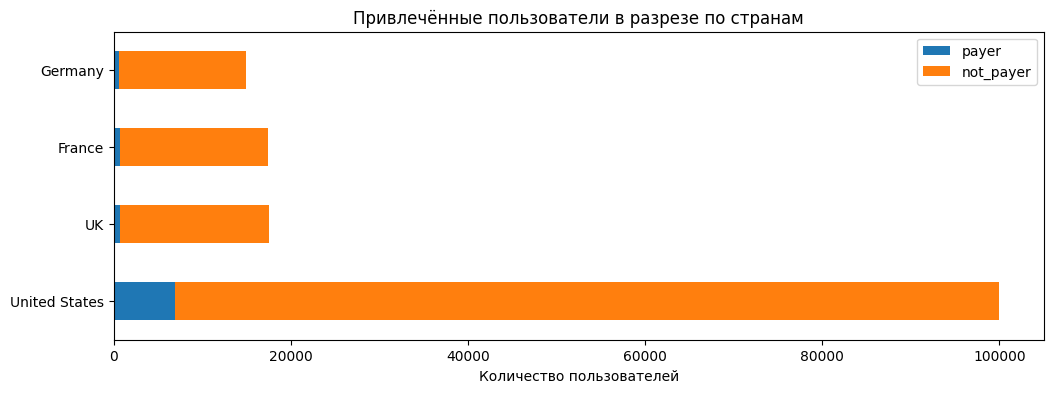

payer,not_payer,payer,"payer, %"
region,,,
United States,93100,6902,6.90
Germany,14365,616,4.11
UK,16875,700,3.98
France,16787,663,3.80


In [29]:
# визуализация количества привлечённых пользователей в разрезе стран
fig, ax = plt.subplots(figsize=(12, 4))
users_by_region[['payer', 'not_payer']].plot(kind='barh', stacked=True, ax=ax)

ax.legend(bbox_to_anchor=(1.0, 1.0))
ax.set_xlabel('Количество пользователей')
ax.set_ylabel('')
ax.set_title('Привлечённые пользователи в разрезе по странам', loc='center')
plt.show()

# расчёт доли привлечённых платящих пользователей в разрезе стран
users_by_region['payer, %'] = (users_by_region.payer / (users_by_region.not_payer + users_by_region.payer) * 100).round(2)
users_by_region.sort_values(by='payer, %', ascending=False)

**Выводы:** подавляющее большинство привлеченных пользователей - из США. Эта же страна лидирует и по количеству платящих пользователей. Страны европейского блока демонстируют примерно одинаковые результаты конверсии, поэтому говорить о втором и третьем месте полагаем неуместным.

<a id=3.3.></a>
### 3.3. Устройства пользователей

Выясним, какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи. Создадим таблицу, отражающую количество пользователей и долю платящих для каждого устройства.

In [30]:
# расчёт количества привлечённых пользователей в разрезе устройств
users_by_devices = profiles.pivot_table(index='device', 
                                       columns='payer', 
                                       values='user_id', 
                                       aggfunc='count')\
.rename(columns={True: 'payer', False: 'not_payer'})\
.sort_values(by='payer', ascending=False)

users_by_devices

payer,not_payer,payer
device,,
iPhone,51097,3382
Android,32982,2050
Mac,28130,1912
PC,28918,1537


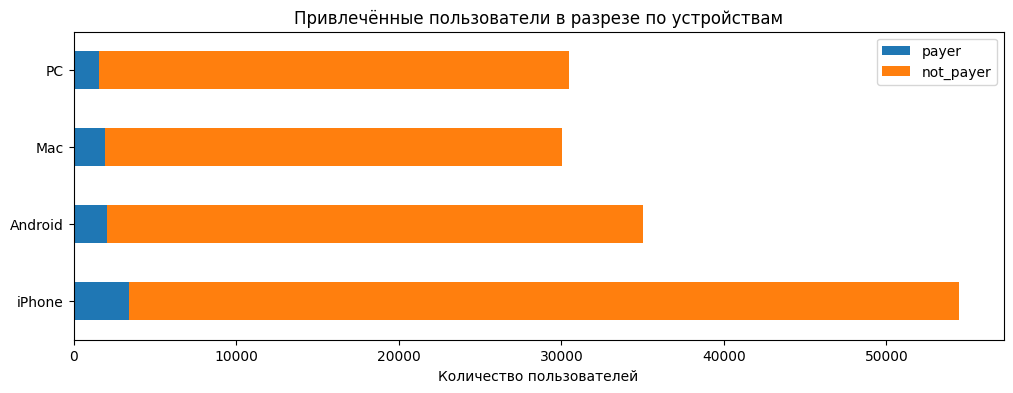

payer,not_payer,payer,"payer_devices, %"
device,,,
Mac,28130,1912,6.36
iPhone,51097,3382,6.21
Android,32982,2050,5.85
PC,28918,1537,5.05


In [31]:
# визуализация количества привлечённых пользователей в разрезе стран
fig, ax = plt.subplots(figsize=(12, 4))
users_by_devices[['payer', 'not_payer']].plot(kind='barh', stacked=True, ax=ax)

ax.legend(bbox_to_anchor=(1.0, 1.0))
ax.set_xlabel('Количество пользователей')
ax.set_ylabel('')
ax.set_title('Привлечённые пользователи в разрезе по устройствам', loc='center')
plt.show()

# расчёт доли привлечённых платящих пользователей в разрезе стран
users_by_devices['payer_devices, %'] = (users_by_devices.payer / (users_by_devices.not_payer + users_by_devices.payer) * 100).round(2)
users_by_devices.sort_values(by='payer_devices, %', ascending=False)

**Выводы:** клиенты приложения используют 4 распространённые платформы: `iPhone`, `Android`, `Mac`, `PC`. При этом, самой популярной платформой у платящих пользователей является `iPhone` (2972 человека), второе место с большим отрывом занимает `Android` (1782 человека). Самая непопулярная платформа у платящих и у неплатящих пользователей - `PC`.

<a id=3.4.></a>
### 3.4. Источники привлечения пользователей

Рассмотрим рекламные источники привлечения и определим каналы, из которых пришло больше всего платящих пользователей. Создадим таблицу, отражающую количество пользователей и долю платящих для каждого канала привлечения.

In [32]:
# расчёт количества привлечённых пользователей в разрезе источников рекламы
users_by_channels = profiles.pivot_table(index='channel', 
                                       columns='payer', 
                                       values='user_id', 
                                       aggfunc='count')\
.rename(columns={True: 'payer', False: 'not_payer'})\
.sort_values(by='payer', ascending=False)

users_by_channels

payer,not_payer,payer
channel,,
FaceBoom,25587,3557
TipTop,17683,1878
organic,55279,1160
WahooNetBanner,8100,453
AdNonSense,3440,440
RocketSuperAds,4096,352
LeapBob,8291,262
OppleCreativeMedia,8372,233
lambdaMediaAds,1924,225


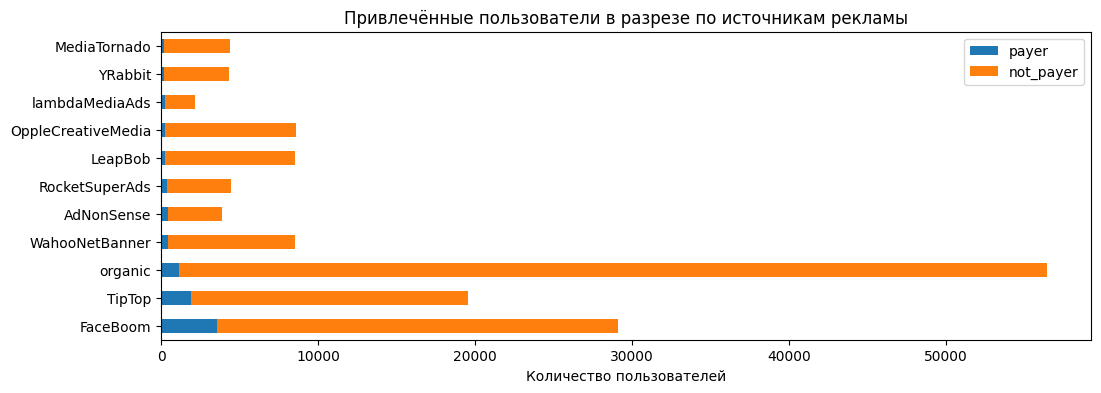

payer,not_payer,payer,"payer_channels, %"
channel,,,
FaceBoom,25587,3557,12.20
AdNonSense,3440,440,11.34
lambdaMediaAds,1924,225,10.47
TipTop,17683,1878,9.60
RocketSuperAds,4096,352,7.91
WahooNetBanner,8100,453,5.30
YRabbit,4147,165,3.83
MediaTornado,4208,156,3.57
LeapBob,8291,262,3.06


In [33]:
# визуализация количества привлечённых пользователей в разрезе источников рекламы
fig, ax = plt.subplots(figsize=(12, 4))
users_by_channels[['payer', 'not_payer']].plot(kind='barh', stacked=True, ax=ax)

ax.legend(bbox_to_anchor=(1.0, 1.0))
ax.set_xlabel('Количество пользователей')
ax.set_ylabel('')
ax.set_title('Привлечённые пользователи в разрезе по источникам рекламы', loc='center')
plt.show()

# расчёт доли привлечённых платящих пользователей в разрезе источников рекламы
users_by_channels['payer_channels, %'] = (users_by_channels.payer / (users_by_channels.not_payer + users_by_channels.payer) * 100).round(2)
users_by_channels.sort_values(by='payer_channels, %', ascending=False)

**Вывод:** два основных канала, `TipTop` и `FaceBoom`, забирают более 80% рекламного бюджета (51.9% и 30.75% соответственно), при этом `TipTop` притягивает только 9.6% платящих пользователей, что свидетельствует о низкой эффективности затрат на этой площадке.

Поисковый маркетинг выделяет 2 способа получить посетителей из поисковых систем:

* **первый способ:** с помощью SEO повысить рейтинг продукта в результатах поиска.

* **второй способ:** использовать контекстную платную рекламу, чтобы размещать объявления в рекламных блоках по нужным поисковым запросам.

Используя SEO-оптимизацию цифрового продукта, мы можем получить бесплатные переходы в режиме 24/7 с одним существенным условием: этот результат потребует **большого количества времени**, поскольку SEO в принципе не может сработать мгновенно. Быстрые результаты гарантирует платная контекстная реклама, но за каждый клик и переход в приложение придётся раскошелиться.

Ещё одно различие между обычным и платным трафиком заключается в том, что после остановки рекламных показов, посещаемость цифрового продукта сразу снизится. В то же время, из-за высокого рейтинга **органические переходы происходят постоянно**, потому они не будут снижаться сразу после прекращения поисковой оптимизации. Высокий рейтинг в выдаче поисковых систем характерен для цифровых продуктов, которые проверены пользователями и сформировали положительную репутацию. Здесь вступает в игру такое понятие, как доверие, и у пользователя, который видит в поисковой выдаче рекомендацию на основе чужого положительного опыта, появляется причина открыть приложение уже только на этом основании. Так формируется фундамент доверительного, положительного отношения к продукту у органического клиента.

Необходимо отметить, что органический трафик - это самый важный вид посетителей, который в принципе может получить цифровой продукт. Он важнее, чем рекламные клики в поиске и пользователи социальных сетей по одной простой причине: **органический трафик является целевым.** Пользователи, которые приходят в Сеть с вопросом в поисковую систему, обладают конкретным намерением. И если наш цифровой продукт - в данном случае, приложение Procrastinate Pro+, сможет дать им то, что они ищут, то с большой долей вероятности мы получим нового клиента или подписчика. А визуальное подтверждение важности и ценности органического источника клиентов нам более чем наглядо показывают графики динамики ROI в разеделе [5.1](#5.1.). данного исследования, где именно с учётом денежных средств, полученных от органических клиентов, приложение вплотную подбирается к порогу окупаемости.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=4></a>
## Шаг 4. Маркетинг

<a id=4.1.></a>
### 4.1. Расчёт общей суммы расходов на маркетинг

In [34]:
# общая сумма затрат на маркетинг
costs['costs'].sum().round()

np.float64(105497.0)

Общая сумма расходов на маркетинг составила 105 497 денежных единиц.

<a id=4.2.></a>
### 4.2. Распределение трат по рекламным источникам

In [35]:
# распределение маркетинговых затрат в разрезе рекламных источников
costs_per_channel = costs.pivot_table(index='channel', values='costs', aggfunc='sum')\
.sort_values(by='costs', ascending=False)
costs_per_channel

# расчёт доли финансирования в разрезе источников рекламы
costs_per_channel ['costs, %'] = (costs_per_channel.costs / 105497 * 100).round(2)
costs_per_channel.sort_values(by='costs, %', ascending=False)

,costs,"costs, %"
channel,,
TipTop,54751.30,51.90
FaceBoom,32445.60,30.75
WahooNetBanner,5151.00,4.88
AdNonSense,3911.25,3.71
OppleCreativeMedia,2151.25,2.04
RocketSuperAds,1833.00,1.74
LeapBob,1797.60,1.70
lambdaMediaAds,1557.60,1.48
MediaTornado,954.48,0.90


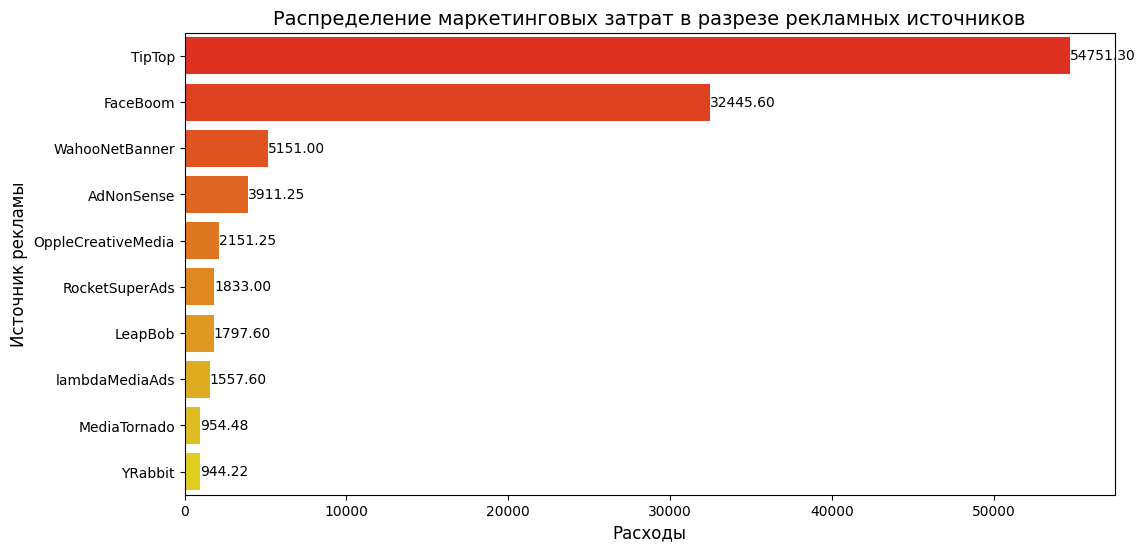

In [36]:
# визуализация распределения маркетинговых затрат в разрезе рекламных источников
costs_per_channel_ghraph = costs_per_channel.reset_index()
plt.figure(figsize=(12,6))

plots = sns.barplot(x='costs', y='channel', data=costs_per_channel_ghraph, palette='autumn')

# подписи данных справа
for p in plots.patches:
    width = p.get_width()
    plt.text(0.5 + p.get_width(), p.get_y()+0.5*p.get_height(), '{:1.2f}'.format(width), ha='left', va='center')    
    
plt.ylabel('Источник рекламы', size=12)
plt.xlabel('Расходы', size=12)
plt.title('Распределение маркетинговых затрат в разрезе рекламных источников', size=14)
plt.show()

Компания весьма активно финансирует рекламу на 10 площадках. Приоритетными являются вложения в рекламу на TipTop и FaceBoom: 54751.30 и 32445.60 денежных единиц соответственно. Минимальные вложения в рекламу на площадке YRabbit за весь период составляют 944.22 денежных единицы.

<a id=4.3.></a>
### 4.3. Динамика изменения расходов во времени (по неделям и месяцам) по каждому источнику

In [37]:
# преобразование типа данных в datetime
costs['dt'] = pd.to_datetime(costs['dt'], errors='coerce')

In [38]:
# создадим два дополнительных признака для дальнейшего построения графиков по неделям и месяцам
costs['week'] = costs['dt'].dt.to_period('W-MON')  # неделя с понедельника
costs['month'] = costs['dt'].dt.to_period('M')     # месяц

In [39]:
# создадим две сводные таблицы с данными по неделям и месяцам
costs_weeks = costs.pivot_table(index=costs['week'], values='costs', columns='channel', aggfunc='sum')
costs_months = costs.pivot_table(index=costs['month'], values='costs', columns='channel', aggfunc='sum')

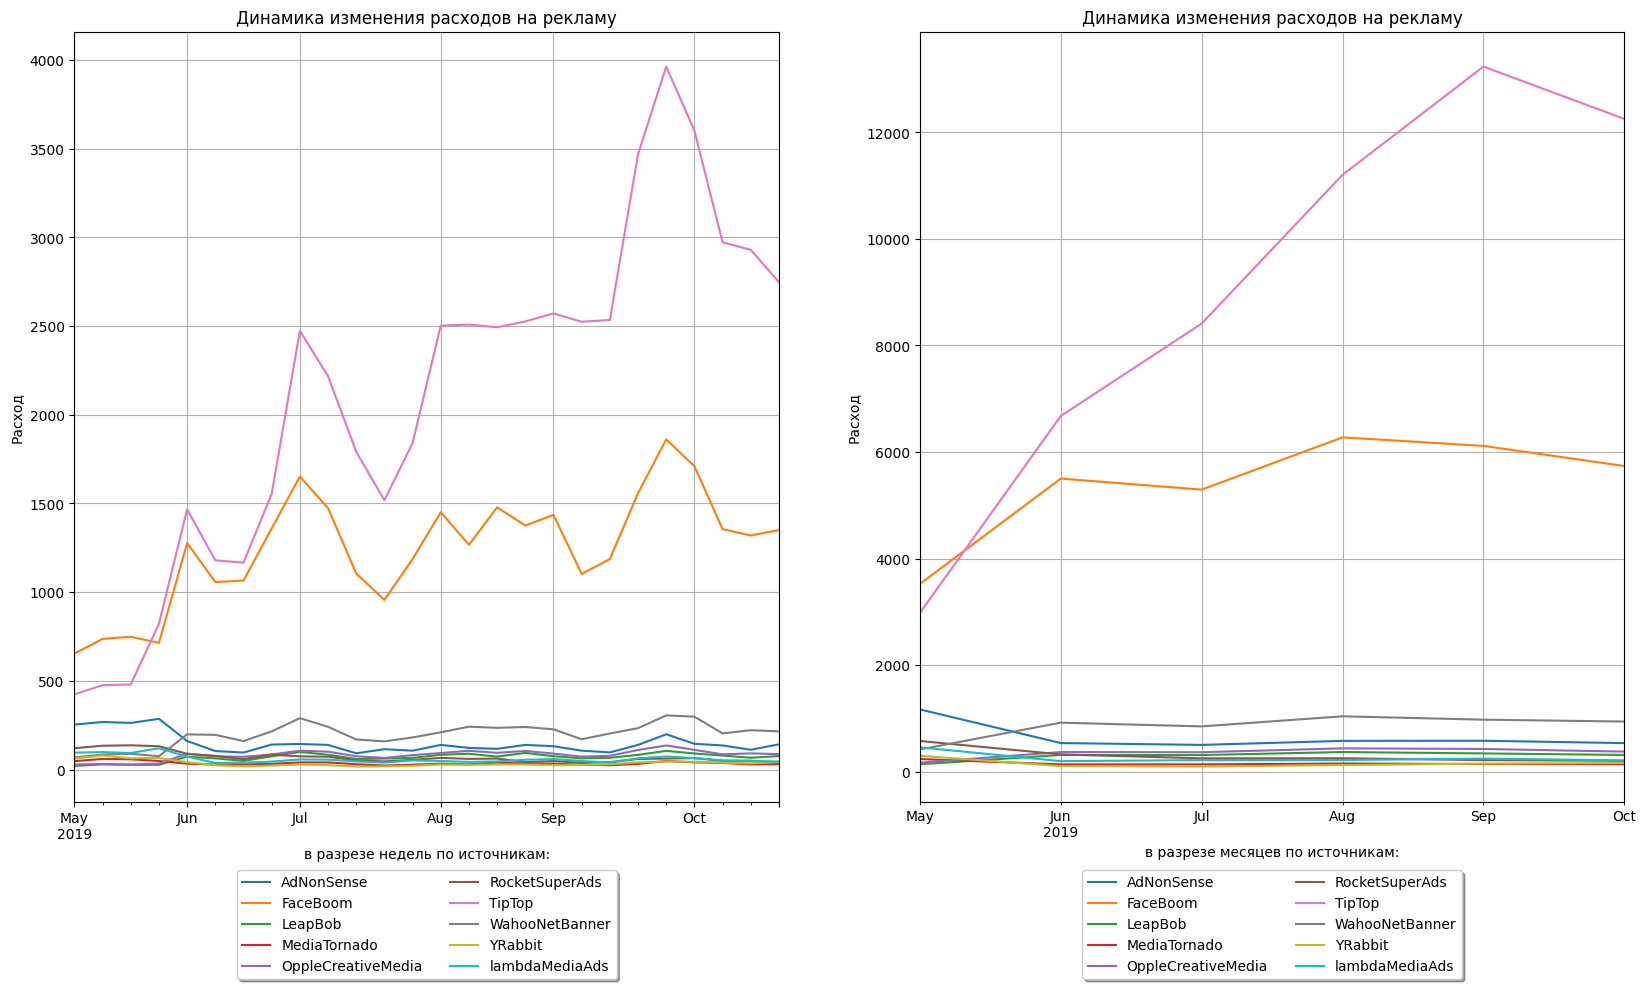

In [40]:
# построение парных графиков динамики расходов во времени
plt.figure(figsize=(20, 10))
ax1 = plt.subplot(1,2,1)
costs_weeks.plot(grid=True, ax=ax1)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), fancybox=True, shadow=True, ncol=2)
plt.title('Динамика изменения расходов на рекламу')
plt.xlabel('в разрезе недель по источникам:')
plt.ylabel('Расход')

ax2 = plt.subplot(1,2,2) # здесь можно применить метод sharey = ax1, но в результате будут одномасштабные,
costs_months.plot(grid=True, ax=ax2)  # но плохочитаемые графики с мешаниной из линий вдоль оси х
ax2.grid(visible=True, which='minor', axis='both', linestyle='-')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), fancybox=True, shadow=True, ncol=2)
plt.title('Динамика изменения расходов на рекламу')
plt.xlabel('в разрезе месяцев по источникам:')
plt.ylabel('Расход')

plt.show()

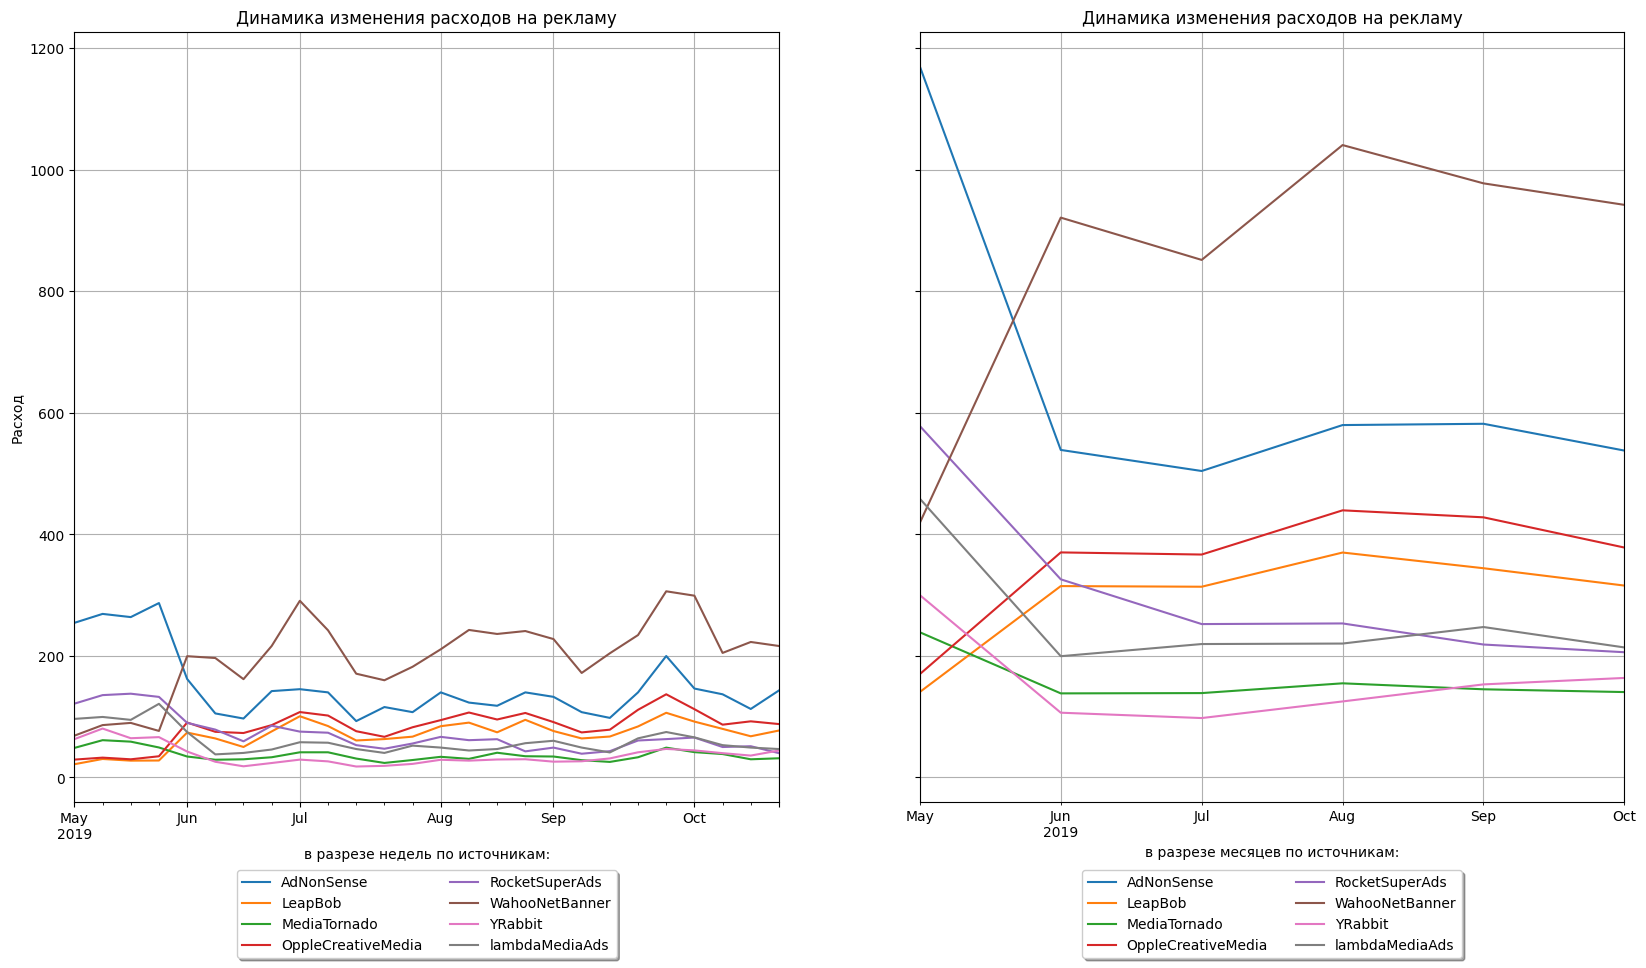

In [41]:
# убираем из дополнительных построений 2 топовых рекламных источника
# чтобы лучше рассмотреть положение дел по другим рекламным каналам
tops = ['FaceBoom', 'TipTop']
costs_dop = costs.query('channel not in @tops')

# собираем новые сводных таблицы бех 2 топовых рекламных источников
costs_weeks_dop = costs_dop.pivot_table(index=costs_dop['week'], values='costs', columns='channel', aggfunc='sum')
costs_months_dop = costs_dop.pivot_table(index=costs_dop['month'], values='costs', columns='channel', aggfunc='sum')

# строим парные графики динамики расходов во времени
plt.figure(figsize=(20, 10))
ax1 = plt.subplot(1,2,1)
costs_weeks_dop.plot(grid=True, ax=ax1)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), fancybox=True, shadow=True, ncol=2)
plt.title('Динамика изменения расходов на рекламу')
plt.xlabel('в разрезе недель по источникам:')
plt.ylabel('Расход')

ax2 = plt.subplot(1,2,2, sharey = ax1)
costs_months_dop.plot(grid=True, ax=ax2)
ax2.grid(visible=True, which='minor', axis='both', linestyle='-')
ax2.grid(visible=True, which='major', axis='both', linestyle='-')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), fancybox=True, shadow=True, ncol=2)
plt.title('Динамика изменения расходов на рекламу')
plt.xlabel('в разрезе месяцев по источникам:')
plt.ylabel('Расход')

plt.show()

Результаты дополнительных построений динамики финансирования рекламных источников за исключением `FaceBoom` и `TipTop` выглядят внушительно. Здесь отчётливо видна смена курса во второй декаде мая 2019 года, когда `AdNonSense` потеряла большую часть прежнего финансирования — её потеснила `WahooNetBanner`. Придонные формы жизни `YRabbit` и `MediaTornado` показывают стабильно низкие вливания. На графике динамики изменений расходов на рекламу в разрезе недель видны два пиковых значения: конец июня и конец сентября, что совпадает с тенденциями, включающими присутствие финансовых тяжеловесов `FaceBoom` и `TipTop`.

**Вывод:** за весь период идёт очень активное вливание денежных средств преимущественно в два популярных канала с очень широким охватом аудитории `TipTop` и `FaceBoom`. И если `FaceBoom` финансируется довольно ровно (разбег от 4000 до 6000 денежных единиц), то продвижение рекламы на `TipTop` заставляет с изумлением смотреть на пик Эвереста затрат: больше 12500 денежных единиц в сентябре 2019 года, похоже, стал поворотным моментом для сворачивания деятельности на этом пространстве. В общем и целом, в сентябре - октябре 2019 года было принято решение о сокращении финансирования двух основных каналов рекламы, при сохранении объёма бюджета по остальным источникам. 

<a id=4.4.></a>
### 4.4. Средняя стоимость привлечение одного пользователя из каждого источника

Стоимость привлечения клиента (САС или Customer Acquisition Cost) — очень показательная метрика для "здоровья" бизнеса. Рассчитаем средний CAC на одного пользователя для всего периода, используя профили пользователей. При этом следует исключить из анализа канал `'Organic'`, поскольку этот канал привлечения по своей природе не стоит дополнительных расходов и его представители находят приложение самостоятельно.

In [42]:
# средняя стоимость привлечения клиента
mean_cac_per_id = (profiles.query('channel != "organic"')[['user_id', 'acquisition_cost']]
              .drop_duplicates()
              .agg({'acquisition_cost': 'mean'}))
mean_cac_per_id.round(2)

acquisition_cost    1.13
dtype: float64

In [43]:
# расчёт средней стоимости привлечения одного пользователя в разрезе источников рекламы
mean_cac_per_channel = (profiles.pivot_table(index = 'channel', 
                                             values = 'acquisition_cost', 
                                             aggfunc='mean')
       .sort_values(by='acquisition_cost', ascending=False).rename(
           columns={'acquisition_cost': 'CAC'}))
mean_cac_per_channel.round(2)

,CAC
channel,
TipTop,2.80
FaceBoom,1.11
AdNonSense,1.01
lambdaMediaAds,0.72
WahooNetBanner,0.60
RocketSuperAds,0.41
OppleCreativeMedia,0.25
YRabbit,0.22
MediaTornado,0.22


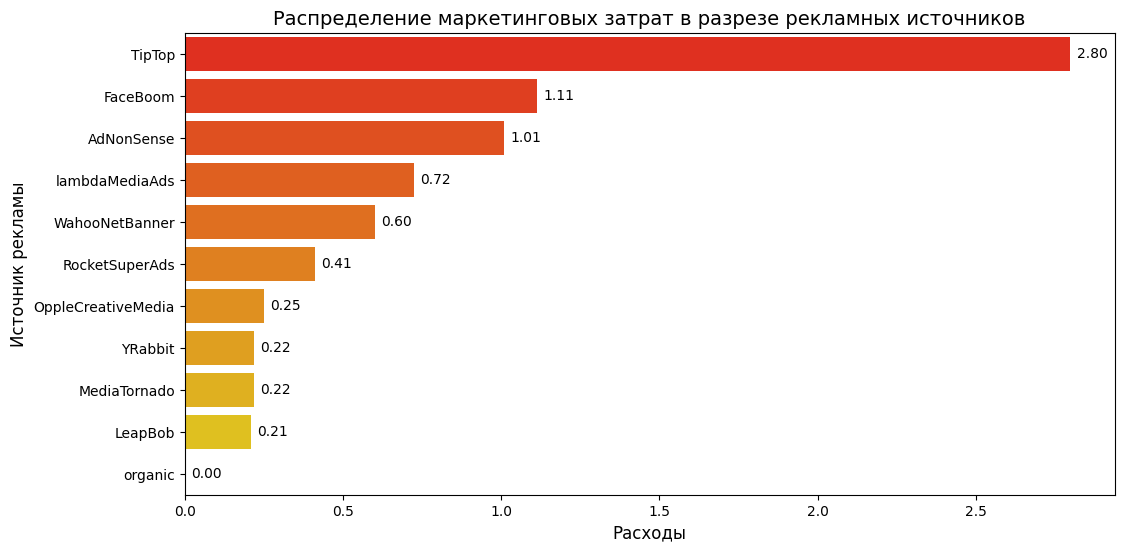

In [44]:
# визуализация распределения маркетинговых затрат в разрезе рекламных источников
mean_cac_per_channel_ghraph = mean_cac_per_channel.reset_index()
plt.figure(figsize=(12,6))

plots = sns.barplot(x='CAC', y='channel', data=mean_cac_per_channel_ghraph, palette='autumn')

for p in plots.patches:
    width = p.get_width()
    plt.text(0.02 + p.get_width(), p.get_y()+0.5*p.get_height(), '{:1.2f}'.format(width), ha='left', va='center')

plt.ylabel('Источник рекламы', size=12)
plt.xlabel('Расходы', size=12)
plt.title('Распределение маркетинговых затрат в разрезе рекламных источников', size=14)
 
plt.show()

**Вывод:** дороже всего приложению обходится пользователь, которого привлекли просредством `TipTop`, САС по остальным каналам рекламы не превышает уровень общего среднего значения в 1.13 денежных единиц. 

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=5></a>
## Шаг 5. Оценка окупаемости рекламы

необходимо проанализировать окупаемость рекламы с опорой на визуализацию графиков LTV, ROI и CAC. Примем за отправную точку, что на календаре 1 ноября 2019 года, а в бизнес-плане заложено, что пользователи должны окупаться не позднее чем через две недели после привлечения. Необходимость включения в анализ органических пользователей определяем самостоятельно.

Окупаемость инвестиций в рекламу `ROI` (или Return On Investment) показывает, на сколько процентов `LTV` превысил `CAC`. Иными словами, на сколько процентов «окупились» клиенты. Следовательно, для расчёта этой метрики нам понадобятся значения `LTV` (или Lifetime Value) — общая сумма денег, которую один клиент в среднем приносит приложению со всех своих покупок, а также `CAC` (или Customer Acquisition Cost) — стоимость привлечения одного клиента, то есть сумма денег, в которую компании обходится каждый новый клиент.

<a id=5.1.></a>
### 5.1. Окупаемость рекламы по графикам LTV и ROI, а также по графикам динамики LTV, CAC и ROI

В этом разделе исследования нам понадобятся функции `def get_ltv` для расчёта LTV и ROI, а также функция для сглаживания фрейма `def filter_data`. В связи с анализом окупаемости инвестиций в рекламу полагаем возможным привести сравнительные построения с учётом и с исключением из данных органических пользователей, поскольку привнесённый ими доход не потребовал инвестиций компании, владеющей приложением Procrastinate Pro+. Сравним полученные результаты и сделаем выводы на их основе.

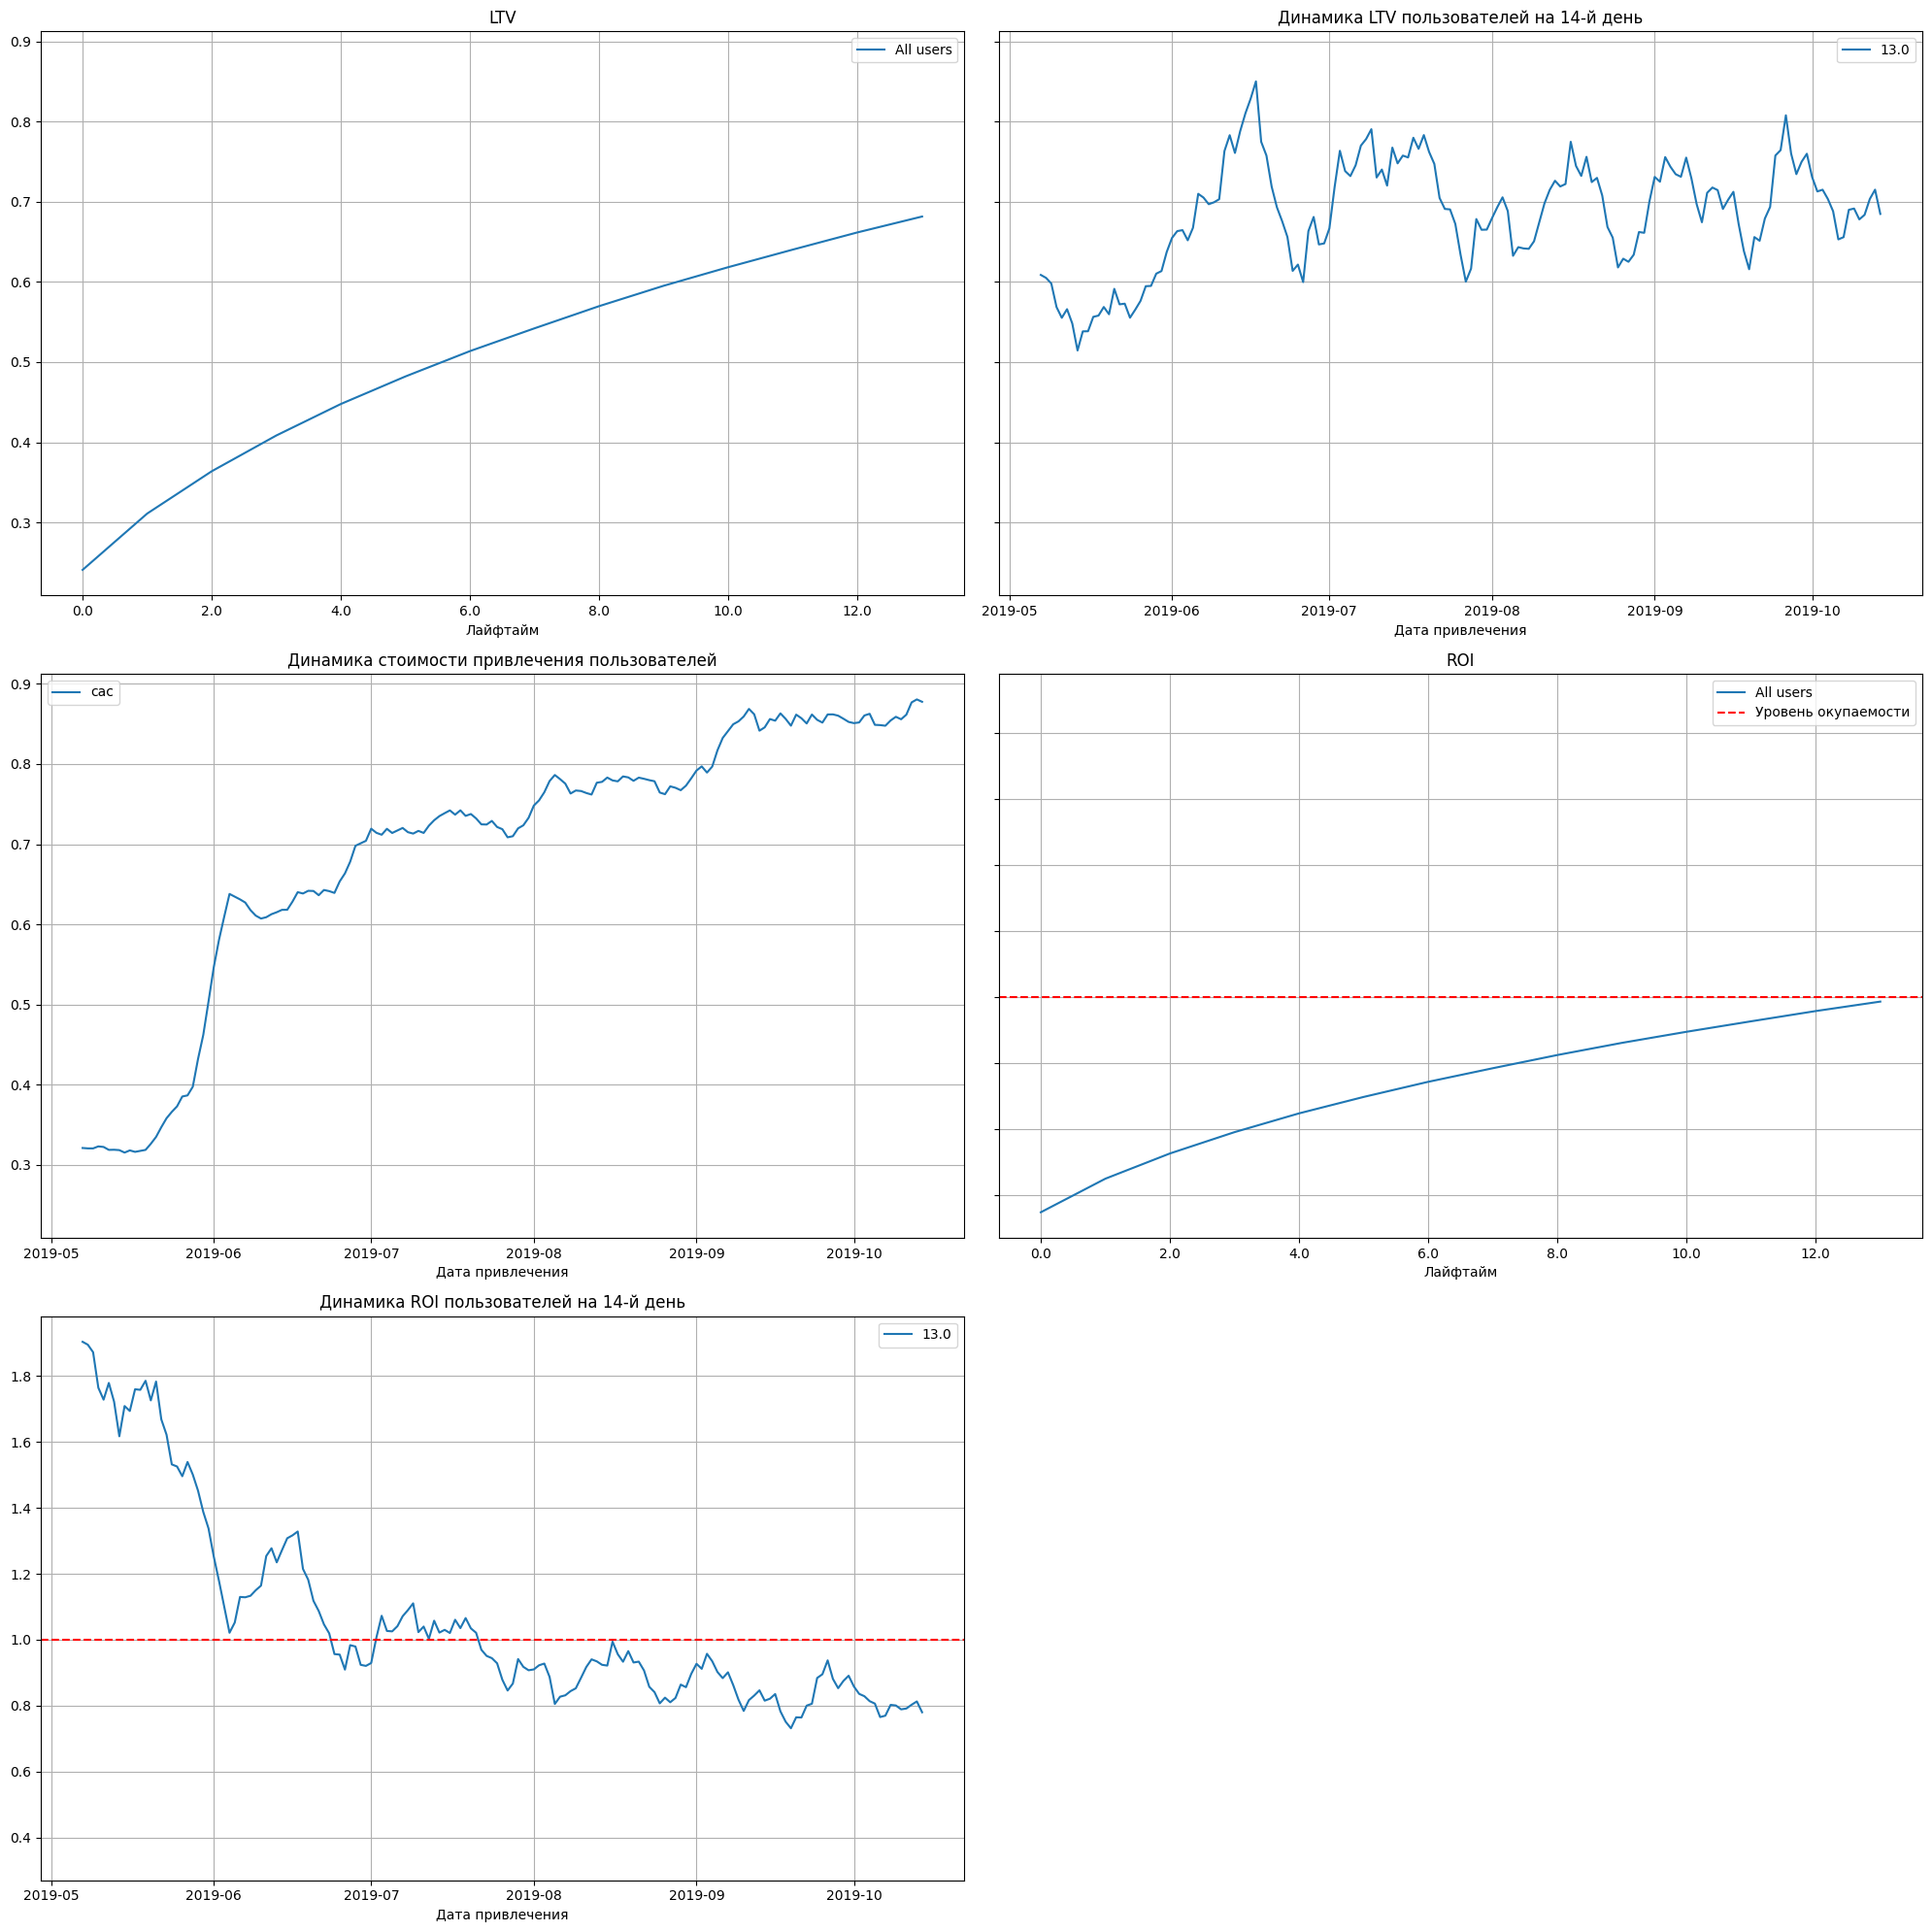

In [45]:
# считаем LTV и ROI с учётом органических пользователей
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(profiles, orders, observation_date, horizon_days)

# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days)

In [46]:
# срезаем профили по каналу 'organic'
profiles = profiles.query('channel != "organic"')

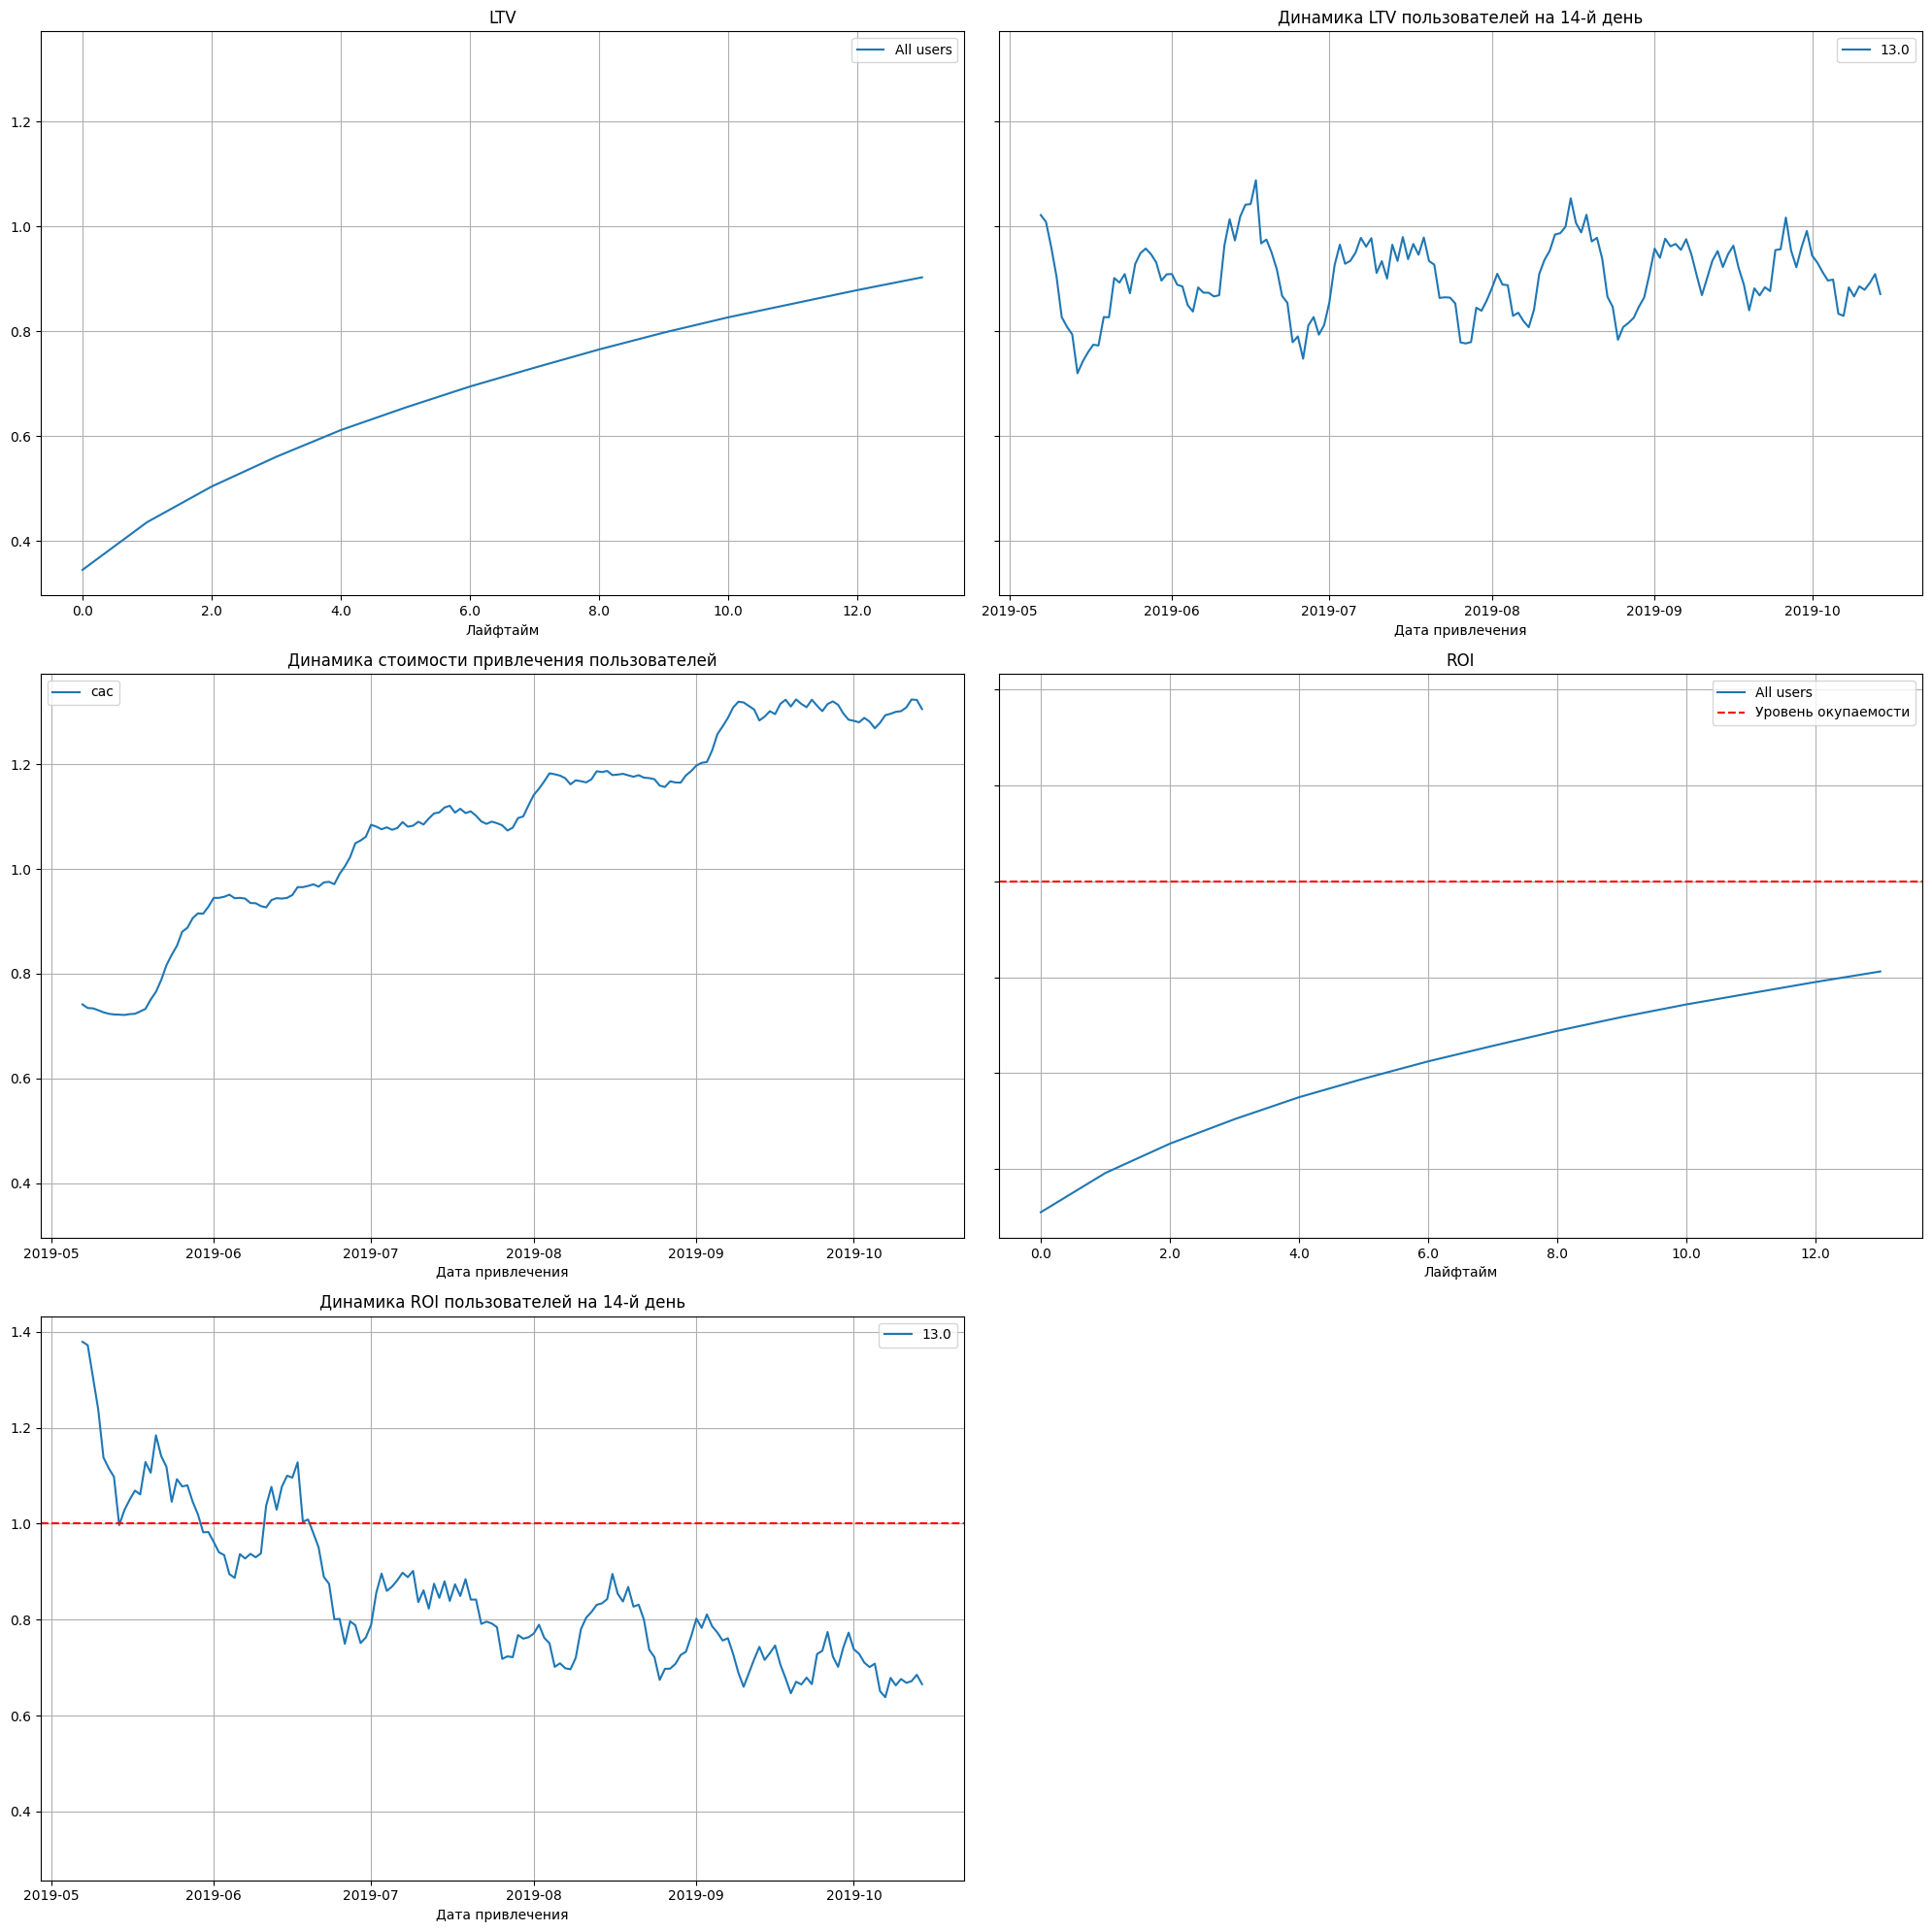

In [47]:
# считаем LTV и ROI без органических пользователей
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(profiles, orders, observation_date, horizon_days)

# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days)

**Выводы:** LTV достаточно стабильно растет. САС привлечения клиентов растёт на всём периоде. При этом, ROI на всём лайфтайме так и не доходит до окупаемости. Однако, стоит внимательно посмотреть на график динамики ROI и становится очевидным период, когда начались реальные проблемы: это середина мая - начало июня 2019 года. В середине мая 2019 года реклама ещё окупалась, робкая попытка выйти в плюс отмечается на этом же графике в период середины июня 2019 года, однако, далее динамика стала стабильно отрицательной. Полагаем необходимым владельцам приложения рассмотреть документацию и стратегию за указанный период, провести сравнительный анализ и на местности определиться, где случился поворот в никуда, дату этого решения мы уже установили.

<a id=5.2.></a>
### 5.2. Конверсия пользователей и динамика её изменения. Удержание пользователей и динамика его изменения

Для этого аналитического раздела нам потребуются парные функции расчёта метрик и построения графиков конверсии `get_conversion` и `plot_conversion`, а также удержания `get_retention` и `plot_retention`. В начале мы посмотрим общую конверсию и удержание, а затем рассмотрим эти метрики по дополнительным признакам.

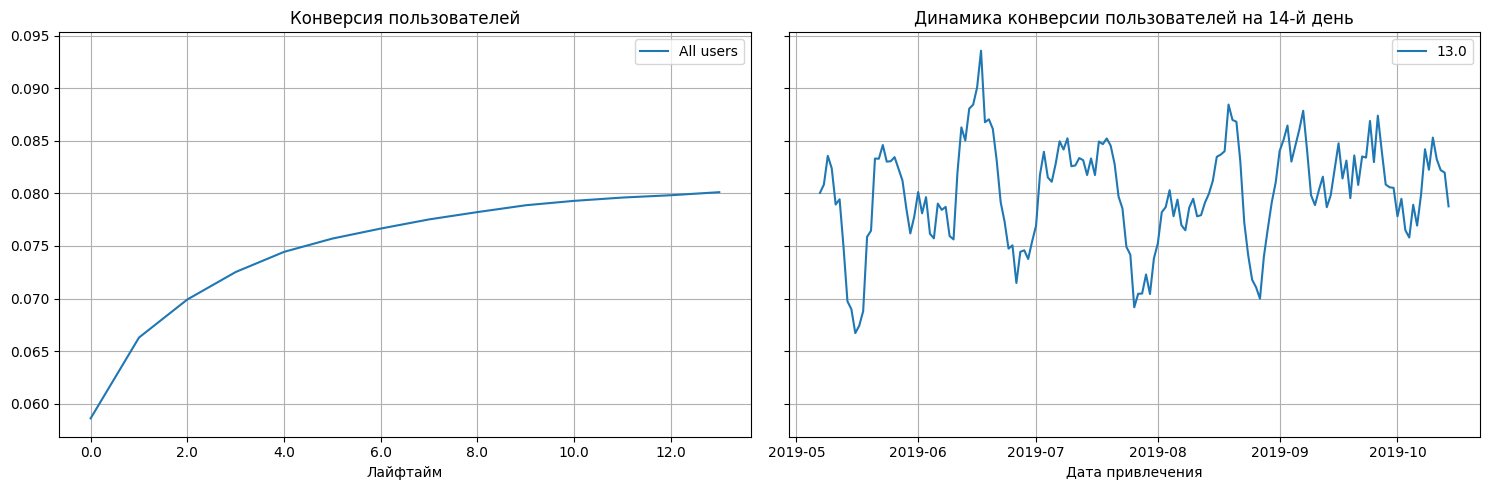

In [48]:
# расчёт конверсии и её динамики
conversion_raw, conversion, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days)

# построение графика конверсии и динамики изменения конверсии
plot_conversion(conversion, conversion_history, horizon_days)

In [49]:
# таблица конверсии
display(conversion)
print()
# таблица динамики конверсии
display(conversion_history)

,cohort_size,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0
cohort,,,,,,,,,,,,,,,
All users,86138,0.058604,0.066289,0.069911,0.072523,0.074439,0.075704,0.076656,0.077527,0.078223,0.078873,0.079291,0.079605,0.079825,0.080116


,cohort_size,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0
dt,,,,,,,,,,,,,,,
2019-05-01,390,0.058974,0.066667,0.071795,0.071795,0.076923,0.076923,0.076923,0.079487,0.082051,0.082051,0.082051,0.082051,0.082051,0.082051
2019-05-02,323,0.058824,0.068111,0.068111,0.068111,0.068111,0.068111,0.068111,0.068111,0.068111,0.068111,0.071207,0.071207,0.071207,0.071207
2019-05-03,346,0.057803,0.069364,0.075145,0.078035,0.083815,0.083815,0.083815,0.083815,0.083815,0.083815,0.083815,0.083815,0.083815,0.086705
2019-05-04,457,0.070022,0.074398,0.076586,0.078775,0.085339,0.085339,0.087527,0.089716,0.089716,0.091904,0.091904,0.091904,0.091904,0.091904
2019-05-05,438,0.036530,0.043379,0.047945,0.052511,0.052511,0.052511,0.052511,0.052511,0.052511,0.052511,0.052511,0.052511,0.052511,0.052511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-10-10,511,0.082192,0.088063,0.091977,0.093933,0.097847,0.101761,0.101761,0.103718,0.103718,0.105675,0.105675,0.105675,0.105675,0.105675
2019-10-11,615,0.039024,0.045528,0.050407,0.050407,0.053659,0.053659,0.055285,0.055285,0.055285,0.055285,0.055285,0.055285,0.055285,0.055285
2019-10-12,607,0.057661,0.062603,0.072488,0.072488,0.072488,0.072488,0.074135,0.074135,0.075783,0.075783,0.075783,0.075783,0.075783,0.075783


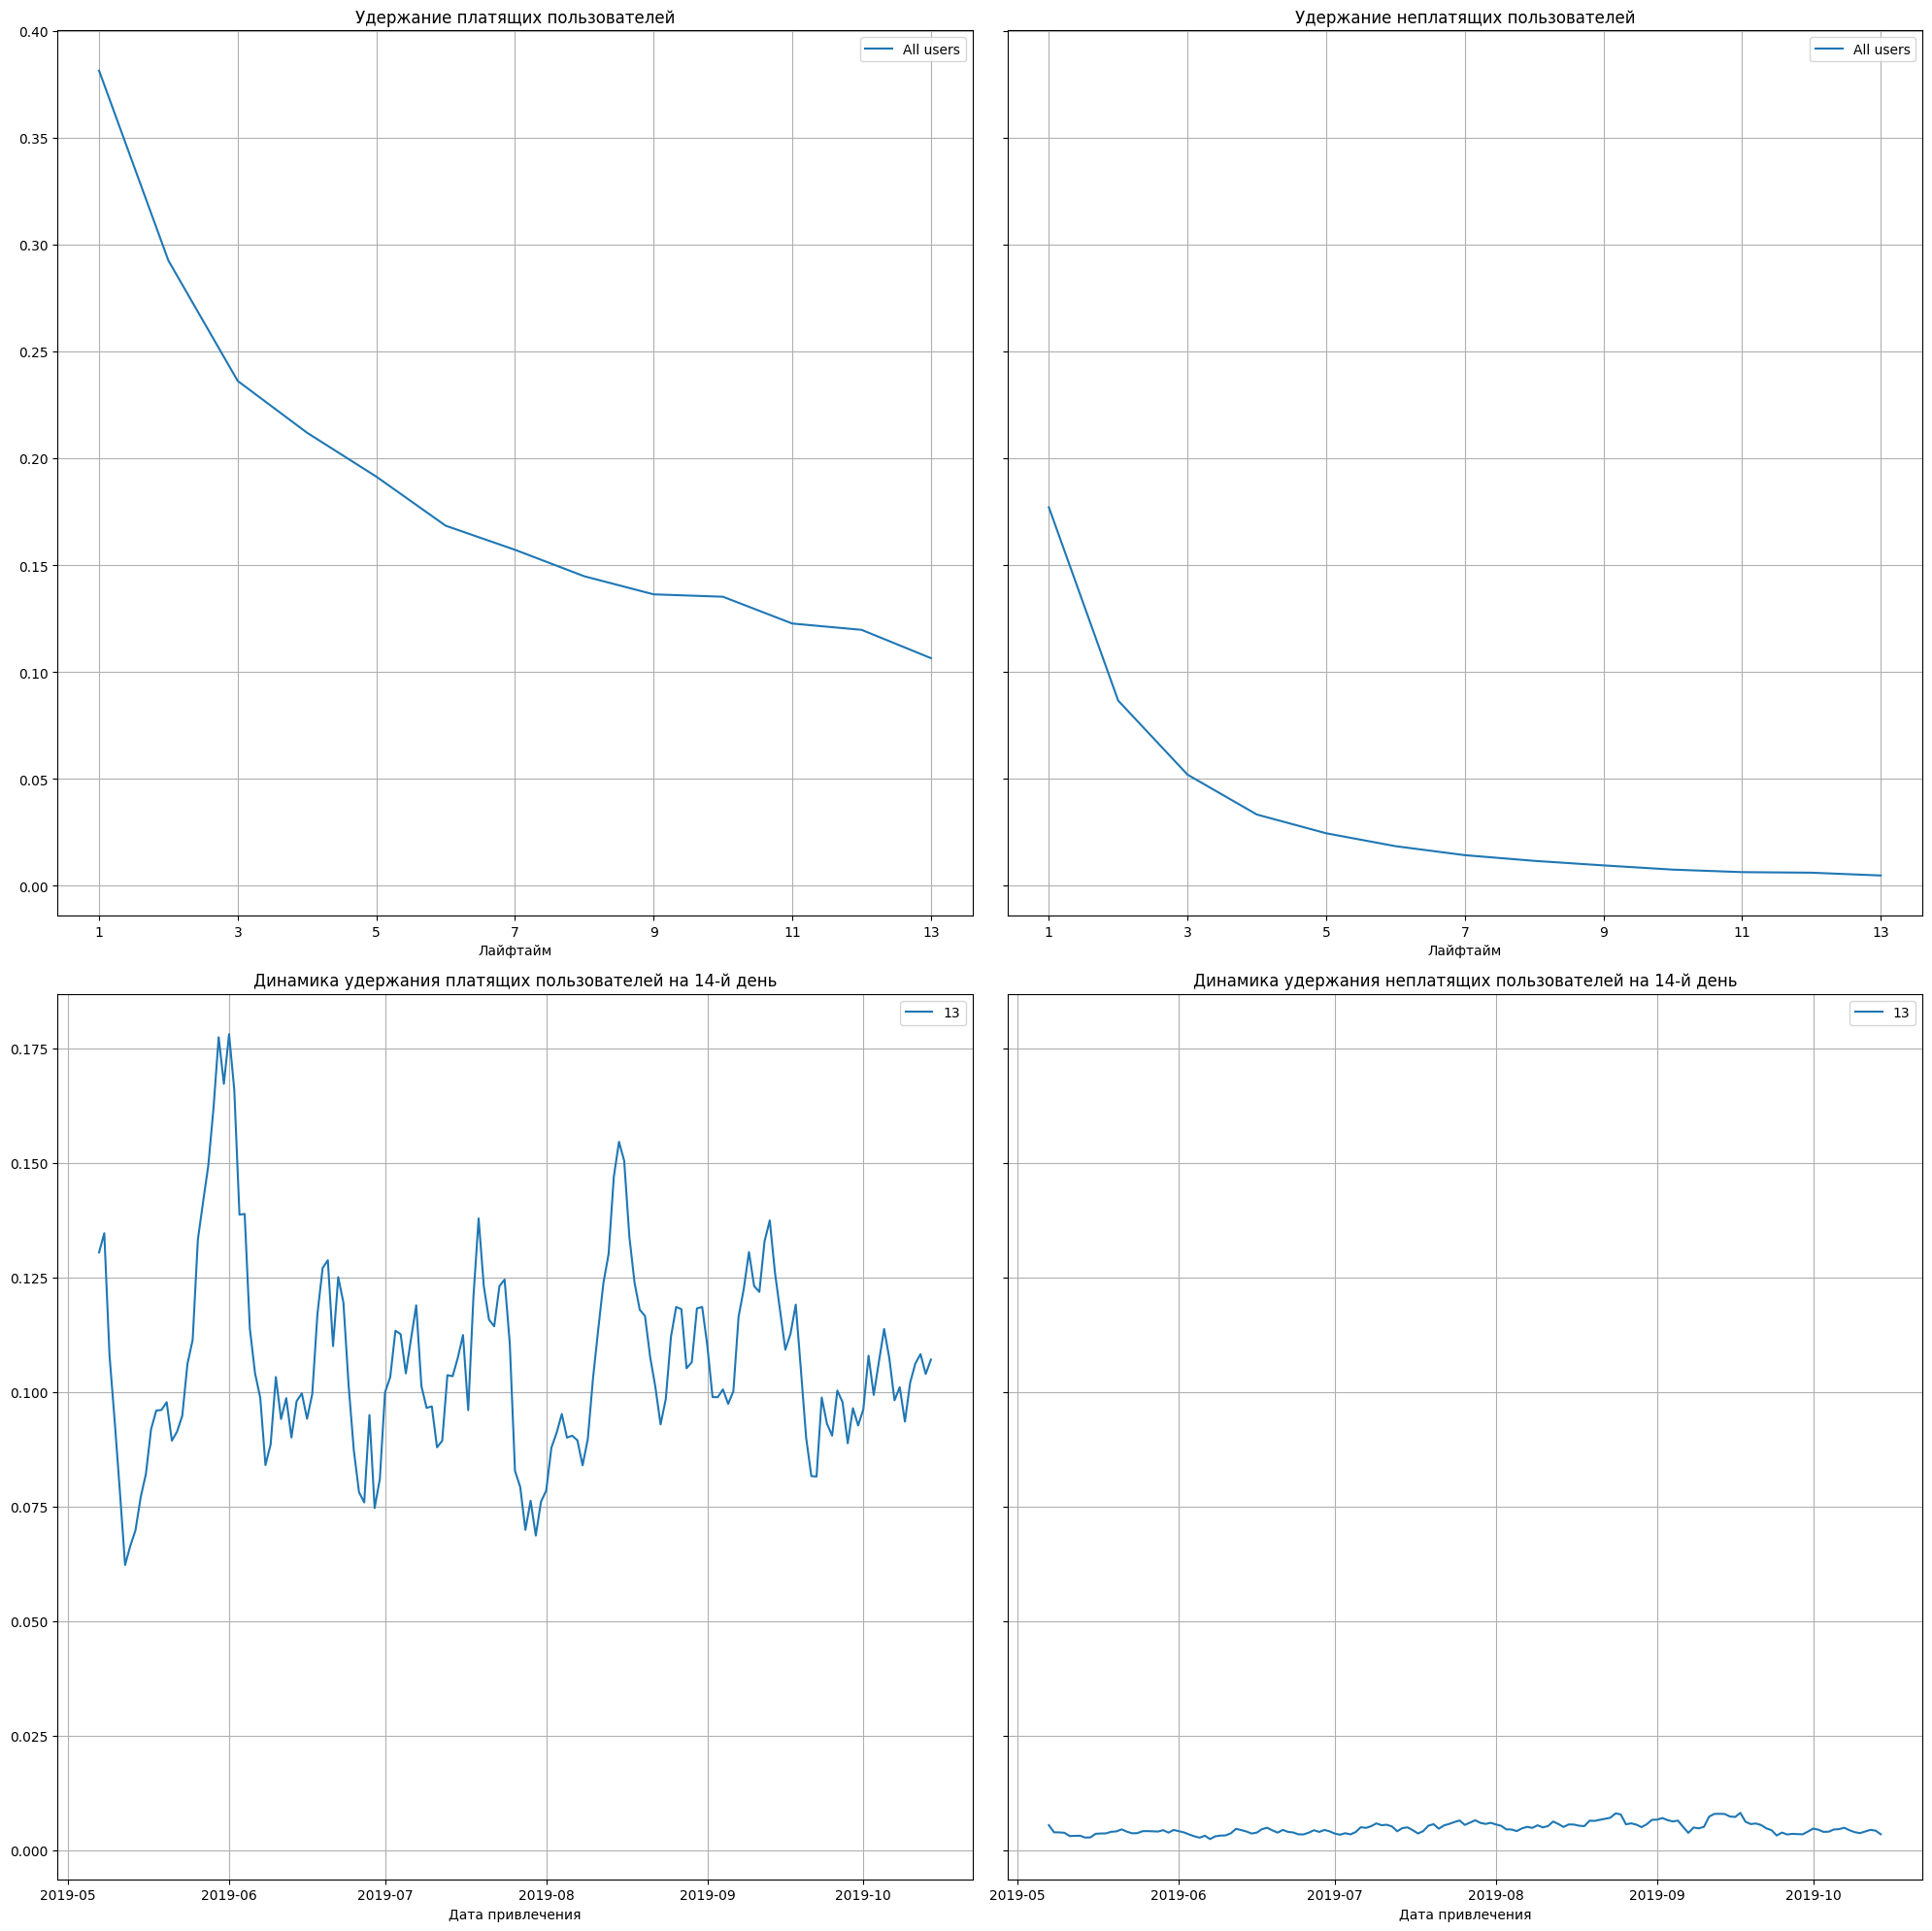

In [50]:
# расчёт удержания и его динамики
retention_raw, retention, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days)

# построение графика удержания и динамики изменения удержания
plot_retention(retention, retention_history, horizon_days)

In [51]:
# таблица удержания
display(retention)
print()
# таблица динамики удержания
display(retention_history)

,cohort_size,0,1,2,3,4,5,6,7,8,9,10,11,12,13
payer,,,,,,,,,,,,,,,
False,79036,1.0,0.177021,0.086593,0.051951,0.033289,0.024520,0.018485,0.014272,0.011615,0.009489,0.007516,0.006339,0.006073,0.004770
True,7102,1.0,0.381301,0.292453,0.236131,0.211912,0.191355,0.168403,0.157139,0.144748,0.136300,0.135173,0.122642,0.119685,0.106449


cohort_size    0         1         2         3         4  \
payer dt                                                                     
False 2019-05-01          358  1.0  0.212291  0.072626  0.061453  0.022346   
      2019-05-02          300  1.0  0.196667  0.103333  0.033333  0.030000   
      2019-05-03          315  1.0  0.180952  0.076190  0.066667  0.028571   
      2019-05-04          413  1.0  0.164649  0.101695  0.058111  0.024213   
      2019-05-05          412  1.0  0.191748  0.092233  0.065534  0.033981   
...                       ...  ...       ...       ...       ...       ...   
True  2019-10-10           54  1.0  0.388889  0.333333  0.185185  0.277778   
      2019-10-11           34  1.0  0.529412  0.205882  0.264706  0.264706   
      2019-10-12           48  1.0  0.291667  0.333333  0.208333  0.145833   
      2019-10-13           41  1.0  0.292683  0.219512  0.268293  0.292683   
      2019-10-14           41  1.0  0.292683  0.292683  0.243902  0.170732   

                         5         6         7         8         9        10  \
payer dt                                                                       
False 2019-05-01  0.011173  0.025140  0.011173  0.013966  0.008380  0.000000   
      2019-05-02  0.016667  0.023333  0.010000  0.006667  0.006667  0.010000   
      2019-05-03  0.028571  0.031746  0.015873  0.009524  0.003175  0.006349   
      2019-05-04  0.021792  0.014528  0.007264  0.021792  0.009685  0.012107   
      2019-05-05  0.021845  0.014563  0.019417  0.009709  0.000000  0.007282   
...                    ...       ...       ...       ...       ...       ...   
True  2019-10-10  0.148148  0.148148  0.203704  0.111111  0.259259  0.148148   
      2019-10-11  0.088235  0.147059  0.117647  0.205882  0.176471  0.088235   
      2019-10-12  0.166667  0.104167  0.208333  0.083333  0.125000  0.083333   
      2019-10-13  0.243902  0.268293  0.073171  0.170732  0.146341  0.170732   
      2019-10-14  0.097561  0.121951  0.121951  0.121951  0.073171  0.073171   

                        11        12        13  
payer dt                                        
False 2019-05-01  0.011173  0.002793  0.013966  
      2019-05-02  0.010000  0.016667  0.003333  
      2019-05-03  0.003175  0.006349  0.003175  
      2019-05-04  0.016949  0.002421  0.007264  
      2019-05-05  0.009709  0.012136  0.002427  
...                    ...       ...       ...  
True  2019-10-10  0.240741  0.129630  0.092593  
      2019-10-11  0.117647  0.117647  0.147059  
      2019-10-12  0.020833  0.041667  0.083333  
      2019-10-13  0.121951  0.219512  0.073171  
      2019-10-14  0.048780  0.121951  0.121951  

[334 rows x 15 columns]

На общих графиках конверсия и удержание выглядят весьма печально. На всём лайфтайме конверсия растёт, но в этом росте отчётливо видны "силовые" рывки. Поскольку рекламные кампании влияют только на День 0 (момент привлечения), эти пики в середине лайфтайма (на 7-10 день) не могут быть связаны с датами закупки рекламы. С высокой долей вероятности такие рывки свидетельствуют о внутренних триггерах приложения: push-уведомлениях, email-рассылках, начислении бонусов или выходах обновлений, которые заставили пользователей вернуться и совершить покупку.

Таблица и графики удержания подтверждают общее правило: платящие пользователей меньше и удерживаются они лучше, чем неплатящие, пребывающие в численном большинстве. Соединяя информацию графика конверсии и удержания, мы можем свидетельствовать о рекламной кампании начала июня 2019 года: напоминания и интересные предложения, полученные пользователями накануне, через неделю - полторы сконвертировались в покупки. Аналогичным образом выглядит ситуация конца августа - начала сентября 2019 года: вовремя сделанный анонс привёл пользователей к покупке.

Но факт остаётся фактом: абсолютное большинство пользователей приложения открывают его единожды. У пользователей нет стимула открывать приложение каждый месяц или неделю на протяжении всего календарного года. Оставшееся меньшинство пользователей, вероятно, следят за новинками.

Мы можем рассмотреть эти метрики и их динамику по признакам, представляющим интерес для нашего исследования: география пользователей, устройства пользователей, а также источники рекламы.

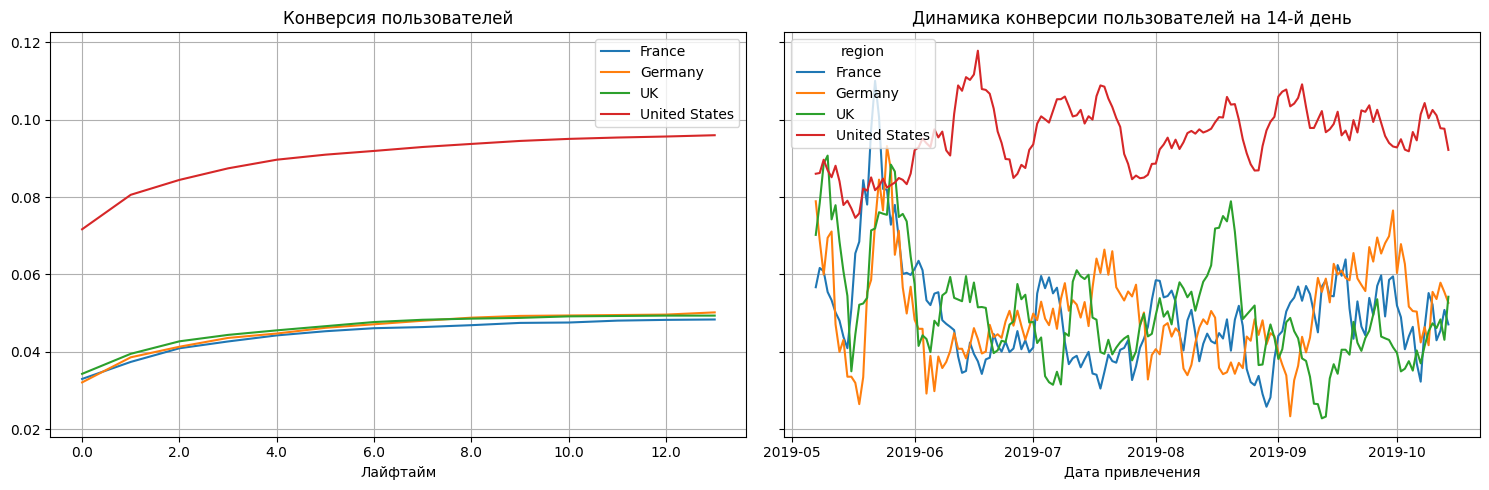

In [52]:
# вычислим конверсию в разрезе по странам
dimensions = ['region']

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions)

# построение графика конверсии и динамики изменения конверсии в разрезе стран
plot_conversion(conversion_grouped, conversion_history, horizon_days)

График конверсии пользователей США выглядит как настоящее явление: метрика конверсии в 2.25 раза выше конверсии пользователей из других стран.

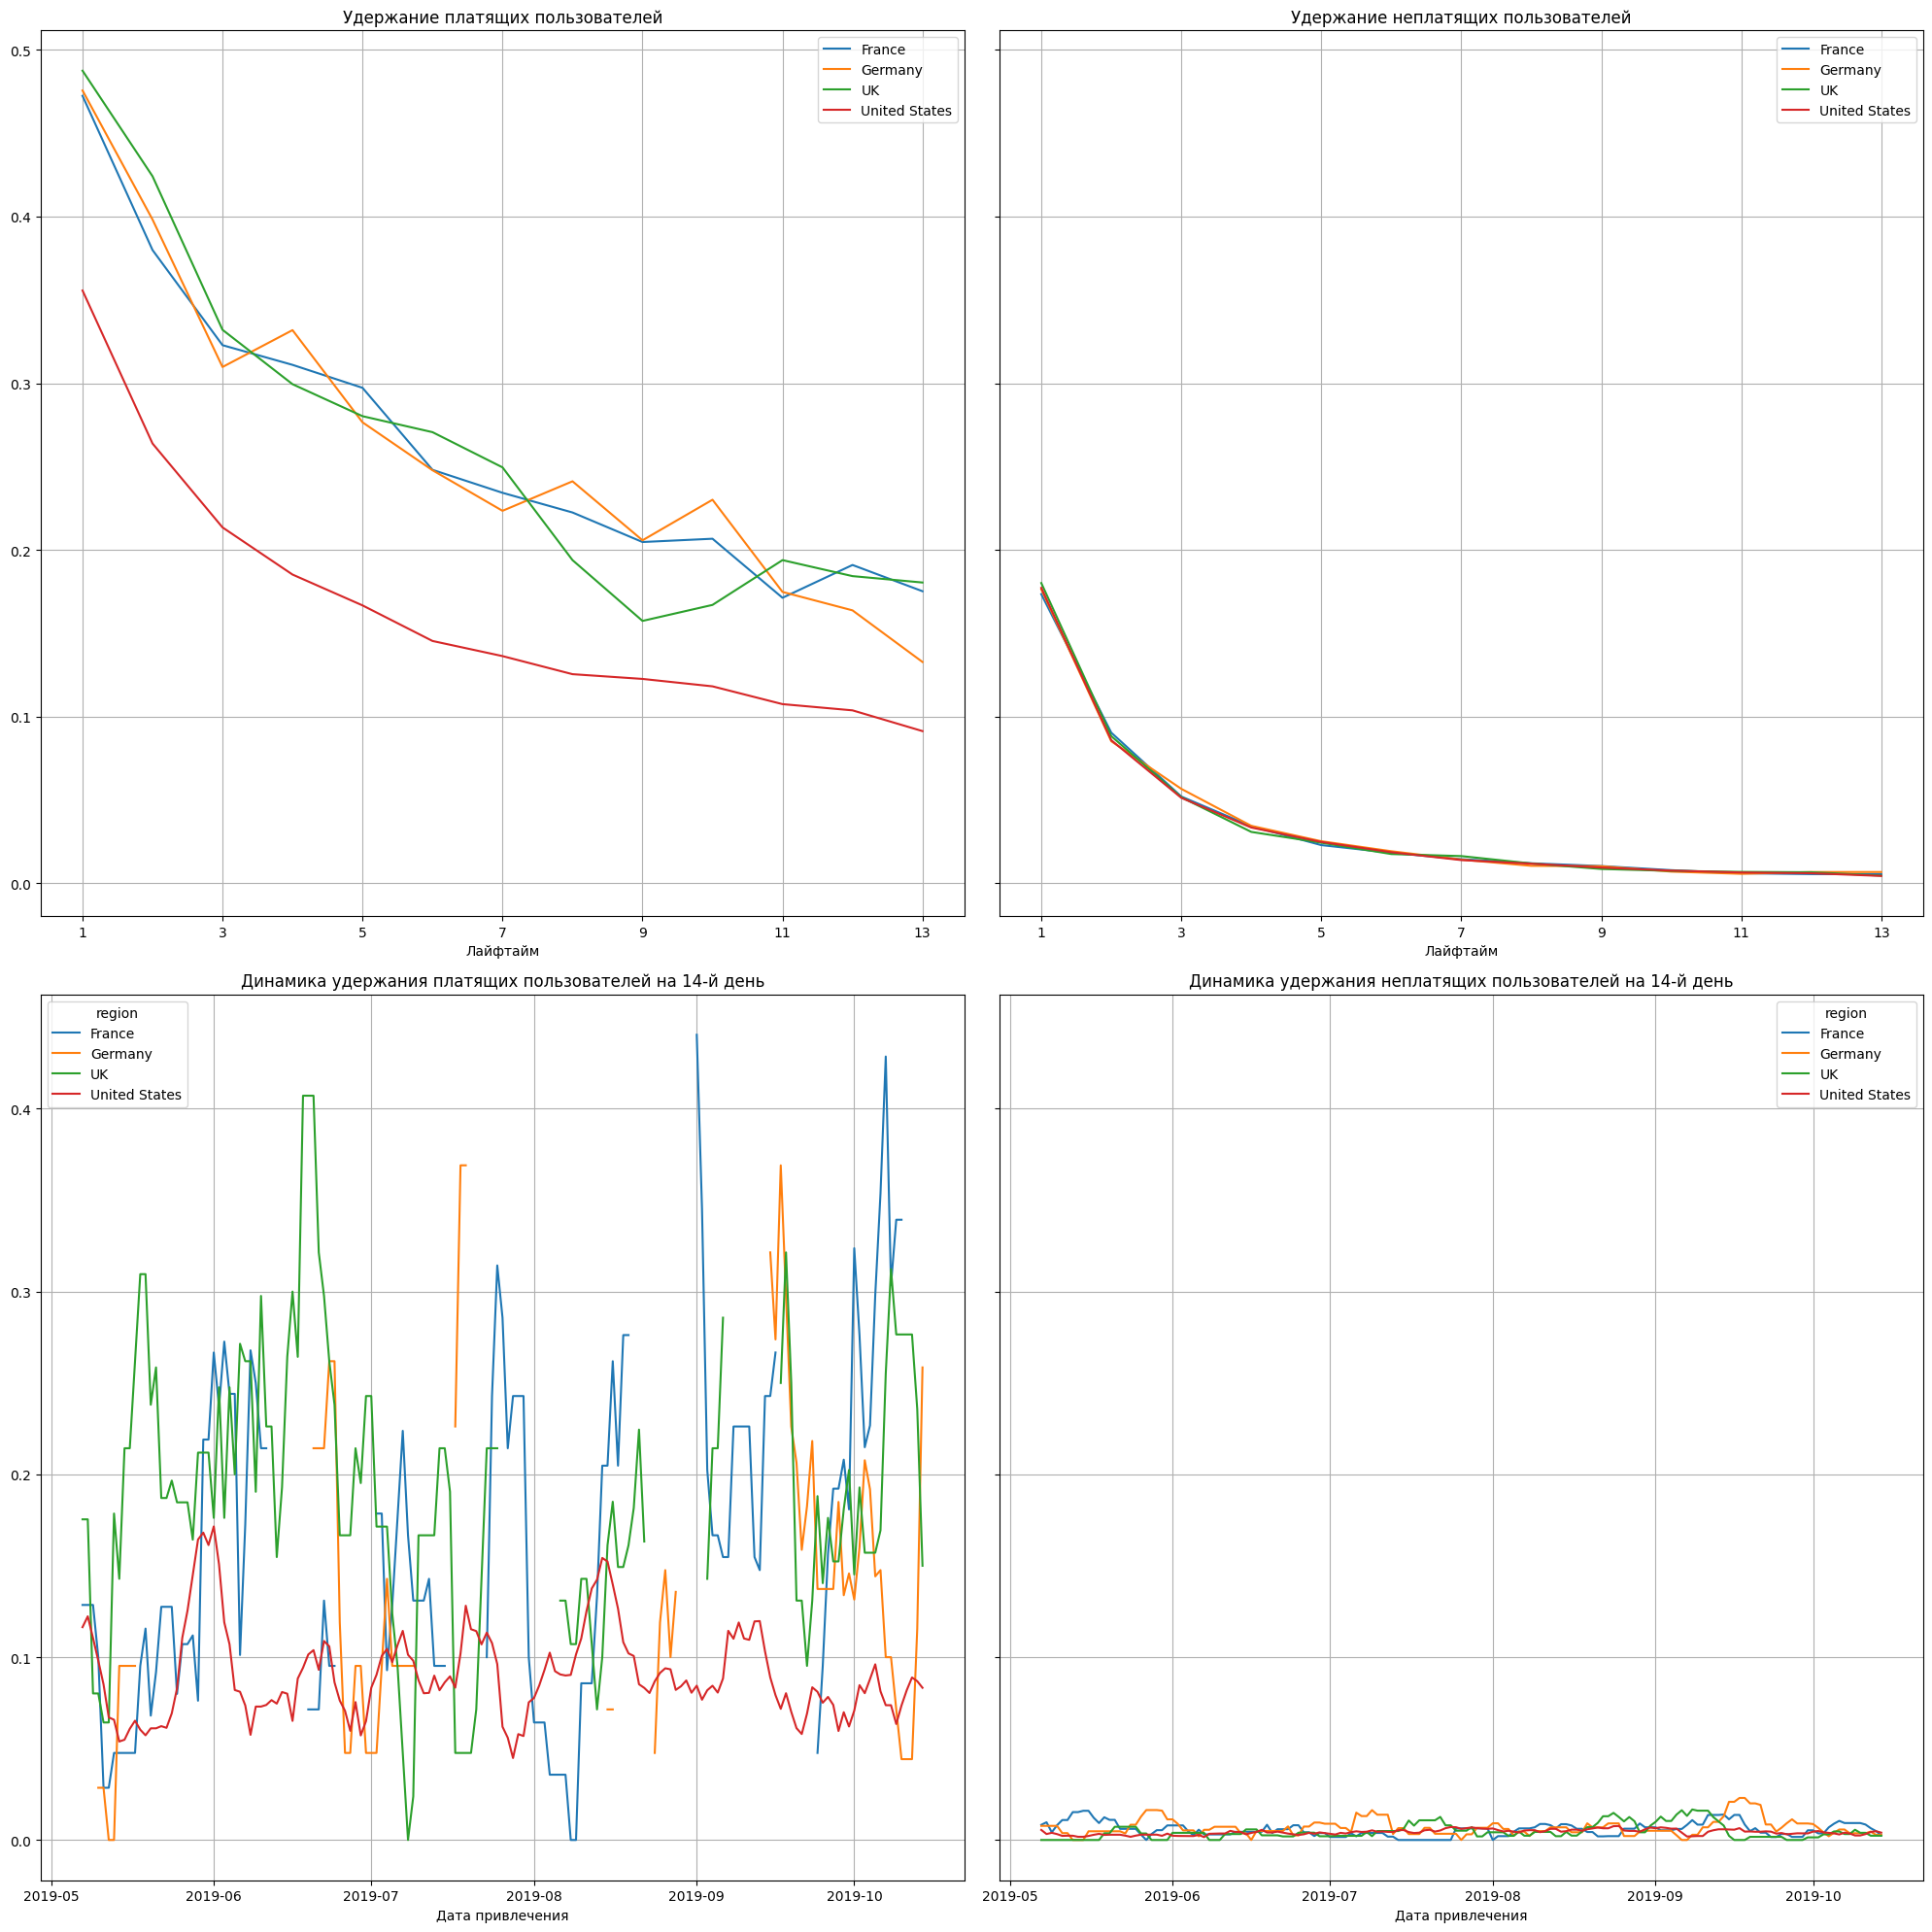

In [53]:
# вычислим удержание в разрезе по странам
dimensions = ['region']

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions)

# построение графика удержания и динамики изменения удержания в разрезе стран
plot_retention(retention_grouped, retention_history, horizon_days)

И это количественное превосходство метрики конверсии пользователей из США "обнуляется" результатами метрики удержания: США на последнем месте. Первое место среди постоянных пользователей приложения закрепилось за немцами и французами, поочерёдно сменяющих друг друга. Вообще, если рассмотреть попарно динамику удержания платящих и неплатящих пользователей, то может получиться следующая хронология и логика событий. Вероятно, владельцы приложения разрабатывали и запускали рекламную кампанию в соответствии с внутренним планом работ на 2019 год, в котором одна из первых акций была запланирована на начало мая 2019 года для пользователей из Франции. Результат: в середине мая 2019 года всплеск удержания платящих и неплатящих пользователей во Франции. Вроде бы, справились с задачей хорошо. Одновременно с этим, рекламная кампания была развёрнута в соседнем государстве, однако, здесь мы наблюдаем существенное удержание только платящих пользователей на протяжении почти месяца - обвал значений метрики отмечатеся после июля 2019 года. Вторая декада мая 2019 года была отмечена кампанией, которая попала в молоко по немецким платящим пользователям, но зацепила неплатящую немецкую аудиторию. Возможно, своевременное попадание в культурный код стало отправной точкой для роста популярности приложения в этом региональном сегменте. На обоих графиках мы видим несколько пиковых значений удержания немецкой аудитории в конце июня-середине июля, а также середине-конце сентября 2019 года.

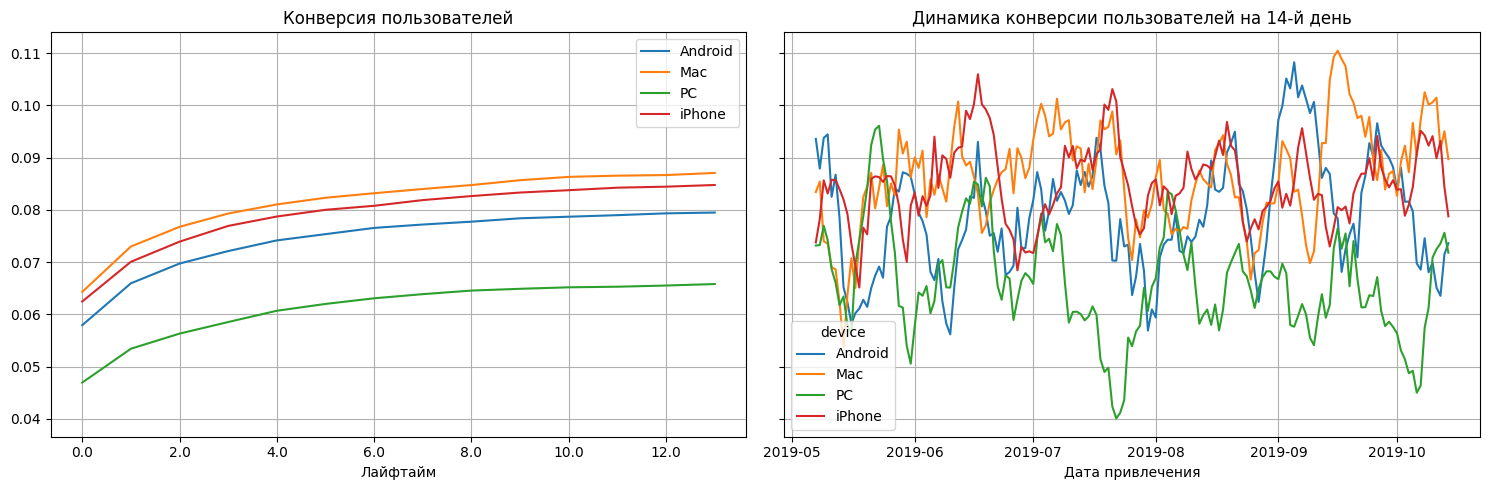

In [54]:
# вычислим конверсию в разрезе по устройствам
dimensions = ['device']

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions)

# построение графика конверсии и динамики изменения конверсии в разрезе по устройствам
plot_conversion(conversion_grouped, conversion_history, horizon_days)

Все устройства хорошо конверсируются, в лидерах устройства производства компании Apple, из общего потока немного выбиваются привлеченные пользователи платформы PC. Можем выдвинуть предположение, что мобильная версия приложения зарекомендовала себя лучше, чем сайт. Прокрастинация пользователей без привязи к компьютеру и без временных границ - что может быть лучше для владельцев приложения?

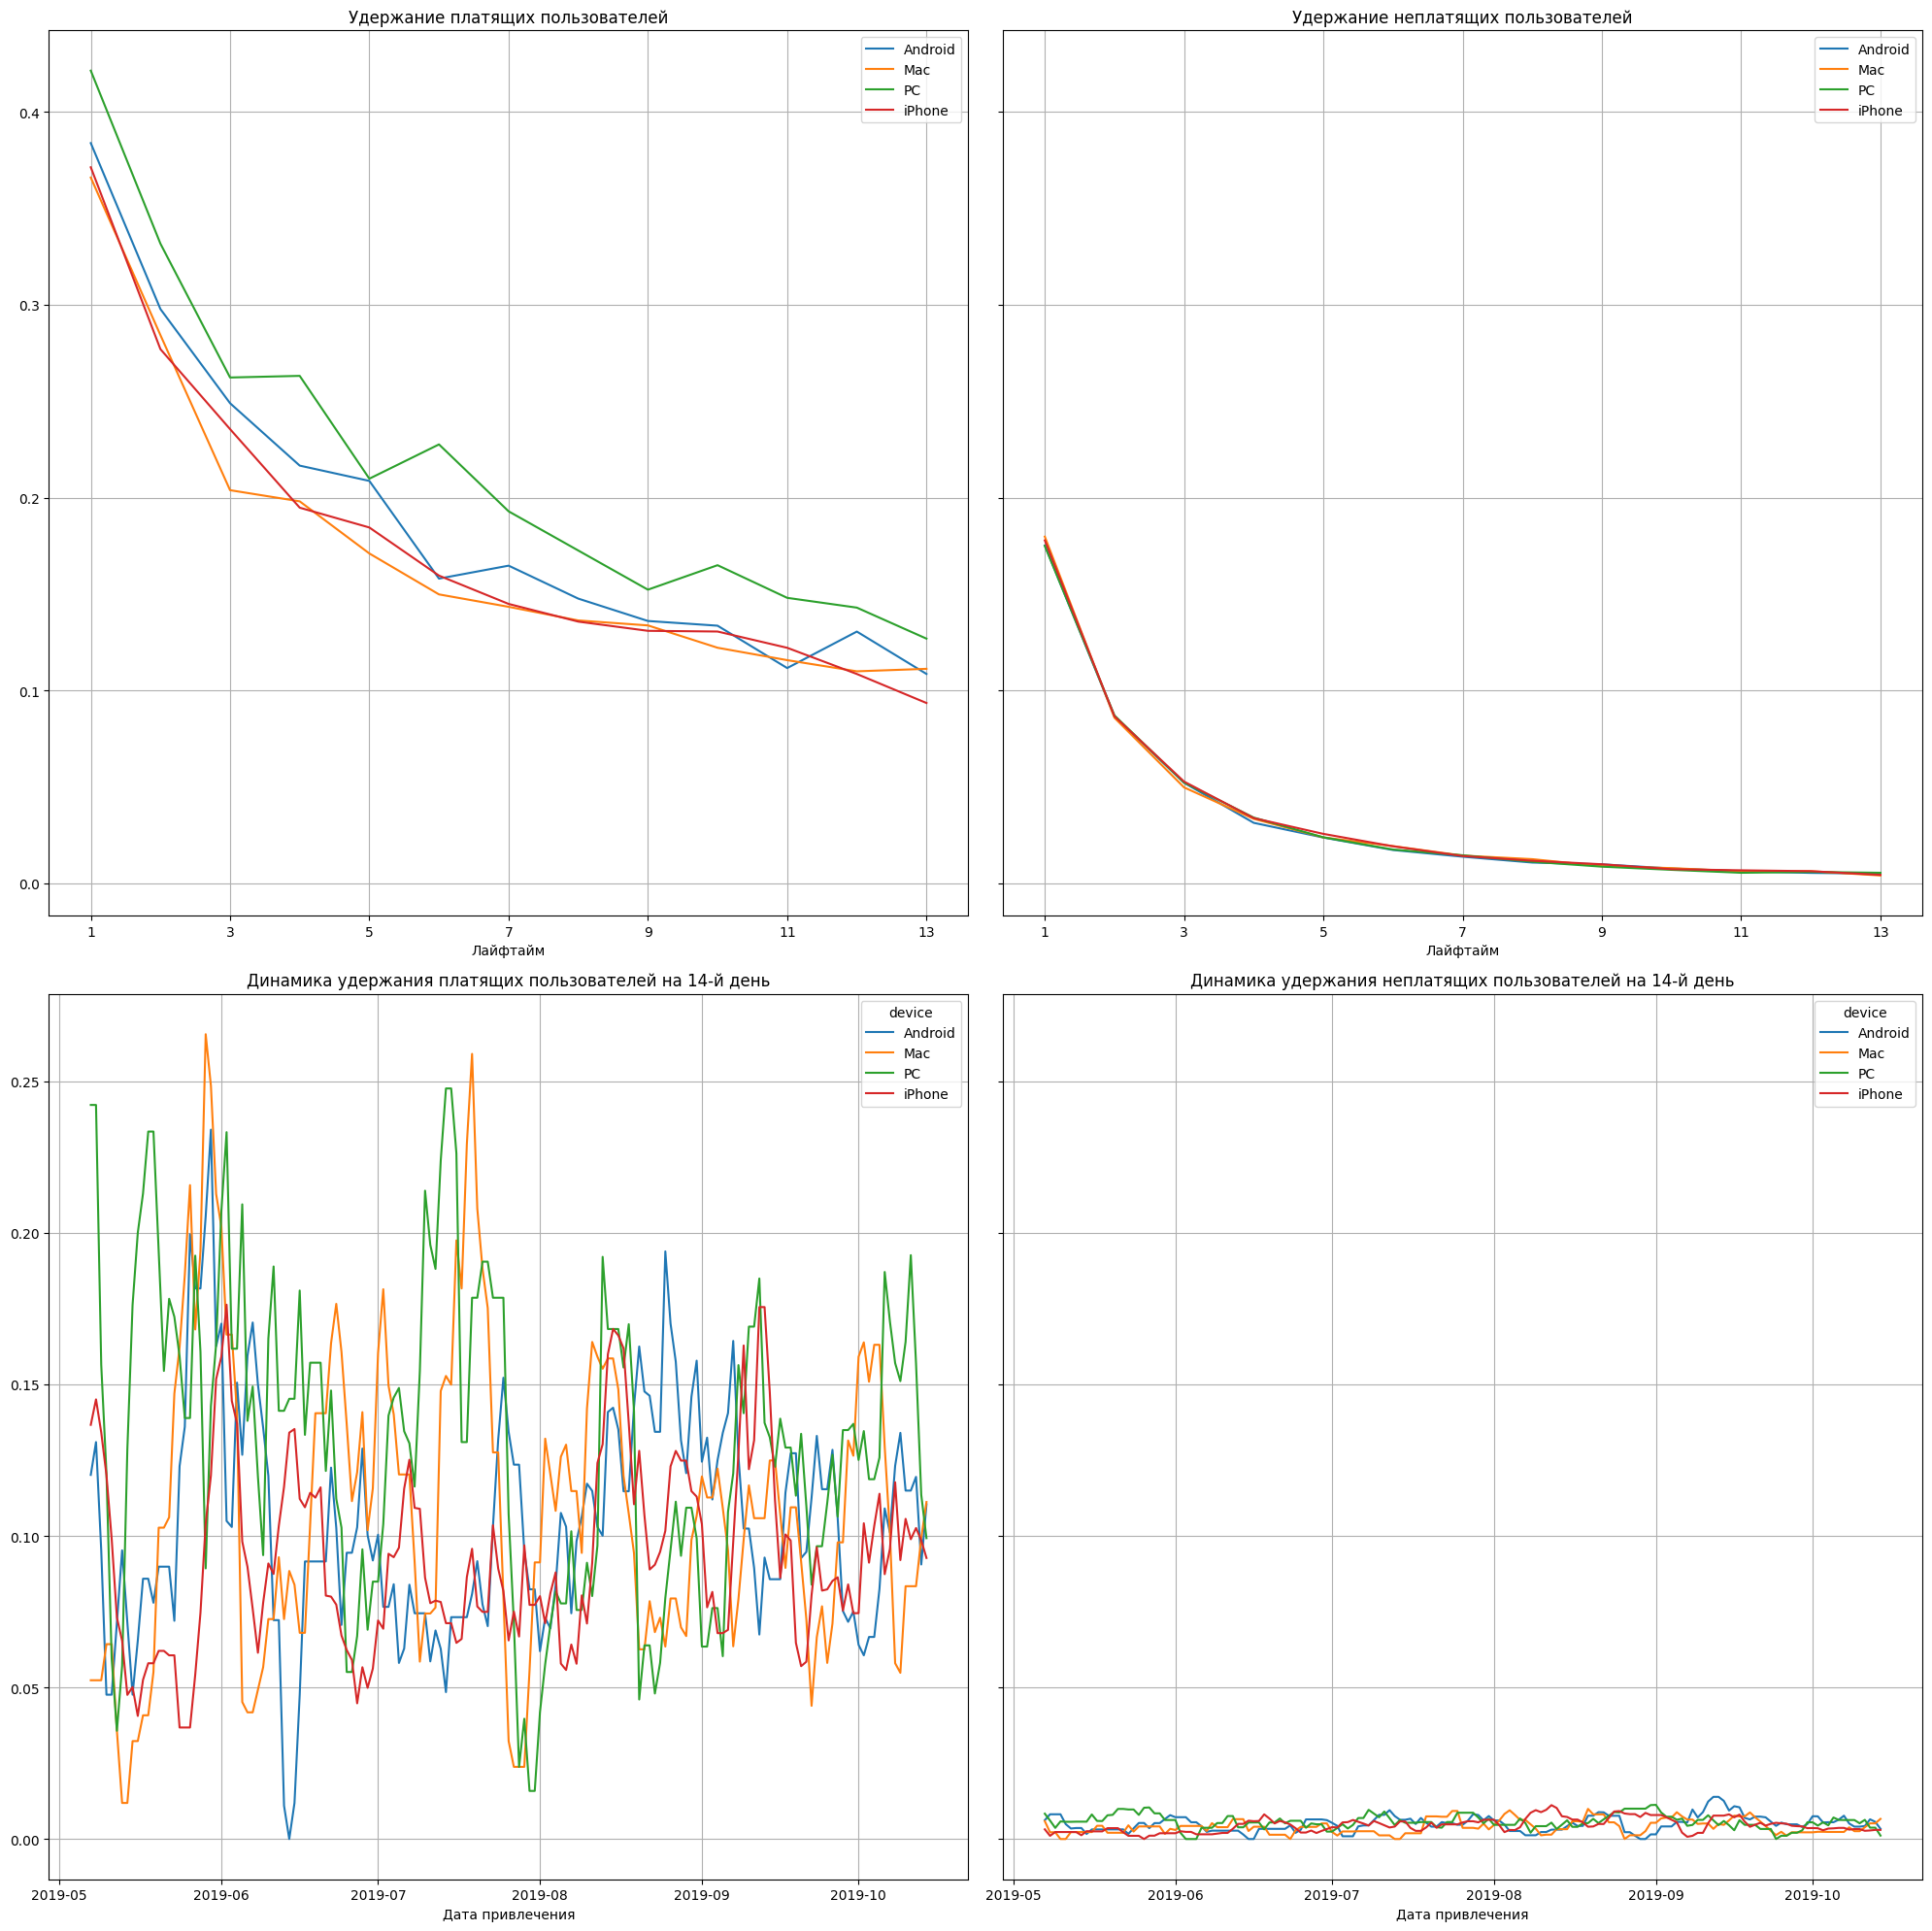

In [55]:
# вычислим удержание в разрезе по устройствам
dimensions = ['device']

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions)

# построение графика удержания и динамики изменения удержания в разрезе по устройствам
plot_retention(retention_grouped, retention_history, horizon_days)

Тип устройства пользователя не имеет принципиального значения. Пользователи, открывающие приложение с `PC`, удерживаются немного лучше всех остальных. Второе место по удержанию - за пользователями платформы `Android`, совсем плохо дела обстоят с использованием платформы `iPhone` и `Mac`. Здесь было бы полезным запросить дополнительные данные с логами взаимодействия пользователей с приложением на предмет выявления технических ошибок. Удержание платящих пользователей в равной степени хорошо идёт по платформам `PC` (что совпадает с общей тенденцией) и `Mac`. На графике динамики удержания неплатящих пользователей едва заметны - но они есть! - два пиковых значения. Так, в первой декаде августа 2019 года в приложение вернулось большое количество владельцев `iPhone`, а ближе к середине сентября 2019 года этот условный рекорд по возврату побили пользователи с платформой `Android`. Мы можем предположить, что вышли обновления приложения (функционал, дизайн, устранение неполадок, уменьшение веса приложения), которые вместе с обновлением (ручным или тихим), могли побудить пользователя вновь открыть приложение.

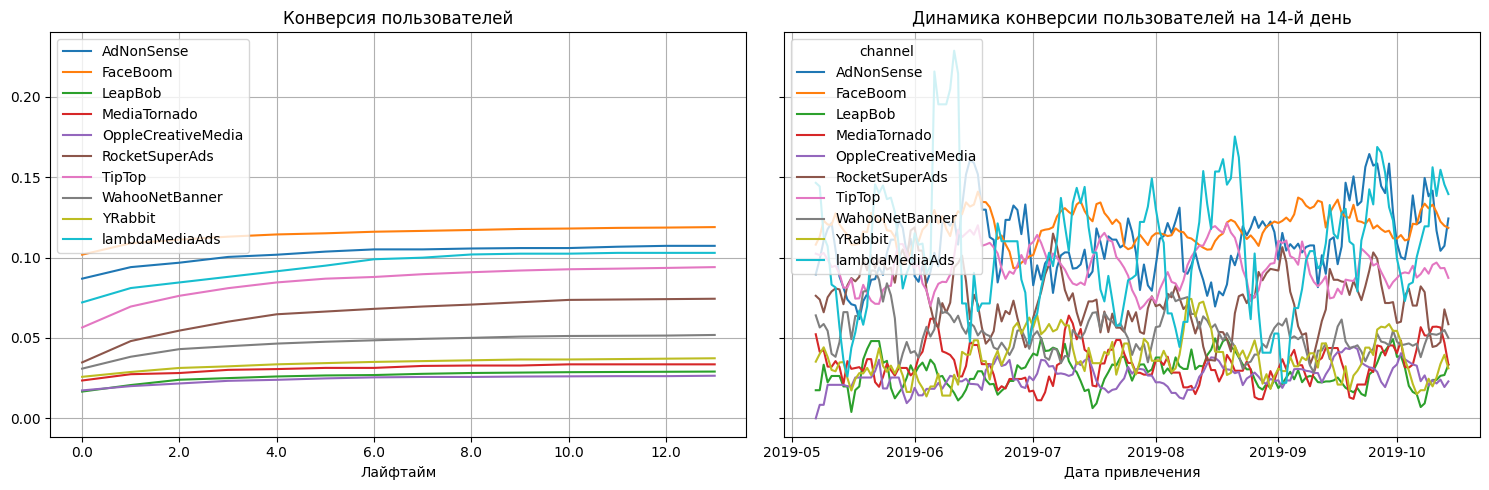

In [56]:
# вычислим конверсию в разрезе источников рекламы
dimensions = ['channel']

conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions)

# построение графика конверсии и динамики изменения конверсии в разрезе источников рекламы
plot_conversion(conversion_grouped, conversion_history, horizon_days)

В общем и целом, динамики по всем источникам рекламы в течение двухнедельного лайфтайма практически нет. При этом, выше всего конверсия у пользователей, привлечённых посредством `FaceBoom`. Тройку лидеров замыкают `AdNonSense` и `lambdaMediaAds`. Хуже всего с конверсией обстоят дела по `OppleCreativeMedia` и креативные идеи не попадают в реальные или навязанные потребности пользователей.

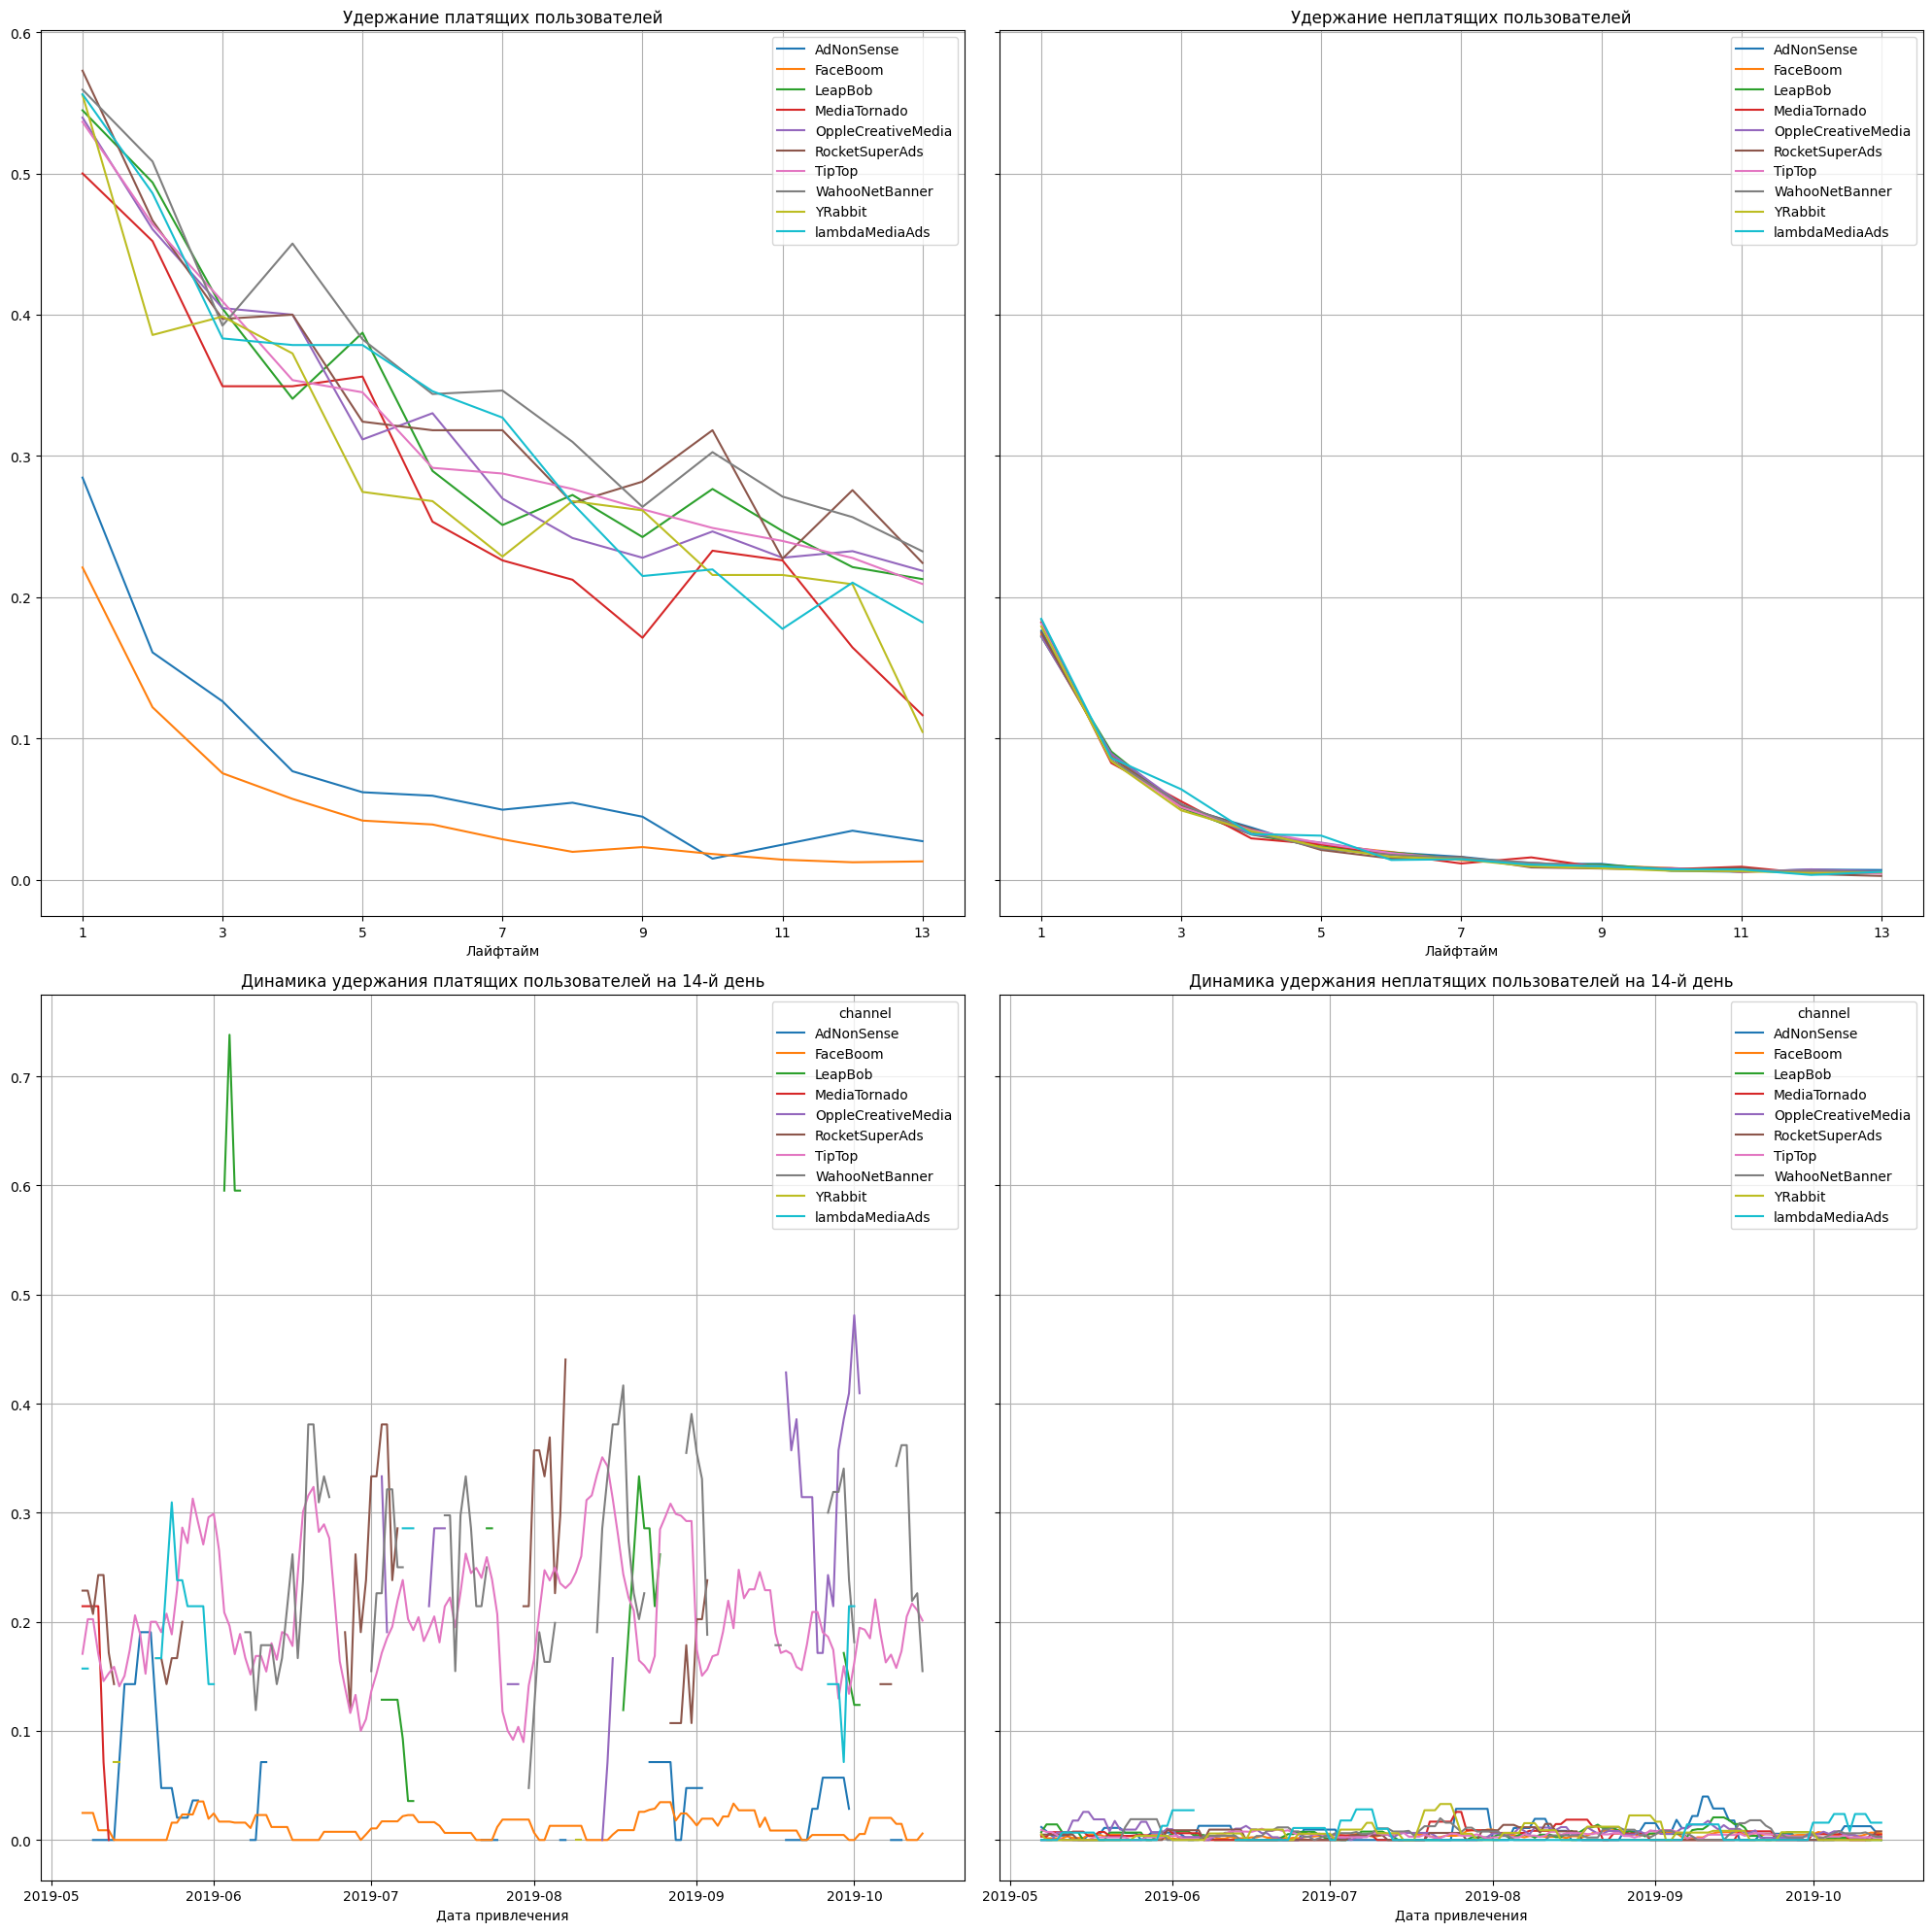

In [57]:
# вычислим удержание в разрезе источников рекламы
dimensions = ['channel']

retention_raw, retention_grouped, retention_history = get_retention(
    profiles, visits, observation_date, horizon_days, dimensions=dimensions)

# построение графика удержания и динамики изменения удержания в разрезе источников рекламы
plot_retention(retention_grouped, retention_history, horizon_days)

Удержание платящих и неплатящих пользователей идёт ощутимыми "рывками" и об этом явно свидетельствуют соответствующие графики динамики этой метрики. Полагаем, это может быть следствием проведения рекламных кампаний.

Из платящих пользователей лучше всего удерживаются пришедшие по рекламным каналам из `WahooNetBanner` и `RocketSuperAds`. Тройку лидеров замыкает `OppleCreativeMedia` (с учётом низкой конверсии по этому каналу получается, что пользователей из этого рекламного источника мало, но они регулярно возвращаются за покупками, такая устойчивая приверженность прокрастинации). Хуже всего из платящих удерживаются пользователи из `AdNonSense`. По удержанию платящих пользователей полагаем необходимым отметить ещё один факт: вследствие существенных вливаний в рекламу на канах `TipTop` и `AdNonSense` удержание платящих пользователей происходит **на низком уровне, но стабильно.** И это главная отличительная черта удержания платящих пользователей по этим источникам рекламы.

В динамике неплатящих пользователей мы тоже можем выделить опережающих и отстающих. Канал рекламы `AdNonSense` дважды достиг и дважды удерживал на протяжении 7-10 дней большое количество посетителей. Его успех также дважды повторил канал `YRabbit`, но с чуть меньшим показателями. Канал `lambdaMediaAds` показывает на графике 4 пиковых значения в начале июня, в первой половине июля, в середине сентября и в течение двух недель октября 2019 года.

Вообще, чем дальше изучаем положение дел с инвестициями в рекламу приложения Procrastinate Pro+, тем больше складывается ощущение, что как таковой рекламной стратегии продвижения приложения не существует вовсе или она с большим трудом переносится с бумаги в жизнь, и на практике ввиду разных факторов (нет своих или нанятых квалифицированных специалистов, нет ресурса времени на отслеживание метрик) происходит экстренное и хаотичное латание дыр и провисов по посещаемости, конверсии, удержанию и материальной прибыли. 

<a id=5.3.></a>
### 5.3. Окупаемость рекламы в разрезе устройств. Графики LTV и ROI, графики динамики LTV, CAC и ROI

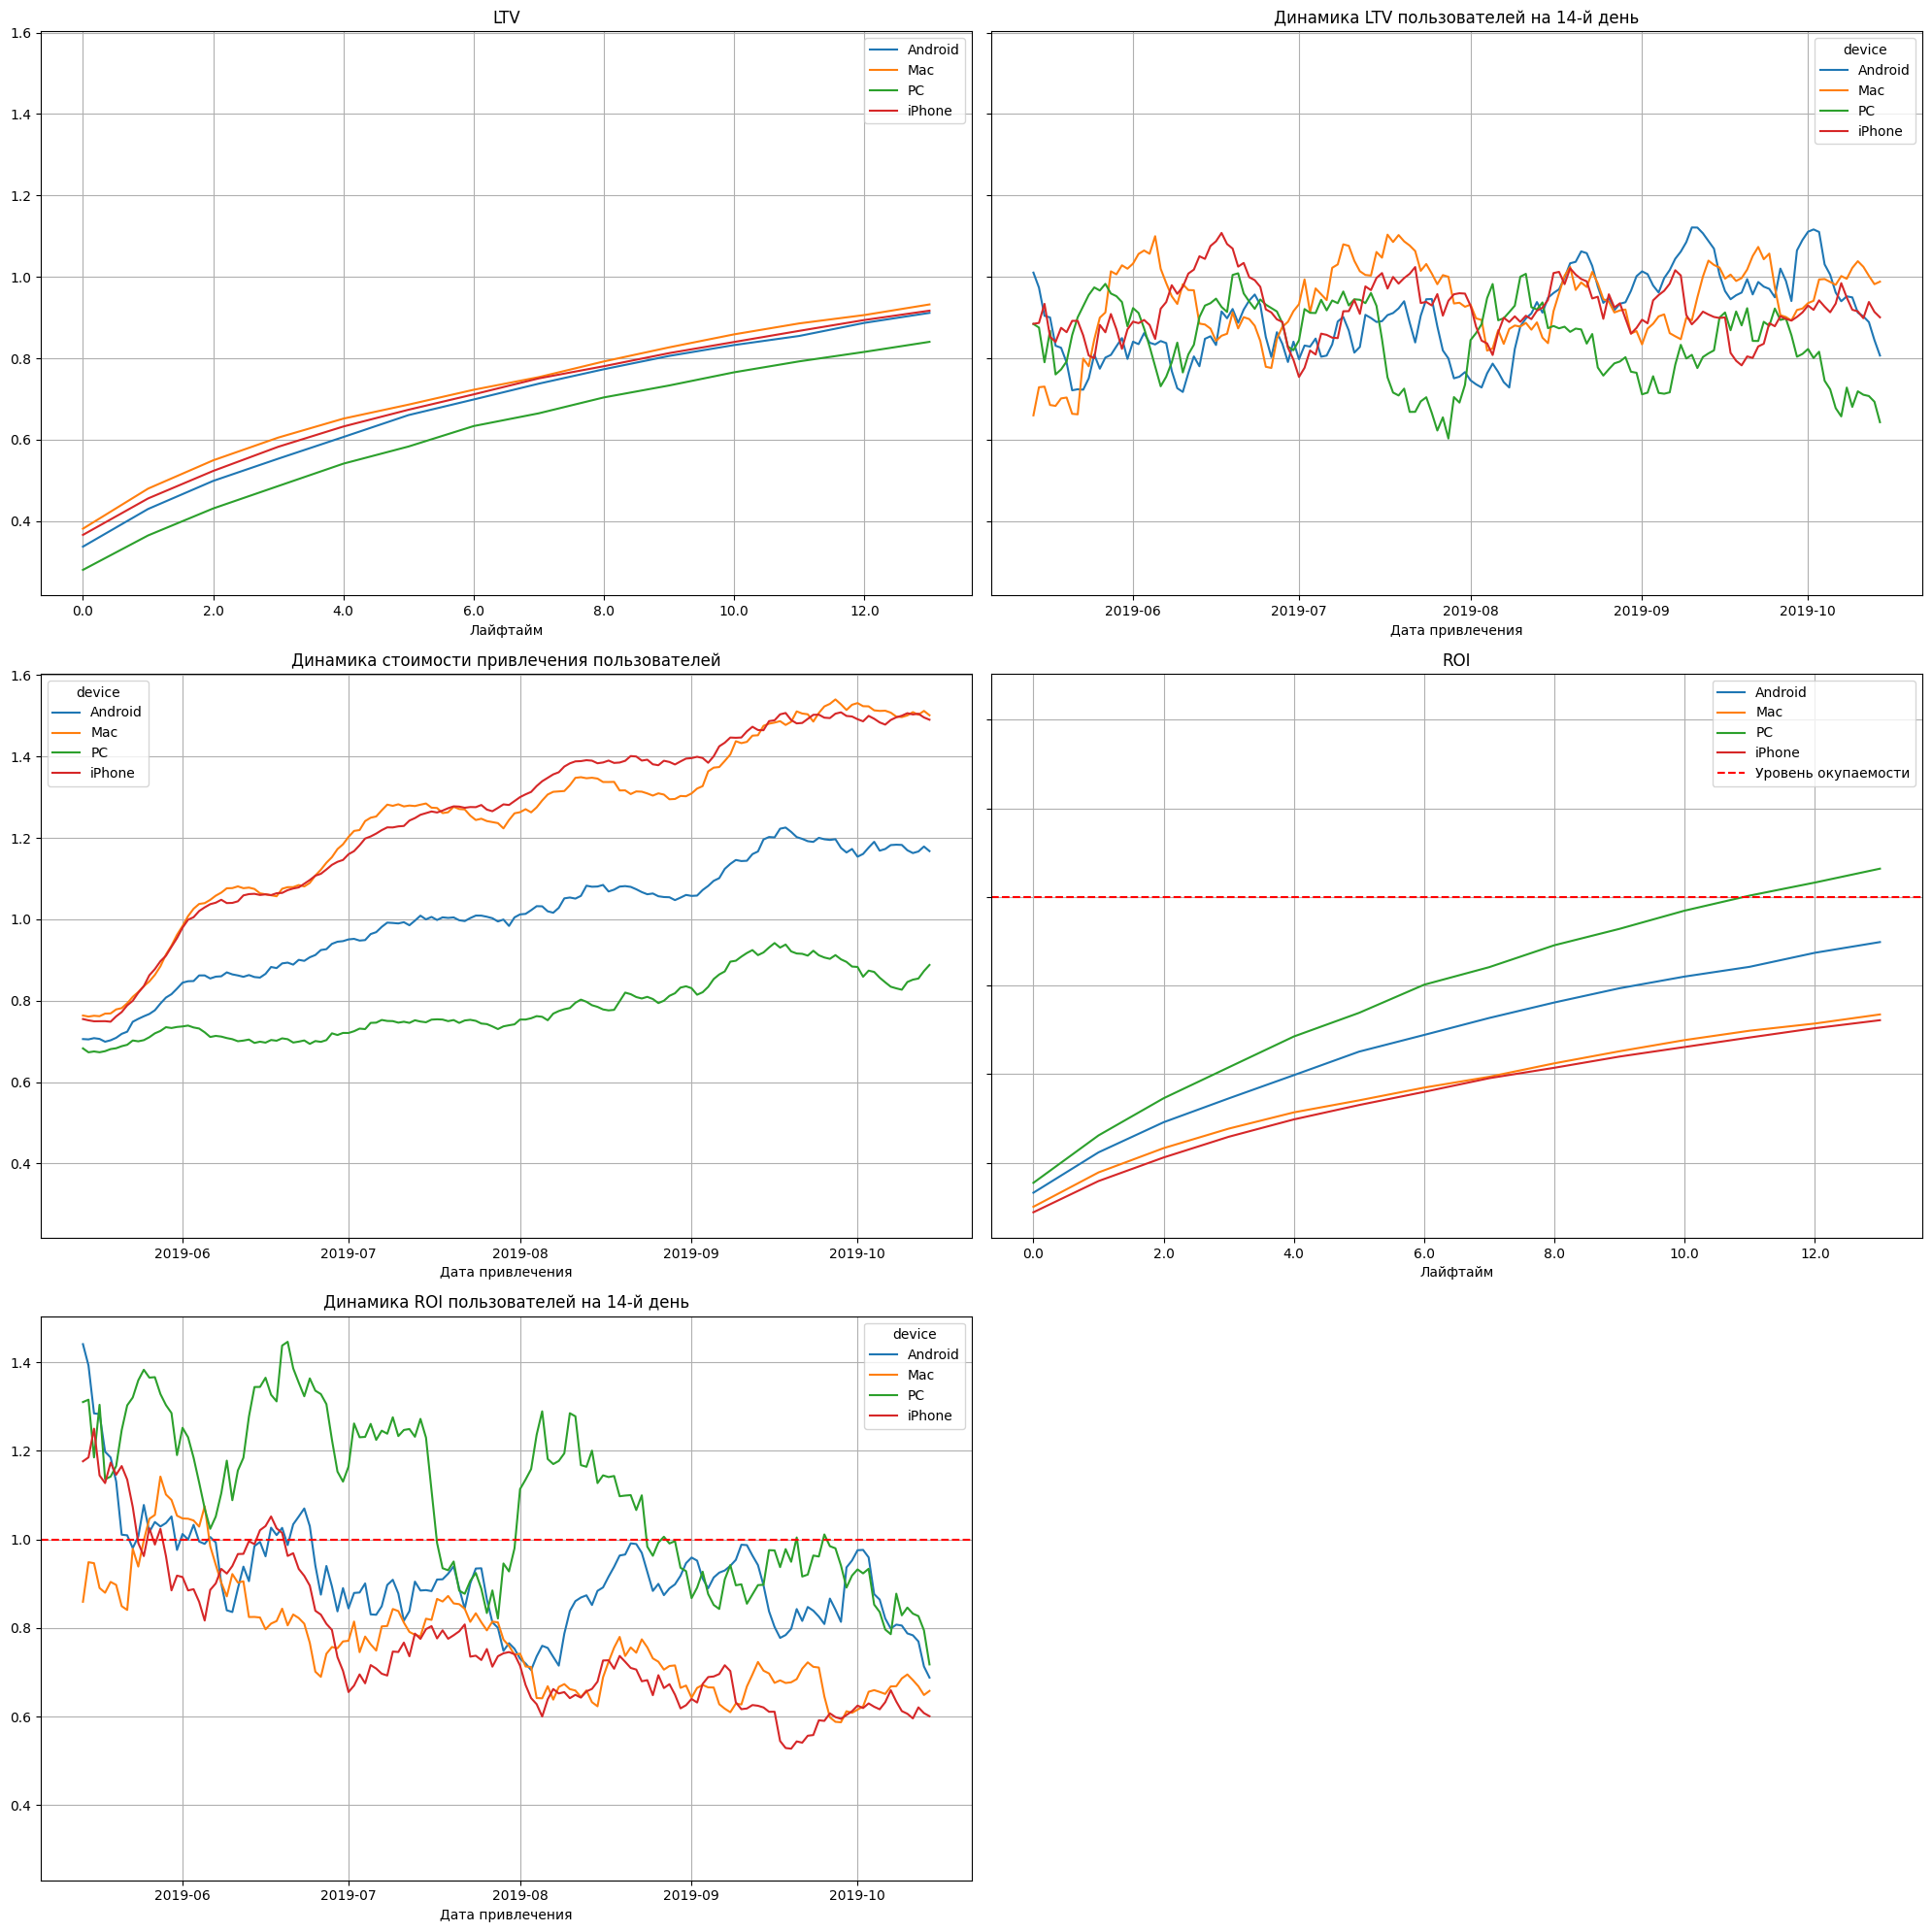

In [58]:
# задаём дополнительный признак группировки в разрезе устройств
dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions)

plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14)

**Вывод:** самыми дорогостоящими по привлечению (CAC) являются пользователи `Mac` и `iPhone`, дешевле всего - пользователи `PC`. Хорошую динамику LVT показывают пользователи `Android` и `Mac`. Также положительная динамика окупаемости вложений ROI за двухнедельный лайфтайм - за платформой `PC`. Только половина денежных средств, вложенных в рекламу для платформ `Mac` и `iPhone` возвращаются через покупки.

<a id=5.4.></a>
### 5.4. Окупаемость рекламы в разрезе стран. Графики LTV и ROI, графики динамики LTV, CAC и ROI

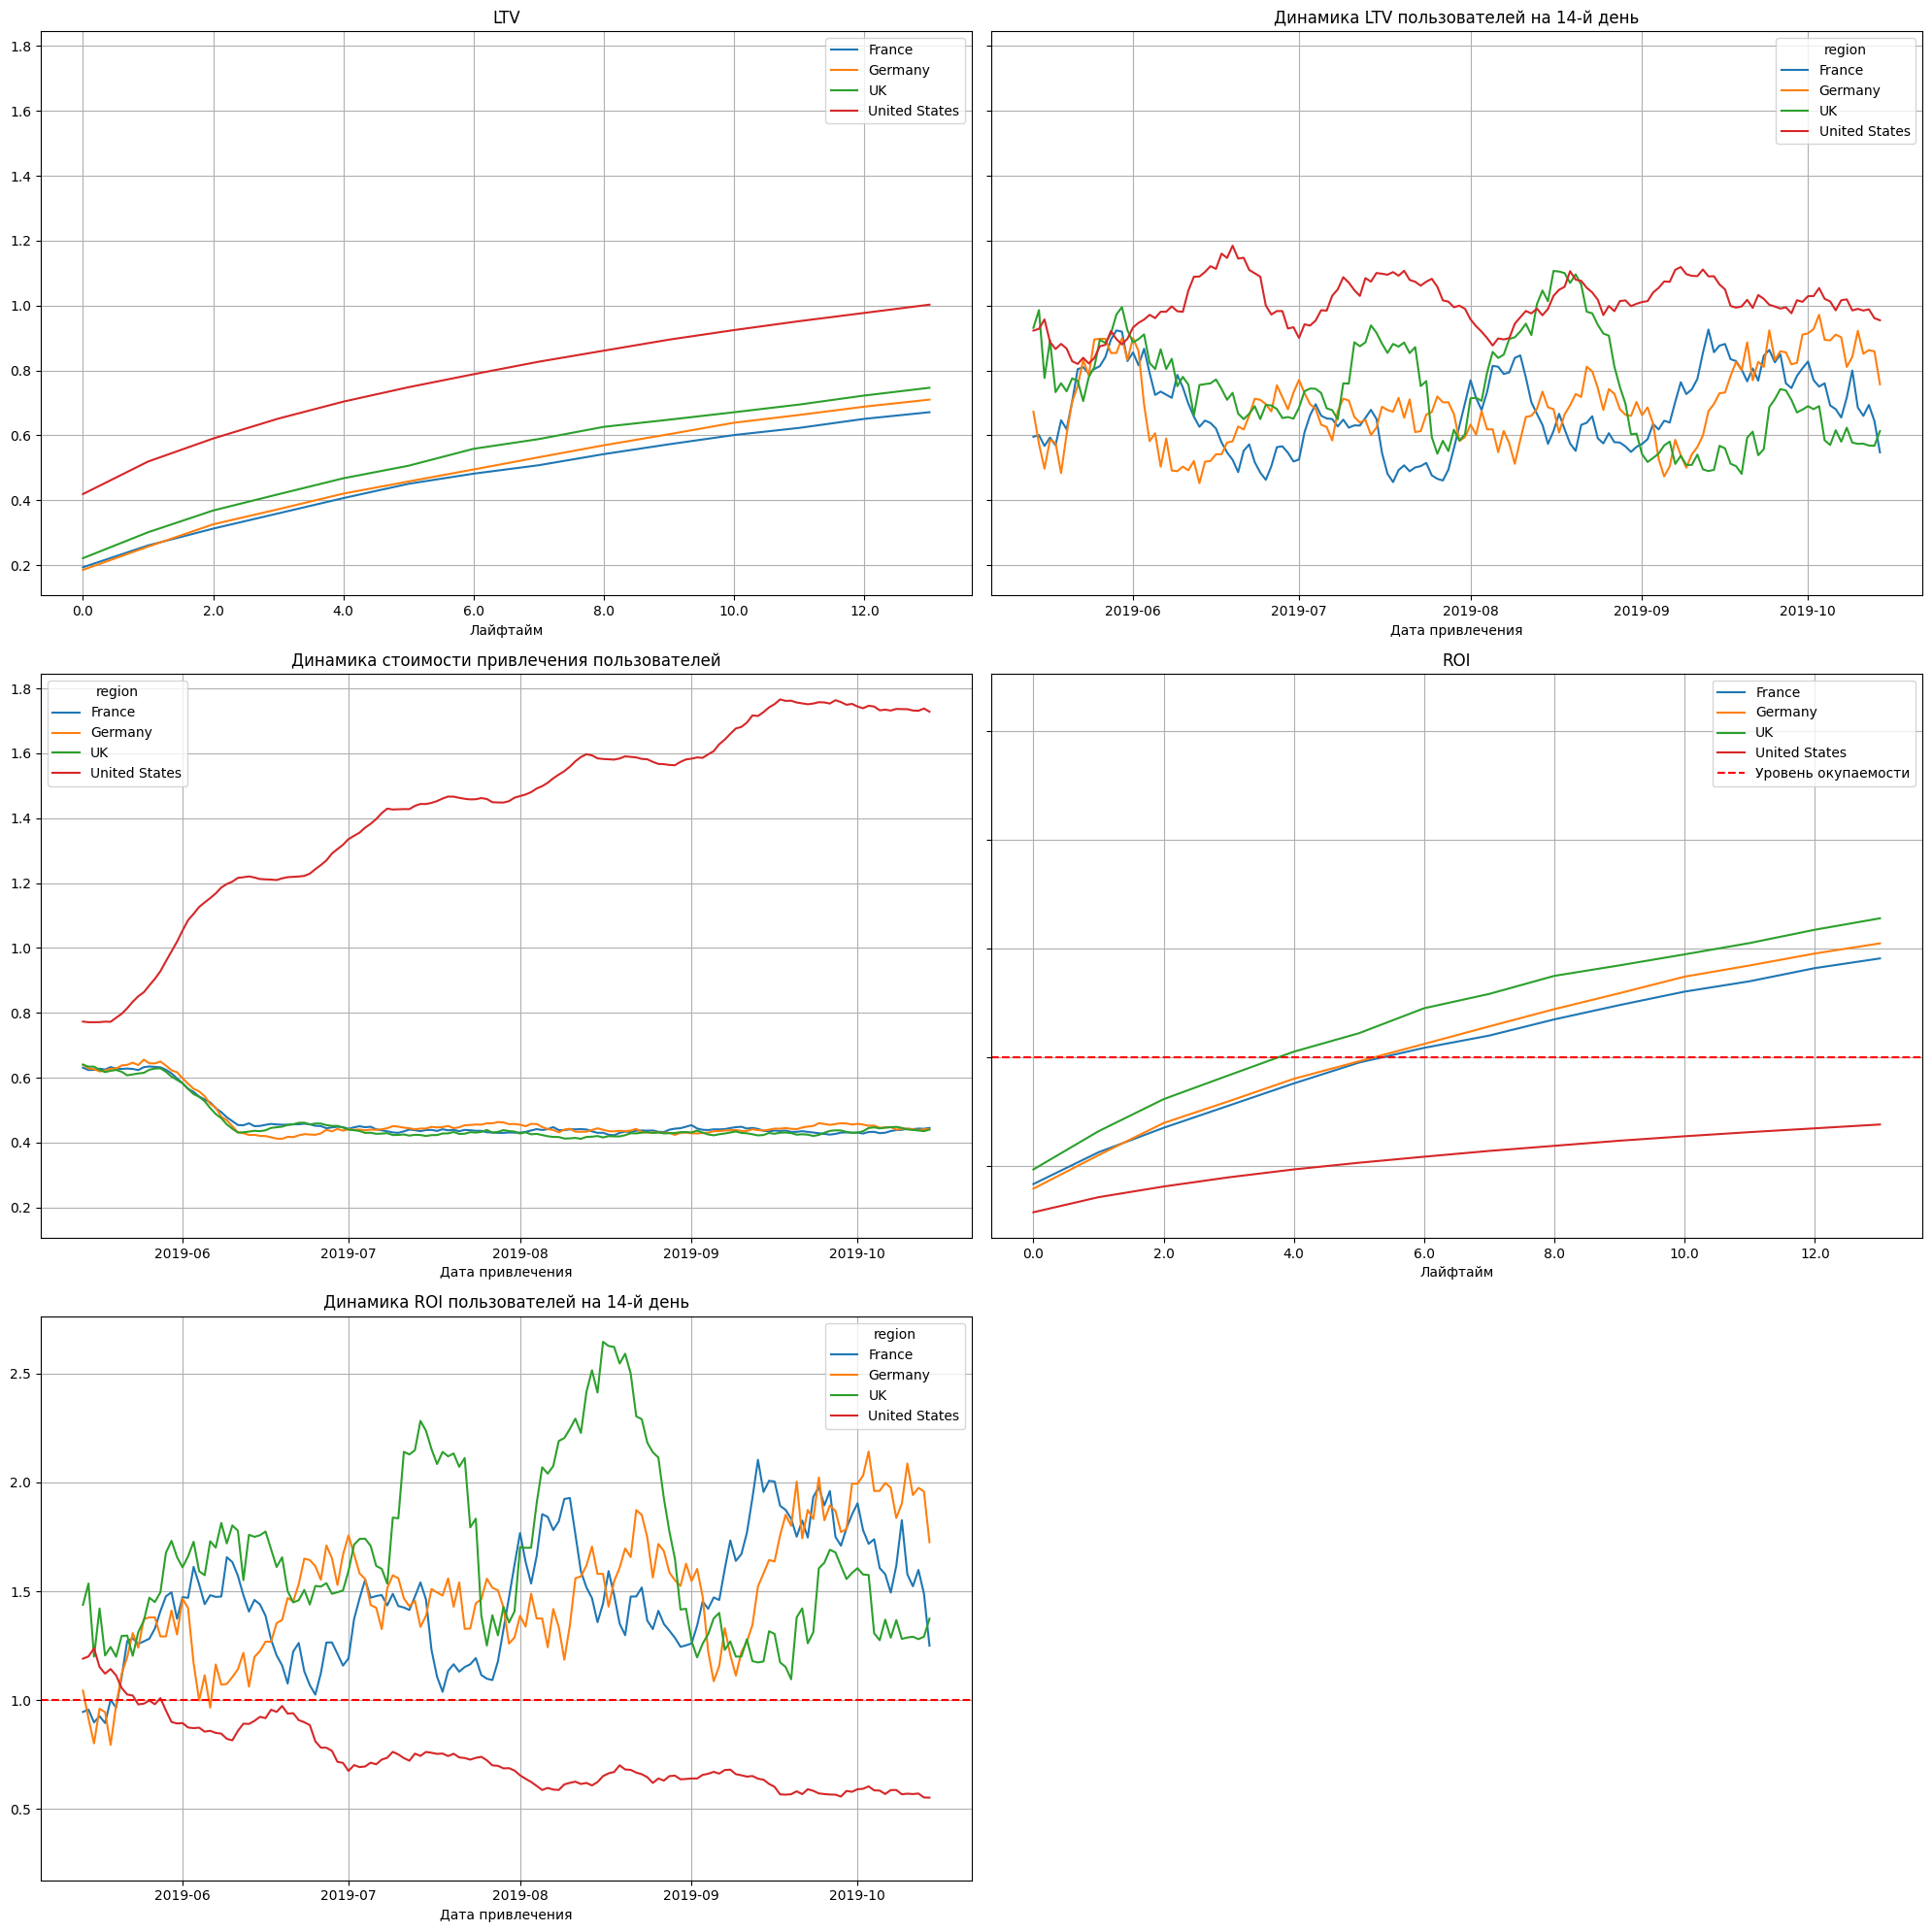

In [59]:
# задаём дополнительный признак группировки в разрезе стран
dimensions = ['region']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions)

plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14)

**Выводы:** несмотря на очень большое количество привлеченных пользователей из США, удержания этих клиентов не происходит. Затраты на рекламу в Европе остаются неизменными и окупаются, а в США растут и перестали окупаться с июня (предполагаем, по причине активного финансирования рекламного источника `TipTop`).

<a id=5.5.></a>
### 5.5. Окупаемость рекламы с разбивкой по рекламным каналам. Графики LTV и ROI, графики динамики LTV, CAC и ROI

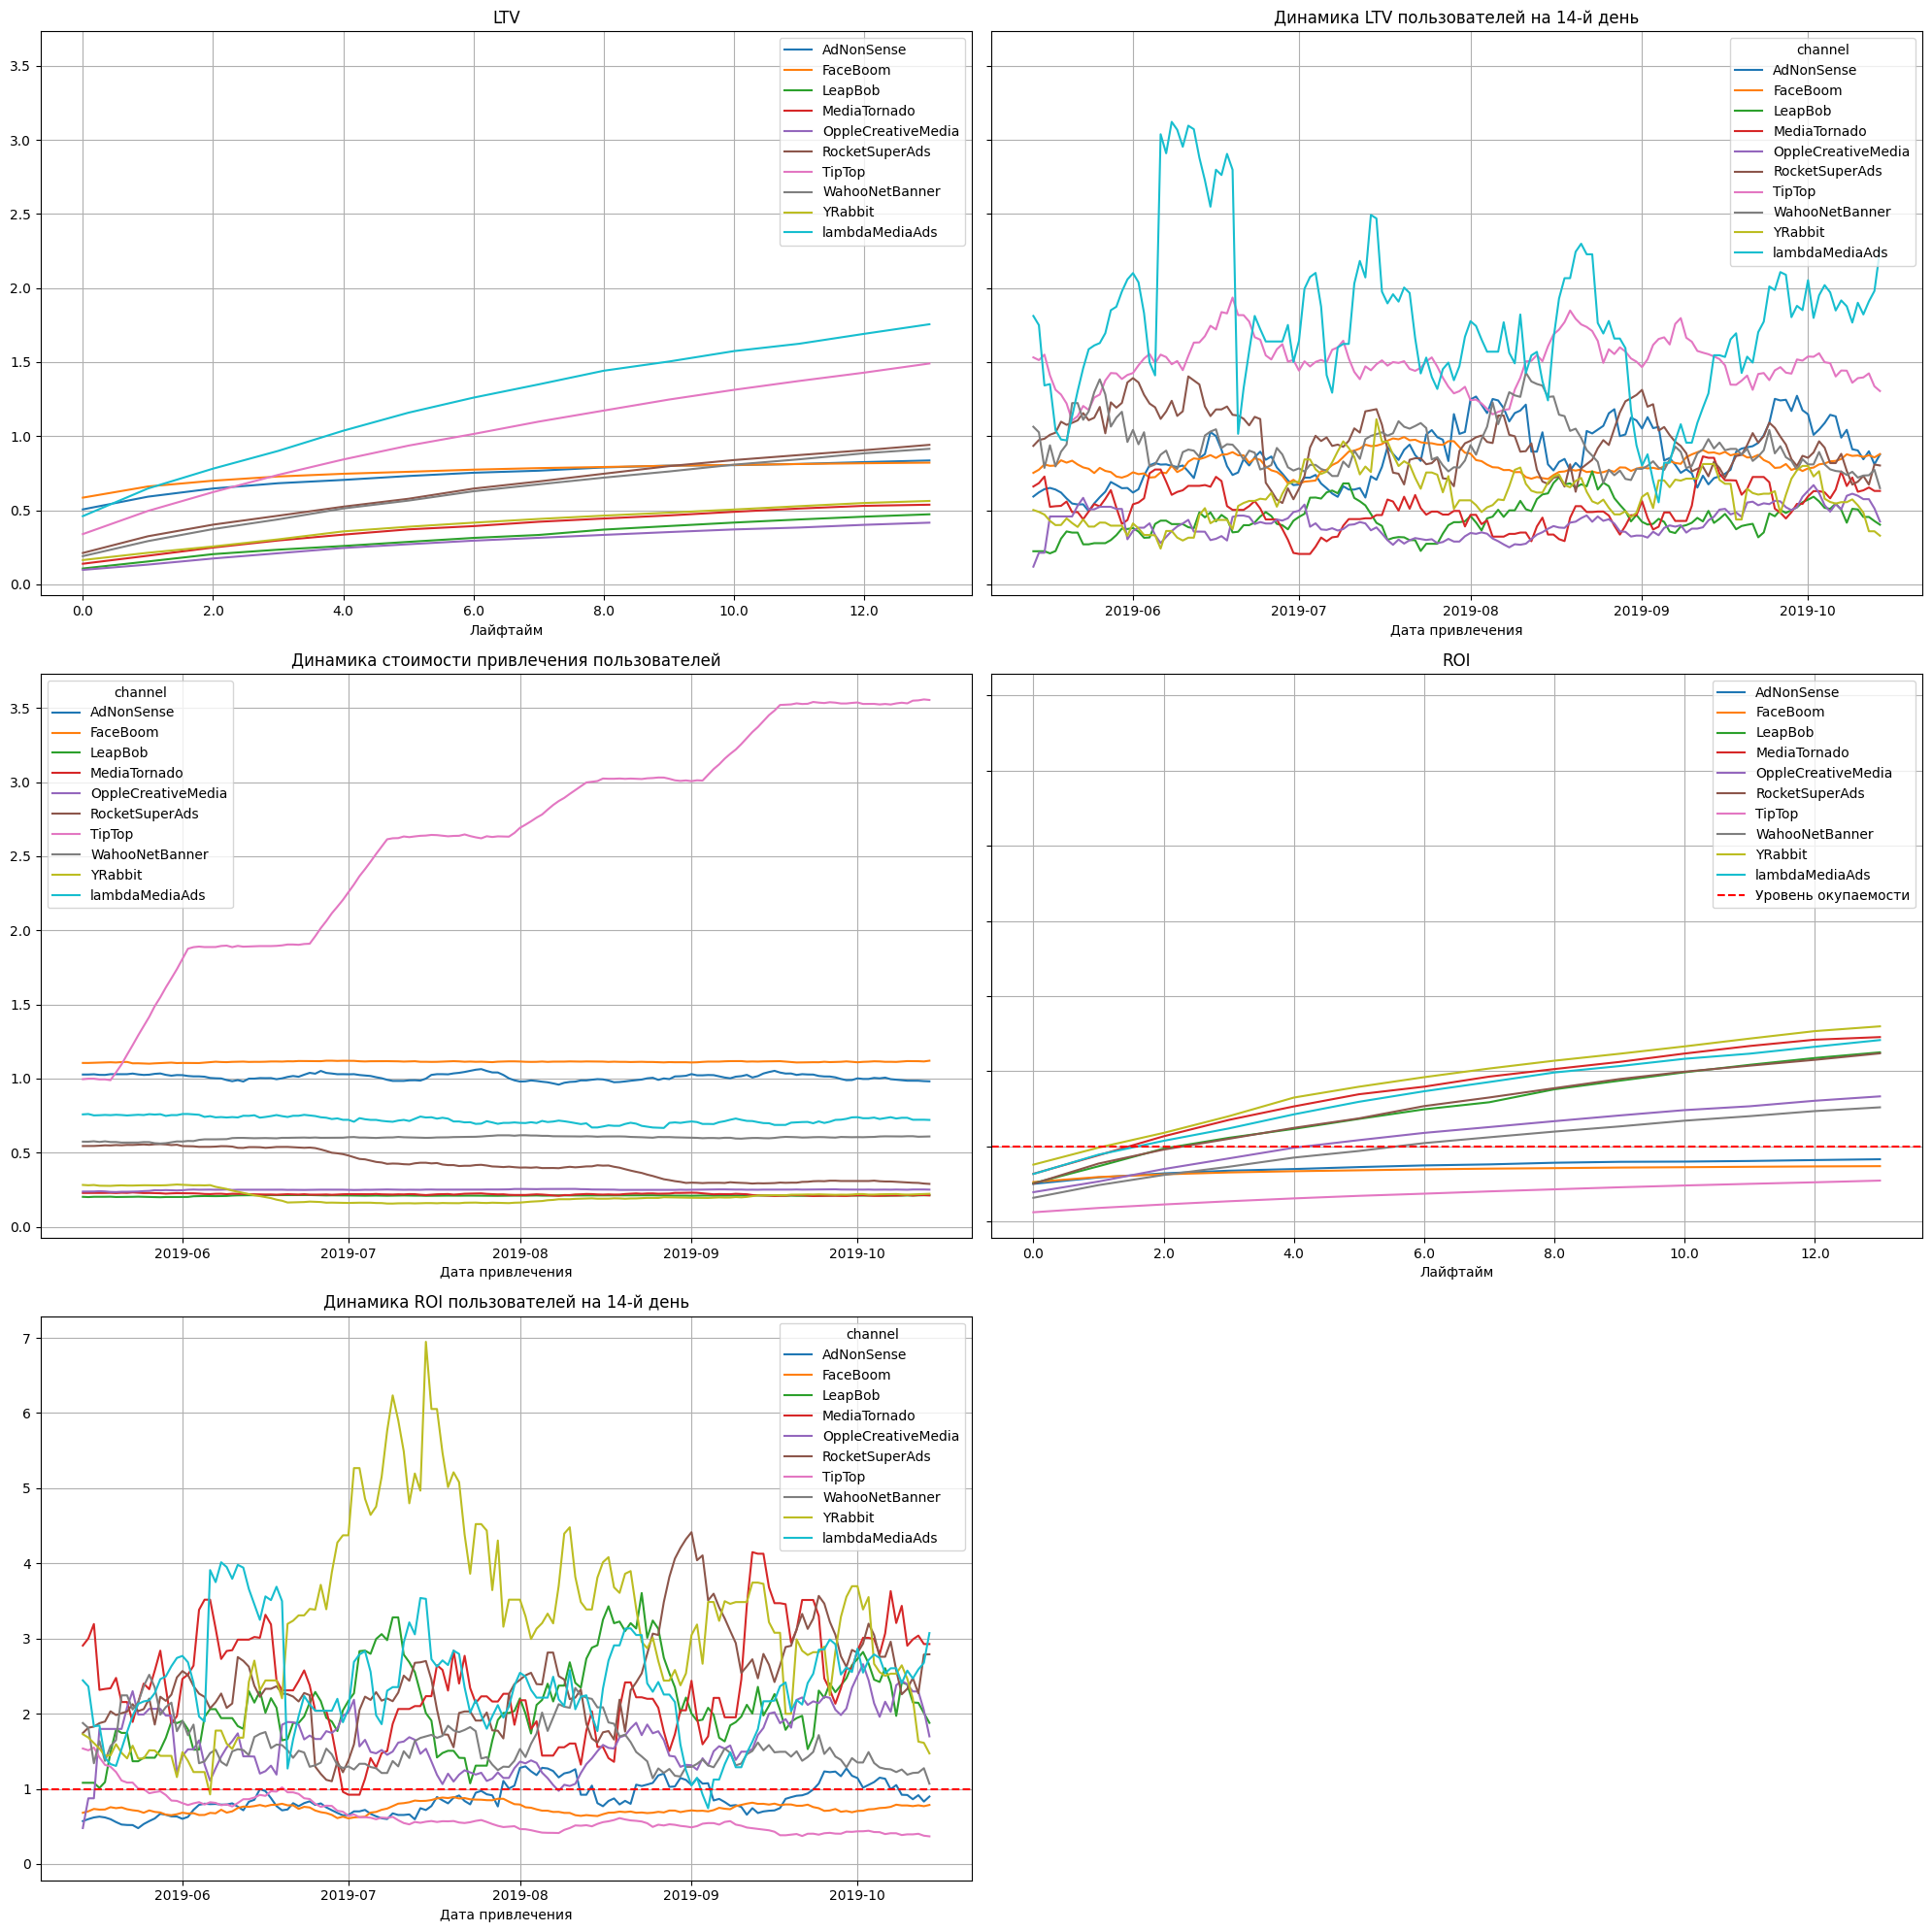

In [60]:
# задаём дополнительный признак группировки в разрезе источников рекламы
dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles, orders, observation_date, horizon_days, dimensions=dimensions)

plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14)

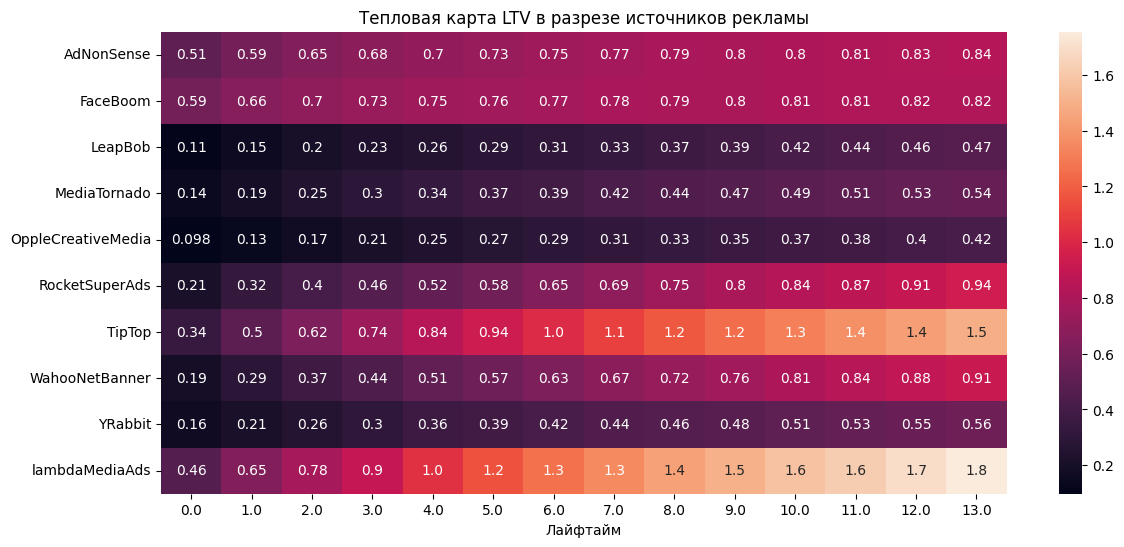

In [61]:
# heatmap LTV
plt.figure(figsize=(30, 6))
sns.heatmap(ltv_grouped.drop(columns = ['cohort_size']), annot=True, fmt='.2', ax=plt.subplot(1, 2, 2))
plt.title('Тепловая карта LTV в разрезе источников рекламы')
plt.xlabel('Лайфтайм')
plt.ylabel('')
plt.show()

На этом графике отражены расходы на рекламу за лайфтайм в 14 дней. 

* вложения в первую тройку компаний, на которые тратится практически весь рекламный бюджет, не окупаются;
* затраты на рекламу в `TipTop` увеличиваются каждый месяц,
* перспективным каналом кажется `lambdaMediaAds` - низкая стоимость привлечения (0,72) и высокие показатели LVT (пожизненной ценности клиента).

Чтобы сформировать более детальную картину происходящего, мы можем построить график по топ-3 САС (стоимость привлечения клиента) в разрезе источников рекламы.

,CAC
channel,
TipTop,2.799003
FaceBoom,1.113286
AdNonSense,1.008054


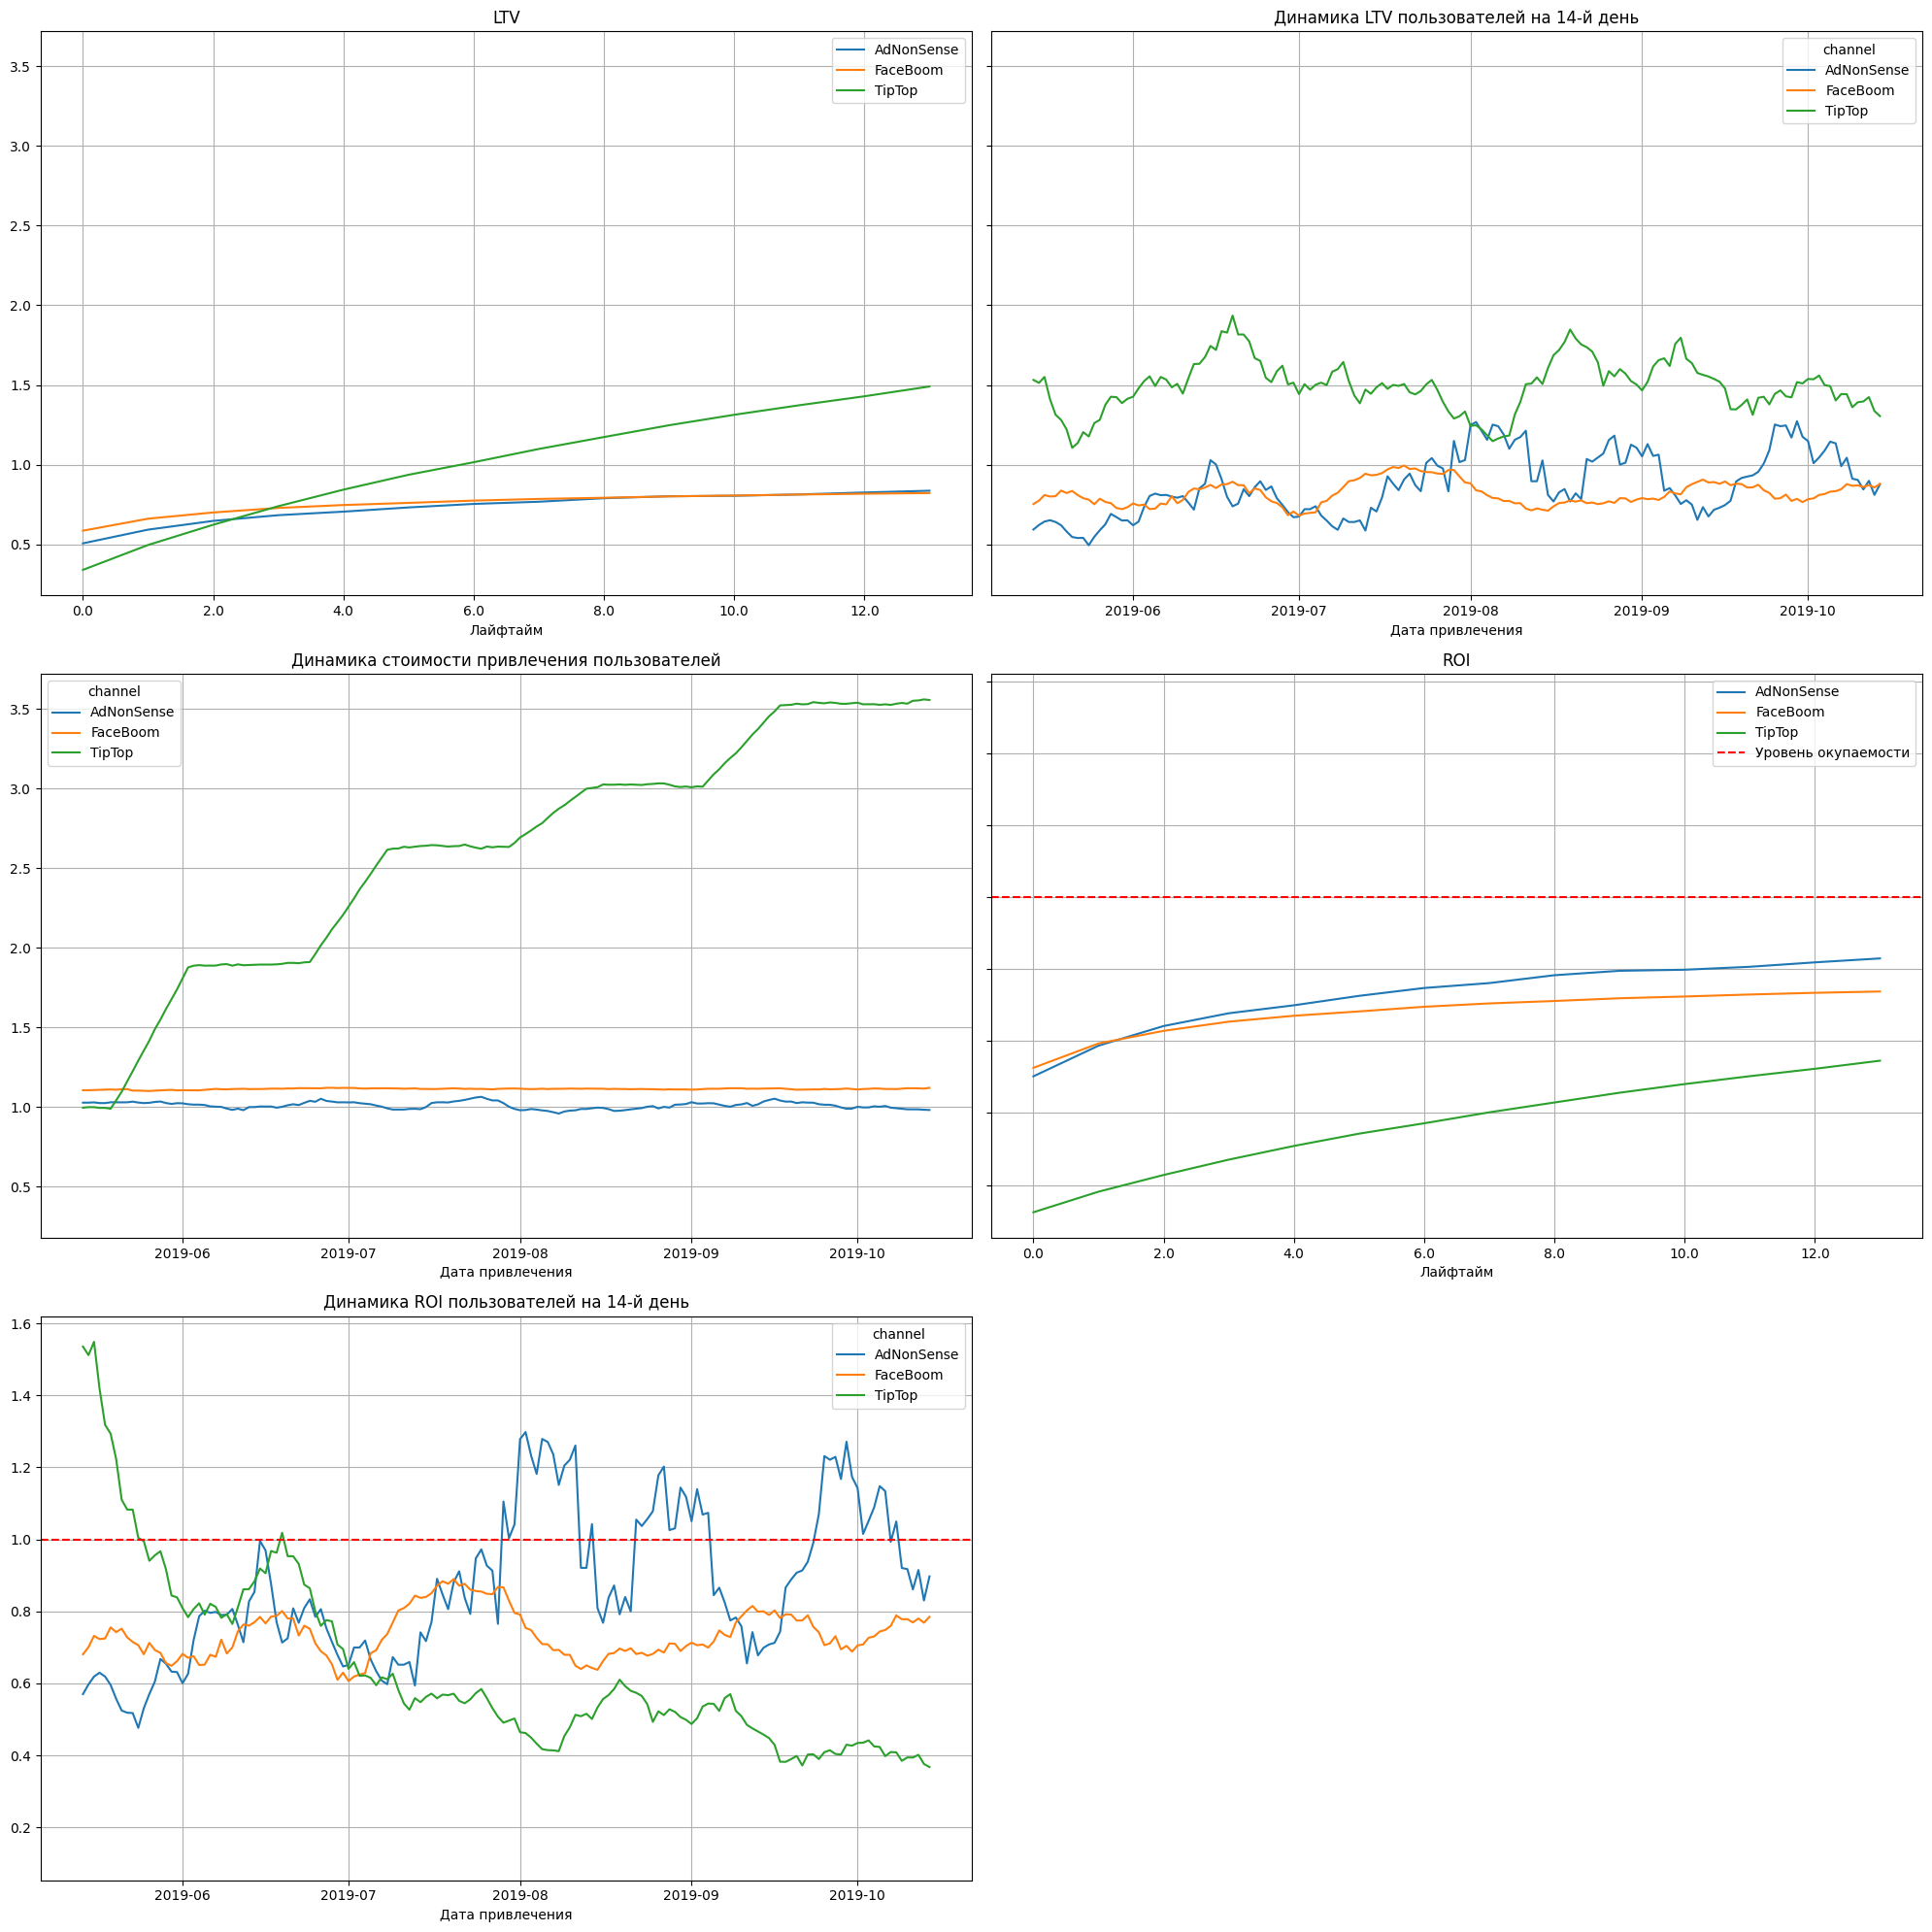

In [62]:
# для справки выведем топ-3 лидеров по средней стоимости привлечения клиента
display(mean_cac_per_channel.head(3))

# считаем LTV и ROI, дополнительный признак - источник рекламы
dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles.query('channel == ["TipTop", "FaceBoom", "AdNonSense"]'), orders, observation_date, horizon_days, dimensions=dimensions)

plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history,  horizon_days, window=14)

Судя по графикам выше, на звёздном небе достижений приложения Procrastinate Pro+ существуют три чёрные дыры, которые с чудовищной интенсивностью поглощают рекламный бюджет без намёка на окупаемость. С периодической успешностью источник рекламы `AdNonSense` показывает незначительные хорошие результаты, а ситуация, сложившаяся с финансированием рекламы на популярном источнике `TipTop` напоминает известную поговорку индейского племени Дакота: «Лошадь сдохла — слезь». В июне 2019 года `TipTop` набирал обороты и набирал себе новую аудиторию в весьма интенсивной и даже агрессивной форме. Можно предположить, что создатели приложения Procrastinate Pro+ зацепились за идею стать вовлечёнными в этот мощный процесс только за счёт присутствия на этой площадке, однако, они могли, например, не учесть вкусы и интересы аудитории, попасть мимо интересных форматов активности (дуэты, реакции, челленджи). Одновременно с этим, развивающаяся площадка `TipTop` в силу феноменального роста своего могущества и охвата начала диктовать жёсткие условия и повышать рекламную ставку. Судя по всему, на графике мы как раз наблюдаем этот процесс: ценник на рекламу на `TipTop` за второе полугодие 2019 года повышался 4 раза. Также, у нас есть предположение о взаимосвязи источника рекламы и страны, в которой этот источник рекламы представлен. Мы можем подтвердить или опровергнуть это предположение с помощью расчётов:

In [63]:
# доля представленности рекламного источника в разрезе страны
(profiles.pivot_table(index='channel', columns='region', aggfunc={'user_id': 'count'}).\
sort_values(by=('user_id', 'United States'), ascending=False)).\
div(profiles.pivot_table(columns='region', aggfunc={'user_id': 'count'}).values).\
fillna(0).style.format('{:.2%}')

**Выводы:** полученные данные наглядно свидетельствуют о региональной представленности того или иного рекламного источника. Здесь мы можем обратить внимание не только на региональный контекст, но и на своего рода антагонистическую полярность: европейские источники рекламы против американских. Эта полярность и отсутствие рекламы приложения в региональных сегментах популярных рекламных каналов может стать потенциальной точкой роста.

<a id=5.6.></a>
### 5.6. Анализ окупаемости рекламы

<a id=5.6.1.></a>
#### 5.6.1. Окупается ли реклама, направленная на привлечение пользователей в целом?

В общем и целом платная реклама, направленная на привлечение пользователей, не окупается. Однако, если учитывать органический трафик, который не требует затрат, общий ROI вплотную приближается к точке безубыточности. Это говорит о сильном продукте, который пользователи находят сами, но о крайне неэффективном медиапланировании в платных каналах.

<a id=5.6.2.></a>
#### 5.6.2. Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы?

Определённо, негативное влияние на итоговый результат инвестиций в рекламу приложения Procrastinate Pro+, оказывает ситуация с  низкой окупаемостью рекламы в США, как в основной стране присутствия. На основании полученных данных о региональной представленности источников рекламы, негативное влияние оказывают рекламные каналы, действующие на территории США: `FaceBoom`, `TipTop`, на которые приходится более 80% консолидированного рекламного бюджета. У рекламного канала `FaceBoom` низкое удержание платящих пользователей, у растущего канала `TipTop` растущие аппетиты в отношении ценовой политики размещения рекламы и, как следствие, четырёхразовое увеличение стоимости рекламы с вытекающим из этого увеличением САС клиента по этому каналу, что привело к отрицательной динамике окупаемости. Проблемный тандем устройств от производителя Apple `Mac` и `iPhone` показывает самые низкие показатели ROI, но: 1) этот показатель начал падать только с июня 2019 года и 2) обладатели Apple устройств - самые многочисленные.

Таким образом, мы медленно и верно приходим к выводу, что <font color='red'> **за полгода 80% бюджетных средств в размере 87 196,90 денежных единиц были неэффективно потрачены.**</font> Это серьёзная проблема с отметкой геолокации на 38°53′42″ с.ш. 77°02′12″ з.д. и +- 5 часовых поясов требует отдельного погружения.

In [64]:
# анализ по США
profiles_USA = profiles.query('region == "United States"')

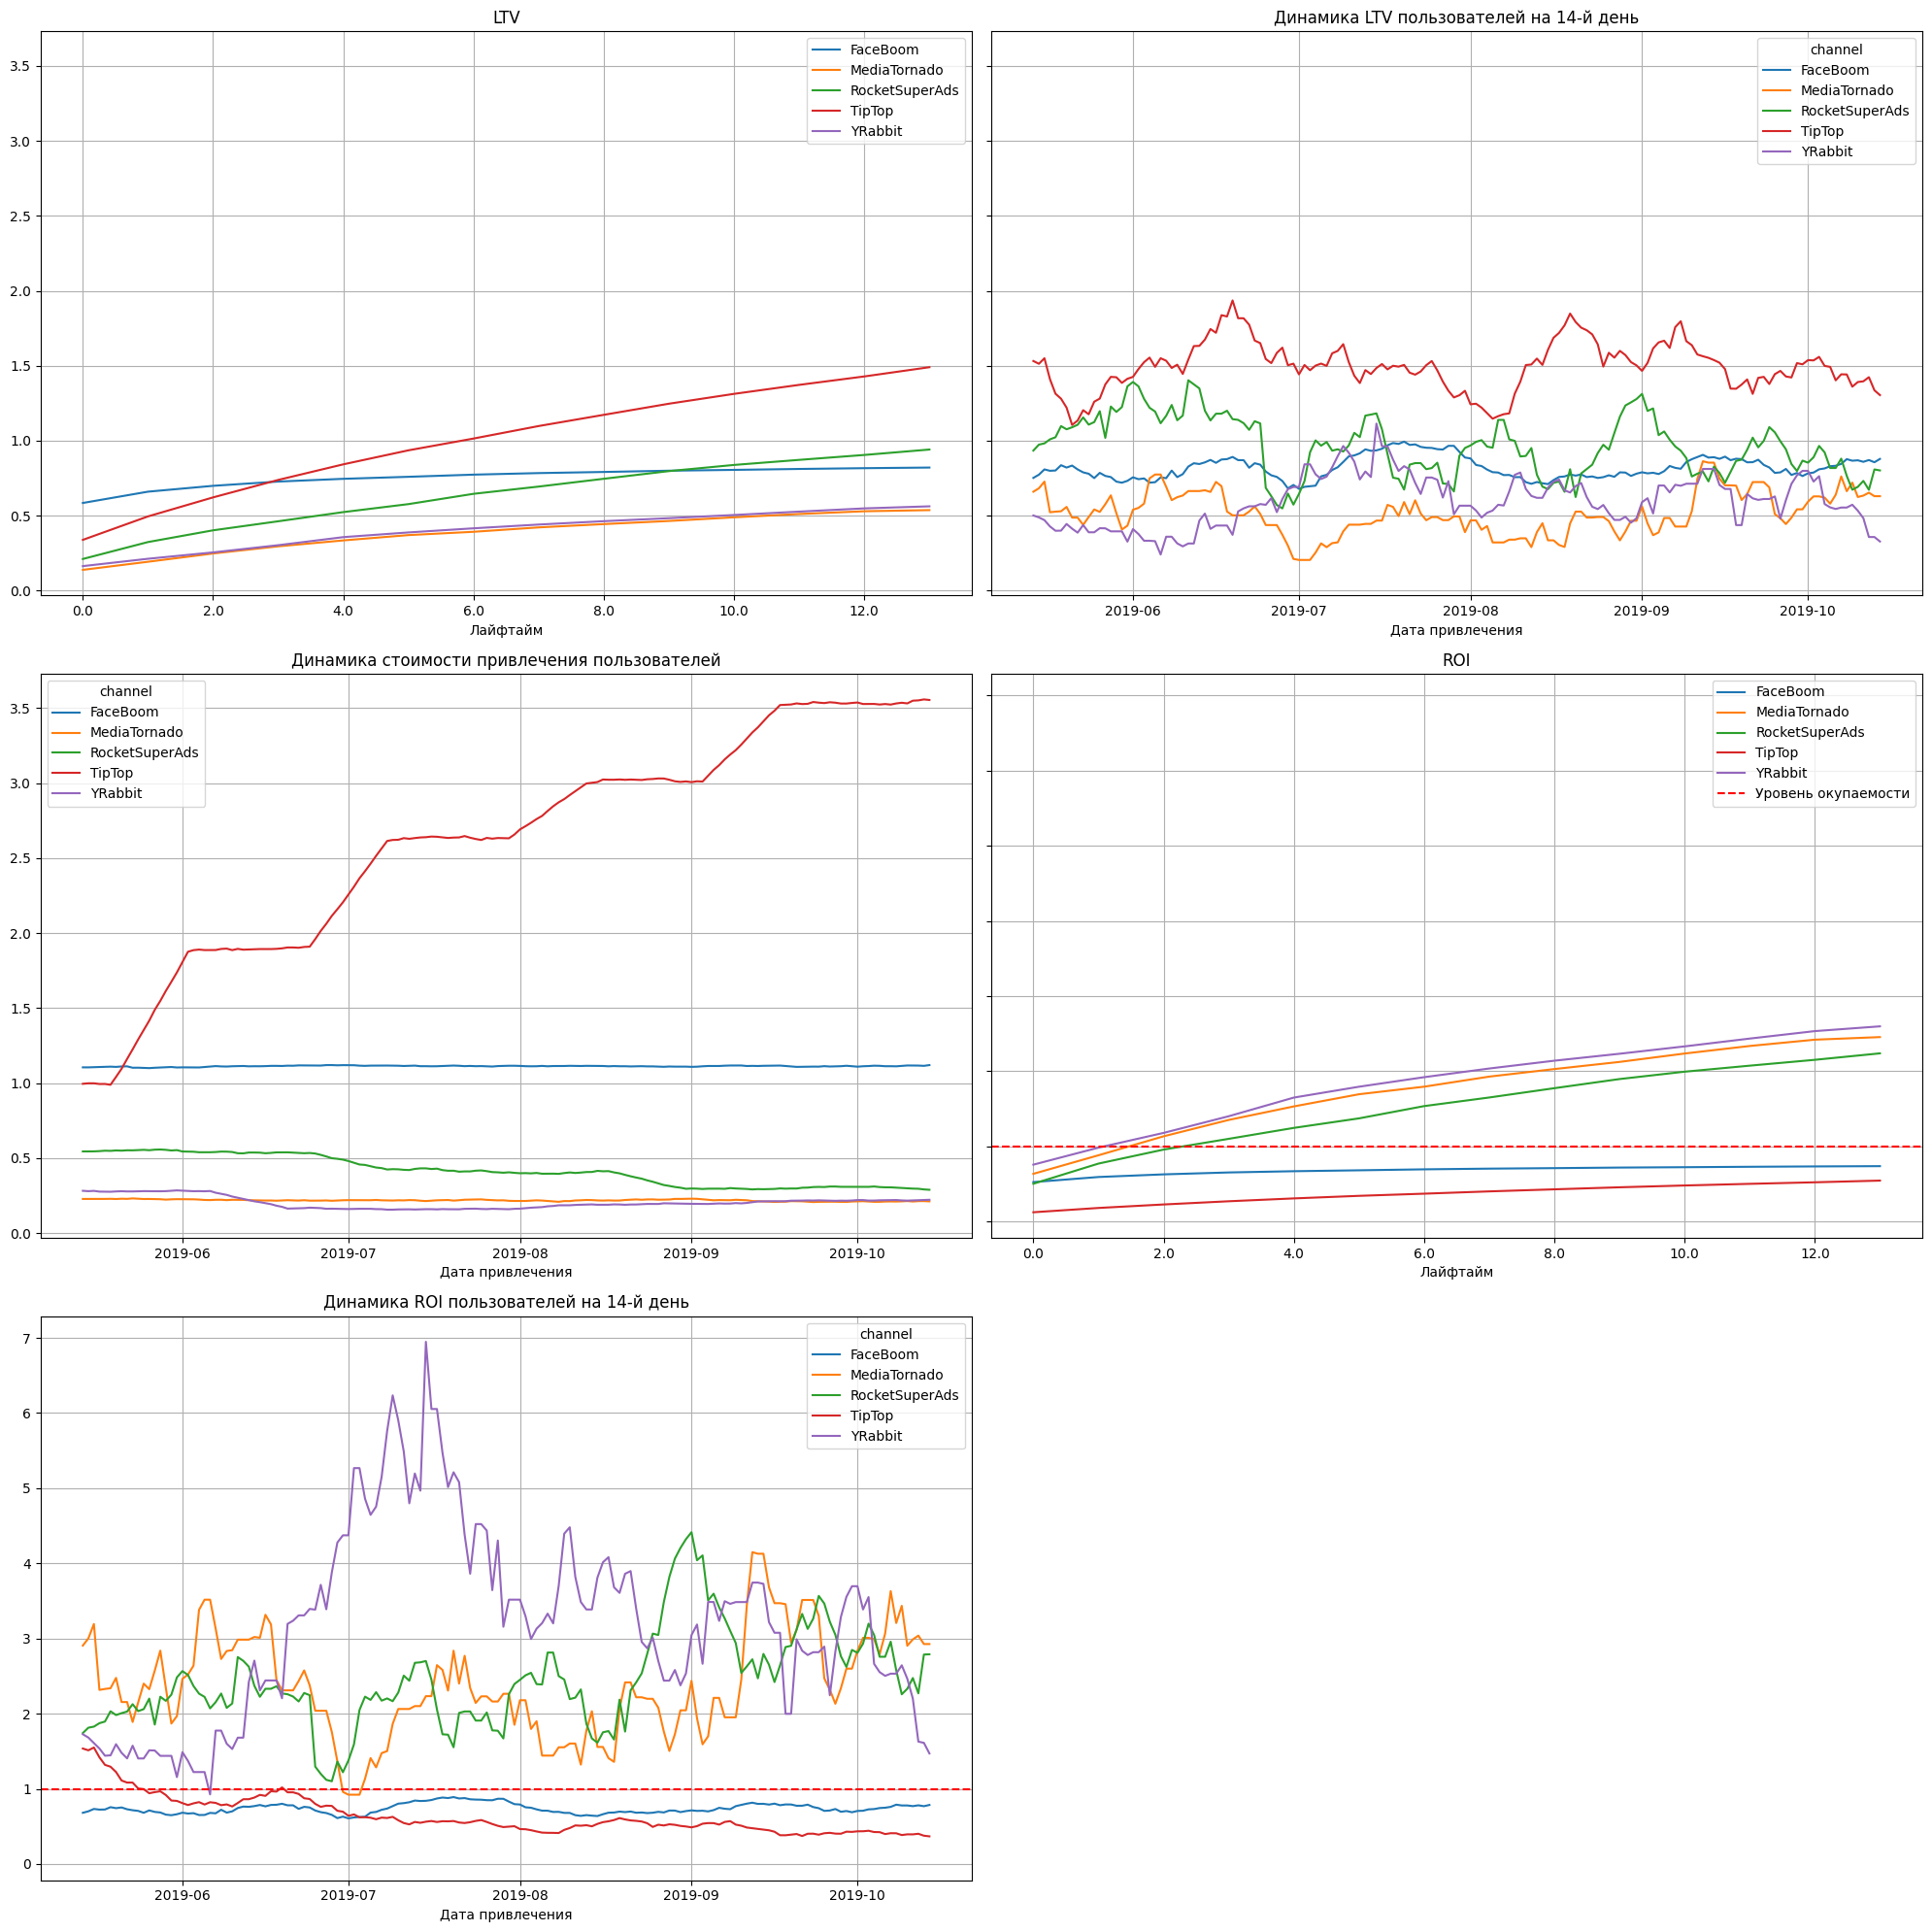

In [65]:
# расчёт окупаемости рекламы на терртории США с разбивкой по рекламным каналам
dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_USA, orders, observation_date, horizon_days, dimensions=dimensions)

plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14) 

В США динамика стоимости привлечения пользователей посредством рекламы на `TipTop` была значительно выше, чем у других каналов, но расходы на рекламу всё равно не окупились.

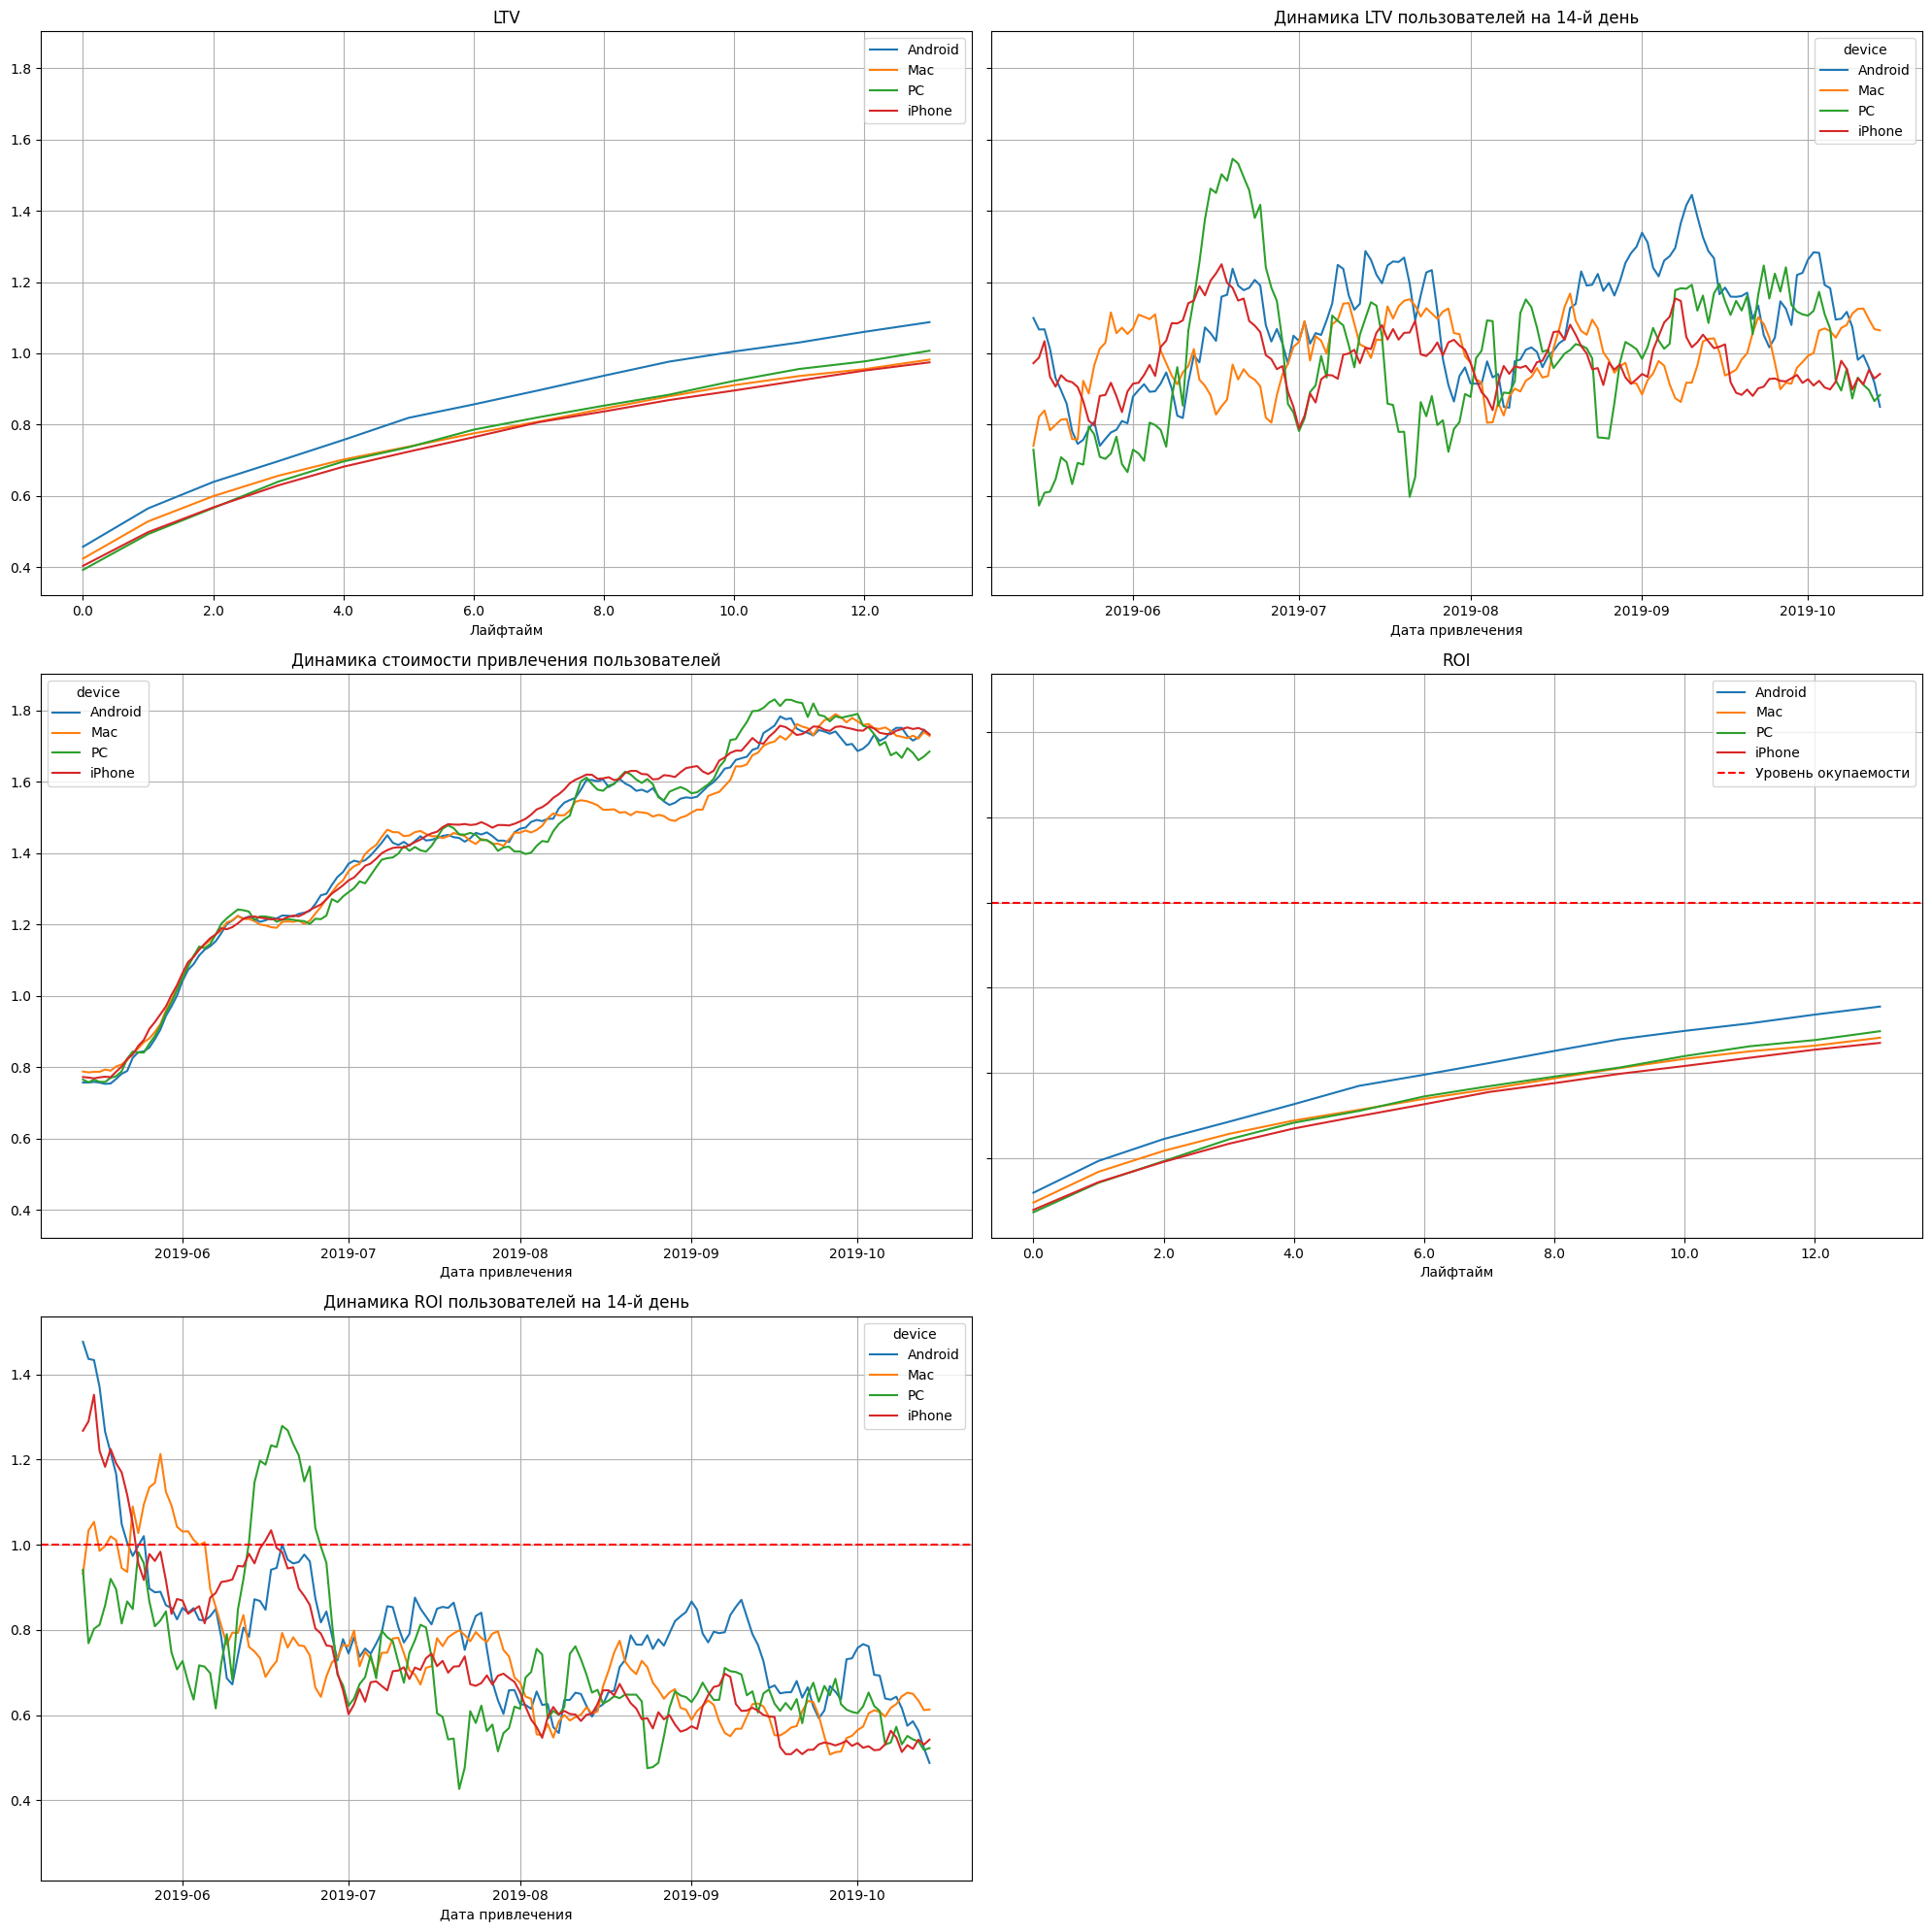

In [66]:
# расчёт окупаемости рекламы на терртории США с разбивкой по устройствам
dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_USA, orders, observation_date, horizon_days, dimensions=dimensions)

plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14) 

В США динамика стоимости привлечения пользователей была практически одинаковой для всех типов устройств, но одно из них не окупилось. Если рассматривать график по США и устройствам пользователей в этой стране, то всплеск активности использования платформы `PC` в июне-июле 2019 года после предполагаемых майских нововведений и обновлений рекламной стратегии **выглядит как сигнал о неполадках в мобильной версии приложения,** а с учётом численности пользователей американского сегмента проблема получает колоссальный масштаб. Но для подтверждения этого довода у нас нет достаточной объективной информации о логах взаимодействия пользователей и приложения.

<a id=5.6.3.></a>
#### 5.6.3. Чем могут быть вызваны проблемы окупаемости?

Для ответа на этот вопрос в текущем исследовании необходимо провести дополнительное исследование оценки поведения пользователей, а также дополнительный датафрейм, содержащий информацию о взаимодействии пользователей с приложением, в том числе данные о технических ошибках.

На основании имеющихся данных и аналитических задач мы можем дать лишь частичный ответ:
* на глобальном уровне - в дисбалансе распределения денежных средств рекламных кампаний в Европе и США. Европейский рынок судя по динамике всех метрик выглядит достаточно знакомым и устойчивым для развития приложения Procrastinate Pro+.
* на техническом уровне - при очень высокой конверсии пользователей устройств Apple и средней конверсии пользователей устройств Android мы видим высокое удержание пользователей устройств Android и очень низкое удержание пользователей устройств Apple. Даже если сделать скидку на "одноразовое" посещение приложения, то обратно пропорциональная зависимость конверсии и удержания по типу устройств Apple может с июня 2019 года может свидетельствовать о наличии технических ошибок, некачественном обновлении приложения или неудобном для пользователей Apple интерфейса. 
* на источниковом уровне имеются проблемы, которые по сути своей являются производными от глобального уровня, а именно: 1) распределение финансирования рекламных кампаний по источникам рекламы на территории США и 2) непредставленность приложения на рекламных каналах, популярных в США и чуть менее популярных в Европе.

В контексте имеющихся данных, приложение Procrastinate Pro+ размещает рекламу на следующих каналах в США: `FaceBoom`, `TipTop`, `RocketSuperAds`, `MediaTornado` и `YRabbit`. Все перечисленные каналы за исключением `TipTop` присутствуют на рынке не первый и даже не пятый год, у них сложившийся имидж, своя аудитория во всём её разнообразии и довольно динамичный отклик на реалии текущего дня. На вышеприведённых графиках мы видели стабильные цены на услуги по размещению рекламы на всех американских каналах, за исключением `TipTop`. Будучи новичками и в хорошем смысле революционерами-новаторами, владельцы этой платформы, предположительно, раз за разом повышали цену на подобные услуги. В таком случае, владельцам приложения приходилось жертвовать денежными средствами в угоду следования трендам, САС привлечения клиента неумолимо росла, а конверсия и ROI снижался. За полгода такой практики последовали серьёзные убытки.

Из великолепной пятёрки американских медиа, два самых крупных присутствуют в Европе и имеют очень серьёзную по численности аудиторию: на начало 2019 года аккаунт в `FaceBoom` в Великобритании есть у 53 млн человек (восемь человек из десяти), в Германии у 41 млн человек и во Франции у 33 млн человек (у каждого второго гражданина обеих стран). `TipTop` в это время покорил сердца порядка 20 млн британцев, 14 млн немцев и 19 млн французов. Порядка 180 миллионов людей потенциальной аудитории... Безусловно, далеко не все из них увидят в своих лентах рекламу приложения Procrastinate Pro+, далеко не все из них совершат покупку в этом приложении. 

Причины такого смещения фокуса с европейских каналов на американские могут быть разными: от недооценки потенциала европейской аудитории до малоэффективного опыта продвижения приложения прошлых лет. Вместо того чтобы развивать уже знакомые и потенциально эффективные каналы (FaceBoom и TipTop) в Европе, компания приняла решение свернуть активность в этом регионе и искать лучшей доли на американском рынке, что в итоге привело к кассовому разрыву.

<a id=5.6.4.></a>
#### 5.6.4. Промежуточные рекомендации для отдела рекламы

Рекомендации 1 этапа:

1.1. пересмотреть порядок взаимодействия с каналом `TipTop` американского рынка в части сокращения финансирования / его полного прекращения / поиска партнёров, которые могут разделить финансовое бремя с владельцами приложения на взаимовыгодных условиях;
1.2. обнаружить, что кроме канала `TipTop` на американском рынке существуют каналы `YRabbit` и `MediaTornado`, в которых достаточно низкая стоимость привлечения клиента и высокая ROI.
1.3. запросить логи взаимодействия пользователей с приложением Procrastinate Pro+ и проверить наличие всех ошибок и дискомфортных для пользователей устройств Apple характеристик. Приложение было создано и ориентировано на пользователей телефонов, и если клиенты с платформой `Android` ведут себя достаточно стабильно, а в июне отмечен резкий всплеск интереса к приложению на платформе `PC`, то с большой долей вероятности наблюдаются технические проблемы.

В случае, если рекомендации 1 этапа сработают успешно, и приложение выйдет в прибыль, то можно перейти к рекомендациям 2 этапа:

2.1. расширение зоны представленности - выход на европейский рынок в части нового для приложения и старого для Европы рекламного канала `FaceBoom`. `TipTop` сознательно не включаем в список рекомендаций, поскольку его ценовая политика переживает период становления и подвержена резким изменениям (не в лучшую для владельцев приложения сторону повышения цены).
2.2. расширение зоны представленности - выход на американский рынок в части рекламных каналов `lambdaMediaAds` (высокий LVT), `LeapBob` (низкий LVT, но высокая ROI) и `OppleCreativeMedia` (высокая ROI).

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=6></a>
## Шаг 6. Вывод

Подводя итоги вышесказанному, выделим причины неэффективности привлечения пользователей и сформулируем рекомендации для отдела маркетинга приложения ProcrastinatePro+.

В работу поступили 3 датафрейма, содержащие следующую информацию о работе приложения ProcrastinatePro+ за период с 1 мая по 27 октября 2019 года включительно: `visits_info_short.csv` лог сервера с информацией о посещениях сайта (309 901 строка х 6 столбцов); `orders_info_short.csv` выгрузка информации о заказах (40 212 строк × 3 столбца); `costs_info_short.csv` информация о расходах на рекламу (1 800 строк × 3 столбца). Выполнена предварительная обработка данных без потерь. Установлены **хронологические рамки** исследования с датами привлечения пользователей в диапазоне с 1.05.2019 по 27.10.2019 года. Также мы выяснили **географию пользователей**: приложение востребовано у пользователей из США, Великобритании, Франции и Германии. Численное превосходство по визитам пользователей, так и платящих пользователей закреплено за США.

*Таблица. Число пользователей в разрезе географии и совершения оплаты*

|Наименование страны|Число пользователей, всего|Число неплатящих пользователей|Число платящих пользователей|Доля платящих пользователей|
|---------------|:----|:----|:---|:----|
|США            |100002|93100|6902|6.9%|
|Великобритания |17575|16875|700|3.98%|
|Франция        |17450|16787|663|3.80%|
|Германия       |14981|14365|616|4.11%|

Из метрик, описывающих поведение клиентов из 4 стран, получаются своеобразные качели, на одной вершине которых находятся США, а блок европейских стран составляет им своего рода противовес. Германия, Франция и Великобритания характеризуются примерно одинаковыми в масштабе числами, и говорить о явном лидере в европейском сегменте не представляется возможным.

Изучив **устройства пользователей** мы установили, что клиенты приложения используют 4 распространённые платформы: `iPhone`, `Android`, `Mac`, `PC`.

*Таблица. Число пользователей в разрезе устройства и совершения оплаты*

|Наименование типа устройства|Число пользователей, всего|Число неплатящих пользователей|Число платящих пользователей| Доля платящих пользователей|
|---------|:----|:----|:---|:----|
|`iPhone` |54479|51097|3382|6.21%|
|`Android`|35032|32982|2050|5.85%|
|`Mac`    |30042|28130|1912|6.36%|
|`PC`     |30455|28918|1537|5.05%|

При этом, самой популярной платформой у платящих пользователей является `iPhone`, второе место с большим отрывом занимает `Android`. Самая непопулярная платформа у платящих и у неплатящих пользователей - `PC`.

Переход в приложение происходит по следующим 10 платным **каналам рекламы**: `AdNonSense`, `FaceBoom`, `lambdaMediaAds`, `LeapBob`, `MediaTornado`, `OppleCreativeMedia`,`RocketSuperAds`, `TipTop`, `WahooNetBanner`, `YRabbit`.

*Таблица. Число пользователей в разрезе источника рекламы и совершения оплаты*

|Наименование источника рекламы|Число пользователей, всего|Число неплатящих пользователей| Число платящих пользователей| Доля платящих пользователей|
|--------------------|:----|:----|:---|:-----|
|`FaceBoom`          |29144|25587|3557|12.2%|
|`TipTop`            |19561|17683|1878|9.60%|
|`WahooNetBanner`    |8553|8100|453|5.30%|
|`AdNonSense`        |3880|3440|440|11.34%|
|`RocketSuperAds`    |4448|4096|352|7.91%|
|`LeapBob`           |8553|8291|262|3.06%|
|`OppleCreativeMedia`|8605|8372|233|2.71%|
|`lambdaMediaAds`    |2149|1924|225|10.47%|
|`YRabbit`           |4312|4147|165|3.83%|
|`MediaTornado`      |4364|4208|156|3.57%|

Два самых больших канала `TipTop` и `FaceBoom`, забирают более 80% рекламного бюджета (51.9% и 30.75% соответственно), при этом `TipTop` притягивает только 9.6% платящих пользователей, что свидетельствует о низкой эффективности затрат на этой площадке. В четвёрку лидеров попали каналы рекламы `AdNonSense` и `lambdaMediaAds`, где доля платящих клиентов очень близка к аналогичному показателю каналов-лидеров и составляет 11.34% и 10.47% соответственно.

Общая сумма расходов на **маркетинг** за период с 1 мая по 27 октября 2019 года включительно составила 105 497 денежных единиц. Компания очень активно финансирует рекламу на 10 площадках. Приоритетными являются вложения в рекламу на `TipTop` и `FaceBoom`: 54751.30 денежных единиц и 32445.60 денежных единиц соответственно. Минимальные вложения в рекламу на площадках `MediaTornado ` и `YRabbit` за весь период составляют 954.48 и 944.22 денежных единиц соответственно.
    
Для визуализации динамики изменения финансирования за весь исследуемый период по каждому источнику рекламы нами были созданы два дополнительных признака в датафрейме `costs`, а именно `costs['week']` и `costs['month']`, хранящие данные по неделям и месяцам. Эти признаки были взяты в качестве индексов для соответствующих сводных таблиц, по которым были построены графики.
За весь период идёт очень активное вливание денежных средств преимущественно в два популярных канала с очень широким охватом аудитории `TipTop` и `FaceBoom`. И если `FaceBoom` финансируется довольно ровно (разбег от 4000 до 6000 денежных единиц), то продвижение рекламы на `TipTop` заставляет с изумлением смотреть на Эверест затрат: пик высотой больше 12500 денежных единиц в сентябре 2019 года, похоже, стал поворотным моментом для завершения деятельности на этом пространстве. В общем и целом, в августе - сентябре 2019 года было принято решение о сокращении финансирования двух основных каналов рекламы, при сохранении объёма финансирования по остальным источникам.

Полученные графики побуждают нас углубиться и рассчитать в разрезе каждого источника рекламы среднюю стоимость привлечения одного пользователя. САС – метрика очень важная для измерения показателя «здоровья» бизнеса. Пользователей канала `organic` мы из исследования исключили, поскольку этот канал привлечения по своей природе не требовал дополнительных расходов и его представители находили приложение самостоятельно. Так, общая средняя стоимость привлечения клиента составляет 1.13 денежных единиц. Выше этого условного порога только САС по каналу `TipTop`.
    
**Расчёты юнит-экономики** в этом исследовании характеризуют, сколько владельцы приложения зарабатывают или теряют на одном юните, в данном случае юнит или базовая единица, генерирующая доход — это клиент. К сожалению, за период с мая по октябрь 2019 года данный бизнес стабильно терял деньги. В рамках исследовательского анализа мы выявили черты социального портрета пользователя приложения Procrastinate Pro+ в разрезе сразу нескольких признаков: географии, типа устройства, источника рекламы.    
    
**САС привлечения клиентов растёт на всём периоде и параллельно с этим увеличивается общий бюджет на рекламу, который не приносит ожидаемой отдачи.** При этом, ROI на всём лайфтайме так и не доходит до окупаемости. Однако, стоит внимательно посмотреть на график динамики ROI и становится очевидным период, когда **начались реальные проблемы:** это середина мая - начало июня 2019 года. В середине мая 2019 года реклама ещё окупалась, робкая попытка выйти в плюс отмечается на этом же графике в **период середины июня 2019 года**, однако, далее динамика стала отрицательной. Проведённые дополнительные построения с учётом органических пользователей только подтверждают вышеприведённые факты: в конце мая – начале июня 2019 года была изменена рекламная стратегия, и смена курса не принесла ожидаемого позитивного результата. Даже с учётом дохода от органических пользователей ROI почти вплотную подходит к уровню окупаемости, но не превышает его. Мы изучили конверсию и удержание пользователей, а также динамику изменения этих метрик. На основе полученных результатов мы сформировали следующую обобщённую таблицу:

*Таблица. Обобщённые данные по конверсии и удержанию*

|наименование признака|конверсия высокая|конверсия низкая|удержание высокое|удержание низкое|
|---------------------|:----------------|:---------------|:----------------|:---------------|
|**страна**           |США, Германия    |Франция         |Германия, Франция|США             |
|**устройство**       |`Mac`, `iPhone`  |`PC`            |`PC`, `Android`  |`Mac`, `iPhone` |
|**источник рекламы** |`FaceBoom`, `AdNonSense`, `lambdaMediaAds` |`OppleCreativeMedia` |`WahooNetBanner`, `RocketSuperAds`, `OppleCreativeMedia`|`FaceBoom`, `AdNonSense`|

Также нами был рассчитан и визуализирован ряд метрик (CAC, LVT, ROI) для анализа окупаемости рекламы в разрезе каждого дополнительного признака, результаты представлены в обобщённой таблице ниже:

*Таблица. Обобщённые данные по окупаемости рекламы*

|наименование признака|CAC высокая|CAC низкая|LVT высокая| LVT низкая|ROI высокая|ROI низкая|
|---------------------|:----------|:---------|:----------|:----------|:----------|:---------|
|**страна**           |США|Великобритания|США|Франция|Великобритания, Германия, Франция|США|
|**устройство**       |`iPhone`, `Mac`|`PC`|`Mac`, `Android`|`PC`|`PC`|`Android`, `Mac`, `iPhone`|
|**источник рекламы** |`TipTop`|`YRabbit`|`lambdaMediaAds`, `TipTop`|`YRabbit`, `OppleCreativeMedia`|`YRabbit`, `MediaTornado`, `lambdaMediaAds`, `LeapBob`, `RocketSuperAds`, `OppleCreativeMedia`, `WahooNetBanner`|`AdNonSense`, `FaceBoom`, `TipTop`|

Полагаем необходимым отметить важный факт: уровень удержания очень низкий, и **абсолютное большинство пользователей приложения открывают его единожды.** У пользователей нет стимула открывать приложение каждый месяц или неделю на протяжении всего календарного года. Оставшееся меньшинство пользователей, вероятно, следят за новинками.

Вообще, чем дальше изучаем положение дел с инвестициями в рекламу приложения Procrastinate Pro+, тем больше складывается ощущение, что рекламная стратегия продвижения приложения была разработана очень детально и с глубоким погружением в материал европейского происхождения, а ментальность американского рынка осталась для разработчиков неразгаданной загадкой. Сама рекламная стратегия с большим трудом переносится с бумаги в жизнь, и на практике ввиду разных факторов (нет своих или нанятых квалифицированных специалистов, нет ресурса времени на отслеживание метрик) мы наблюдаем погоню за растиражированными и популярными каналами рекламы, а в случае неудачи – экстренное хаотичное латание провисов в показателях. Такие действия привели к тому, что в общем и целом реклама не окупается ни на одном из рынков. Негативное влияние на итоговый результат инвестиций в рекламу приложения Procrastinate Pro+, оказывает ситуация с низкой окупаемостью рекламы в США, как в основной стране присутствия. На основании полученных данных о региональной представленности источников рекламы, негативное влияние оказывают рекламные каналы, также действующие на территории США: `FaceBoom`, и `TipTop`, на которые приходится более 80% консолидированного рекламного бюджета.
    
Проблемы окупаемости рекламы заключаются, на наш взгляд, в:
1) `дисбалансе распределения денежных средств рекламных кампаний в Европе и США`. Европейский рынок судя по динамике всех метрик выглядит достаточно знакомым и устойчивым для развития приложения Procrastinate Pro+;
2) `высокая вероятность наличия технических ошибок` при взаимодействии пользователей устройств Apple  с приложением;
3) `непредставленность приложения на рекламных каналах, в равной мере популярных и в США, и в Европе`;
4) `на американском региональном рынке - следование тренду присутствия на растущем рекламном канале `TipTop` в период его становления вопреки здравому смыслу и многократно повышающейся тарифной ставке на размещение рекламы. 

Затраты на привлечение пользователей и рекламу гораздо выше уровня возврата денежных средств, которые тратят пользователи. Масштабировать такой бизнес через определённые каналы роста не только не имеет смысла, но и попросту опасно. Рано или поздно денежные средства закончатся, и финансирование приложения придётся прекратить. В целях предотвращения негативного сценария развития приложения Procrastinate Pro+ мы сформулировали следующие промежуточные рекомендации для отдела рекламы данного приложения:
    
Рекомендации 1 этапа:
    
1.1. `пересмотреть порядок взаимодействия` с каналом `TipTop` американского рынка в части сокращения финансирования / его полного прекращения / поиска партнёров, которые могут разделить финансовое бремя с владельцами приложения на взаимовыгодных условиях;
    
1.2. `сместить акцент` с канала американского регионального сегмента `TipTop` на каналы `YRabbit` и `MediaTornado`, в которых достаточно низкая стоимость привлечения клиента CAC и высокая ROI (при условии проведения теста на их пропускную способность, так как текущие объемы трафика этих каналов не смогут полностью заместить TipTop);
    
1.3. `запросить логи взаимодействия пользователей с приложением` Procrastinate Pro+ и проверить наличие всех ошибок и дискомфортных для пользователей устройств Apple характеристик. Приложение было создано и ориентировано на пользователей телефонов, и если клиенты с платформой `Android` ведут себя достаточно стабильно, а в июне отмечен резкий всплеск интереса к приложению на платформе `PC`, то с большой долей вероятности наблюдаются технические проблемы.

Рекомендации 2 этапа имеют смысл в случае успешной реализации рекомендаций 1 этапа:

2.1. `расширение зоны представленности`: выход на европейский рынок в части нового для приложения и старого для Европы рекламного канала `FaceBoom`. `TipTop` сознательно не включаем в список рекомендаций, поскольку его ценовая политика переживает период становления и подвержена резким изменениям (не в лучшую для владельцев приложения сторону повышения цены);

2.2. `расширение зоны представленности`: выход на американский рынок в части рекламных каналов `lambdaMediaAds` (высокий LVT), `LeapBob` (низкий LVT, но высокая ROI) и `OppleCreativeMedia` (высокая ROI).

На основании вышеизложенного полагаем, что нам удалось установить возможные причины убыточности приложения Procrastinate Pro+ в период с мая по октябрь 2019 года включительно, а также сформировать промежуточные рекомендации для отдела рекламы в целях увеличения прибыльности данного приложения. Полагаем, что цель данного исследования достигнута и аналитическая работа выполнена.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 